# Hydrogen ChemKAN Failure Analysis
## Thermodynamic Superstructure and Initialization Diagnostics

> # ⚠️ DIAGNOSTIC / REPRODUCTION ANALYSIS — **NOT A NEW PAPER REPRODUCTION RESULT**

This notebook organizes and **reproducibly recomputes** the hydrogen failure investigation.
It is an *analysis* notebook, not a training notebook.

* All training has **already been performed** elsewhere and is **not repeated here**.
* The notebook works from **saved checkpoints, configs, probe CSVs and result tables**.
* Evaluations, metrics and plots are **recomputed from those artifacts**, so the numbers
  below are produced by code, not transcribed.
* Running all cells is safe: it loads checkpoints read-only, integrates trajectories,
  inspects weights and renders figures. **No cell launches training and no cell writes a
  `.pt` checkpoint.**

### Evidence categories used throughout

| tag | meaning |
|---|---|
| **PAPER-EXPLICIT** | stated in the ChemKAN paper, with a locatable equation/section reference |
| **INFERRED REPRODUCTION CHOICE** | not stated in the paper; chosen here to make the paper's own description self-consistent |
| **CURRENT IMPLEMENTATION CHOICE** | a decision made by this repository that the paper does not constrain |
| **DIAGNOSTIC / ABLATION** | an experiment run to understand the failure; never a reproduction result |

These four are kept distinct everywhere. In particular, **Cantera-based initialization of
`thermo.linear` is a DIAGNOSTIC intervention invented here — it is not paper methodology.**

## Executive summary

**The hydrogen reproduction is NOT complete.** Stage 2 fails to reproduce ignition under
the default configuration. This notebook characterizes that failure; it does **not**
identify a single sufficient cause, and no claim here should be read as one.

| what the artifacts establish | § | key measured value |
|---|---|---|
| The default Stage-2 run never ignites, and 10 000 epochs do not rescue it *(N=5/base-OFF)* | 4, 13B | temperature stays within ~10 K of `T₀`; test trajectory MSE **3.16** |
| A severe thermodynamic `dT/dt` deficit, independent of the kinetic core *(N=5/base-OFF)* | 6B/6C | driving the **learned** `θ_thermo` with **reference** species rates still under-predicts peak `dT/dt` by **~134× / ~145×** |
| The deficit is in the Eq. 14 **Linear** branch, not `KAN_cor` | 6 | `KAN_cor` contributes **~0.1 %** of the Eq. 15 path at the heat-release peak |
| Fixed-temperature testing shows **weak low-temperature kinetic gating already after Stage 1** *(N=5/base-OFF)* | 6D | at 950 K, isothermal Cantera is inert (`max\|ΔY\| = 8.2e-08`) while the Stage-1 core gives 5.1e-03 (**×62 000**) and the Stage-2 core 1.2e-02 (**×142 000**) |
| Thermodynamic `Linear` initialization is highly sensitive in **both** scale and direction *(N=5/base-OFF)* | 9, 12, 15, 21 | three **equal-norm** random directions end **~26×** apart in test MSE after 10 000 epochs |
| The **N=4/base-ON** interpretation does **not** remove the failure *(matched 344 params, both readings)* | 22 | default-random test MSE **3.16** (base-OFF, N=5) vs **3.15** (base-ON, N=4) |
| **FSA remains unimplemented** — the clearest paper-explicit training-method difference | 24 | no evidence here speaks to it either way |

**Deliberately not claimed.** No single one of the above is established as *the* cause.
The paper leaves the grid size `N`, the `θ_thermo` initialization, and any derivative
scaling inside Eq. 14 unstated, so several candidate explanations remain open at once.
§23 separates ESTABLISHED from SUPPORTED from NOT ESTABLISHED; read it before quoting
anything from this notebook.

**Two figures are the ones used for supervisor communication** and must be preserved:
the **§6B/6C** `dT/dt` + temperature-trajectory diagnostic, and the **§16** 10 000-epoch
thermodynamic-initialization comparison.

### Contents

Sections are grouped below into the ten evidence categories this investigation is
organized around. The § numbering is chronological (the order the work was done) and is
kept unchanged so earlier write-ups stay valid; the categories are the way to *read* it.

| # | category | sections |
|---|---|---|
| 1 | baseline closed-loop failure | §4, §5, §13, §13B |
| 2 | open-loop `dT/dt` diagnostics | **§6, §6B, §6C**, §7 |
| 3 | fixed-temperature kinetic diagnostic | **§6D** |
| 4 | coefficient-only interventions | §8, §10, §11 |
| 5 | initialization scale / direction ablations | §9, §12, §18E, §18F |
| 6 | 500-epoch exploratory runs | §12, §14, §21 (secondary table) |
| 7 | 10 000-epoch persistence runs | §15, **§16**, §17, §19, §20, §21 |
| 8 | base-activation architecture ablation | **§22** |
| 9 | solver-effort / NFE diagnostics | §18 (runtime, `median_nfe`, `wall_hours`) |
| 10 | remaining methodological gap: FSA | §24 |

| § | question |
|---|---|
| 1 | What hydrogen result were we trying to reproduce? |
| 2 | Which artifacts exist, and what is their provenance? |
| 3 | Which commands produced them? |
| 4 | What did the default reproduction actually produce? |
| 5 | Was Stage 1 completely broken? |
| 6 | Where was the Stage-2 failure localized? (linear branch vs full Eq. 15 path) |
| **6D** | **Fixed-temperature kinetic diagnostic: Stage-1 vs Stage-2 vs isothermal Cantera** |
| 7 | What numerical scale does Eq. 14 require in our implementation? |
| 8 | What did the physical coefficient intervention show? |
| 9 | Random vs Cantera thermo init from the *same* Stage-1 checkpoint (10k) |
| 10 | Eq. 14 representation / normalization audit |
| 11 | Why was the Cantera-init provenance initially inconsistent? |
| 12 | Is large coefficient magnitude alone sufficient? (scale vs direction, **500 epochs**) |
| 13 | Operational ignition-flag histories |
| 14 | 500-epoch temperature trajectories |
| **15** | **Long-budget persistence study: 500 → 10 000 epochs** |
| **16** | **Ground truth vs model temperature at 10 000 epochs** |
| **17** | **Did long training repair the trajectory shape?** |
| **18** | **How much does `θ_thermo` actually move? (norm, coefficients, direction, blocks, runtime/NFE)** |
| **18E** | **Why `dir0` fails: rate-weighted alignment with the physical direction** |
| **18F** | **What gradient actually reaches `θ_thermo`? (one backward pass)** |
| 13B | Operational ignition-flag history over the full 10k budget |
| 19 | Ignition-metric audit and grid consistency (genuine dense Cantera reference) |
| 20 | Full train/test trajectory MSE |
| 21 | Master comparison table at 10 000 epochs |
| **22** | **Base-activation architecture sensitivity: N=5/base-OFF vs N=4/base-ON** |
| 23 | Established / Supported / Not established |
| 24 | Next-step decision |

**Bold** sections are the long-budget study added after the 10 000-epoch runs completed.

### Provenance conventions for every figure and table below

Each major result states, at the point it is produced:

* **checkpoint / run** — the `run_dir` it was loaded from (§2 registry);
* **open-loop vs closed-loop** — whether temperature was supplied externally
  (open-loop, evaluated on reference states) or integrated by the model (closed-loop);
* **reference vs predicted species rates** — which `dY/dt` drove the thermodynamic path;
* **retraining** — whether any weights were changed. **No cell in this notebook trains a
  model or writes a `.pt`**; interventions such as §8 modify a loaded model in memory only.

### Architecture labelling — explicit, not by default

Both readings match the paper's 344 parameters, so **every** result below is labelled with
the architecture that produced it. There is no "unless otherwise stated" convention.
Architecture is read from each checkpoint's own `config.json`, never assumed.

| label | `num_basis` | Eq. 11 base path | which results | run directories |
|---|---|---|---|---|
| **N=5 / base-OFF** — historical | 5 | OFF | §1–§21: the whole initialization investigation, all 500- and 10 000-epoch thermo-init arms, and the main run | `hydrogen/diagnostics/thermo_init_*`, `hydrogen/diagnostics/stage1_seed0`, `hydrogen/main/base_off_direct_autograd_seed0` |
| **N=4 / base-ON** — current default | 4 | ON | §22 only: the matched base-activation ablation | `hydrogen/diagnostics/base_on_n4/*` |

The `base_on_n4/` parent directory and the `base_off_` prefix on the main run already carry
the label on disk. The thirteen `thermo_init_*` diagnostic directories are **not** renamed:
they are referenced ~194 times across notebooks, stored `run_id` metadata, figure provenance
strings and CSV path columns, so renaming would break stored artifacts for no scientific
gain. They are **N=5/base-OFF** and are labelled as such in every heading, caption and table
that uses them.

`num_basis = 4` with the base path ON became the hydrogen **script default** on 2026-09-03.
Every checkpoint in this notebook predates that change or explicitly overrides it, and **no
stored result was re-run, relabelled or renumbered** because of it.

### Solver effort (NFE)

Exact **per-epoch** NFE is kept in each run's `history_stage2.csv` (`nfe` column) and is not
summarized away. Each run is reported by **median NFE/epoch** and **total NFE**. These
counters exist for the **six** N=4/base-ON 10 000-epoch Stage-2 arms, which were run after
`--count-nfe` was added; the N=5/base-OFF arms predate it and have `wall_hours` and
`median_s_per_epoch` only.

In [1]:
%matplotlib inline
# --- Environment and paths (repo-relative; no machine-specific absolute paths) ---
import sys, json, csv, time, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

NB_T0 = time.perf_counter()

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "chemkan" / "src").is_dir(), "could not locate the repository root"

for p in (ROOT / "chemkan/src", ROOT / "chemkan/scripts", ROOT / "chemkan/scripts/diagnostics"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# repository utilities -- reused, never re-implemented here
from chemkan.normalization import MinMaxNormalizer
from chemkan.dynamics import ChemKANDynamics, KineticDynamics
from chemkan.temperature import ObservedTemperature
from chemkan.solver import integrate
from _data import load_input_scaling
from evaluate_hydrogen import (build_chemkan, solver_from_ckpt, integrate_hydrogen,
                               evaluate_hydrogen)
from _thermo_coeffs import MECH, cantera_coefficients, resolve_training_ic
from hydrogen_thermo_intervention import ignition_delay      # THE repo ignition definition

H2       = ROOT / "results/reproduction/chemkan/hydrogen"
DIAG     = H2 / "diagnostics"
FIGURES  = H2 / "figures"
TABLES   = H2 / "tables"
OLD_TAB  = ROOT / "results/reproduction/tables"
OLD_FIG  = ROOT / "results/reproduction/figures/hydrogen"

def rel(p):
    """Display any path relative to the repository root."""
    return str(Path(p).resolve().relative_to(ROOT))

pd.set_option("display.width", 200, "display.max_columns", 60, "display.precision", 4)
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linewidth": 0.6, "font.size": 9})
print("repo root :", ROOT.name)
print("torch     :", torch.__version__)

repo root : chemkan-tuwien
torch     : 2.13.0


In [2]:
# --- Canonical dataset + small notebook helpers (defined once, reused everywhere) ---
npz = np.load(ROOT / "chemkan/data/generated/hydrogen.npz", allow_pickle=True)
t, ics, states = npz["t"], npz["ics"], npz["states"]
species = [str(s) for s in npz["species"]]
u_min, u_max = npz["u_min"], npz["u_max"]
m = len(species)
full_norm = MinMaxNormalizer(torch.as_tensor(u_min), torch.as_tensor(u_max))

# The two representative conditions the paper plots in Fig. 7.
CONDS = [(1050.0, 0.9, "training"), (1150.0, 1.3, "held-out")]
T_DENSE = np.linspace(float(t[0]), float(t[-1]), 601)     # plotting / grid-audit only

def cond_index(T0, phi):
    """Exact dataset index of an initial condition (no nearest-neighbour fallback)."""
    hit = np.where((np.abs(ics[:, 0] - T0) < 1e-9) & (np.abs(ics[:, 1] - phi) < 1e-9))[0]
    assert len(hit) == 1, f"({T0}, {phi}) is not a dataset initial condition"
    return int(hit[0])

def reference(T0, phi):
    """Stored Cantera reference trajectory (Nt, m+1) for one condition."""
    return states[cond_index(T0, phi)]

def load_arm(run_dir):
    """Rebuild a trained ChemKAN from a run directory. READ-ONLY."""
    ckpt = torch.load(Path(run_dir) / "checkpoint_final.pt", map_location="cpu",
                      weights_only=False)
    model = build_chemkan(ckpt, m, "cpu")
    return dict(ckpt=ckpt, model=model, solver=solver_from_ckpt(ckpt),
                input_norm=load_input_scaling(ckpt, "cpu"),
                w=model.thermo.linear.weight.detach().cpu().numpy().ravel().copy(),
                config=json.loads((Path(run_dir) / "config.json").read_text()),
                run_dir=Path(run_dir))

def integrate_arm(arm, T0, phi, tt=None):
    """Closed-loop integration from the initial condition alone -> (Nt, m+1) physical."""
    tt = t if tt is None else tt
    u0 = torch.as_tensor(reference(T0, phi)[0], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        return integrate_hydrogen(arm["model"], arm["input_norm"], arm["solver"], u0,
                                  torch.as_tensor(tt, dtype=torch.float32))[:, 0].numpy()

def normstate(arr):
    """Train-only full-state min-max normalization (Eq. 18 coordinates)."""
    return full_norm.normalize(torch.as_tensor(np.asarray(arr), dtype=torch.float32)).numpy()

def probe_history(run_dir):
    """Read a stage2_probe.csv into a DataFrame (empty strings -> NaN)."""
    p = Path(run_dir) / "stage2_probe.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    df["ignites"] = df["ignites"].astype(str).str.strip().str.lower().eq("true")
    return df

def sha256(path, n=12):
    h = hashlib.sha256(Path(path).read_bytes()).hexdigest()
    return h[:n]

# --- GENUINE dense Cantera reference (NOT an interpolation of the 50-point data) ---
# hydrogen_temperature_20000.npz is produced by the same Cantera solve as hydrogen.npz,
# at 20000 points over the same 0.6 ms window. It is the canonical dense reference and is
# the ONLY thing used for dense-grid ignition-delay comparisons in this notebook.
_dense = np.load(ROOT / "chemkan/data/generated/hydrogen_temperature_20000.npz",
                 allow_pickle=True)
T_DENSE = np.asarray(_dense["t"], dtype=float)          # (20000,) genuine Cantera time grid

def reference_T_dense(T0, phi):
    """Genuine 20000-point Cantera T(t) for one condition. No interpolation anywhere."""
    for key_ics, key_T in (("train_ics", "train_T"), ("test_ics", "test_T")):
        ic = np.asarray(_dense[key_ics])
        hit = np.where((np.abs(ic[:, 0] - T0) < 1e-9) & (np.abs(ic[:, 1] - phi) < 1e-9))[0]
        if len(hit) == 1:
            return np.asarray(_dense[key_T])[:, int(hit[0]), 0].astype(float)
    raise AssertionError(f"({T0}, {phi}) not present in the dense Cantera cache")

# sanity: the dense cache must agree with the 50-point dataset at the shared instants
for _T0, _phi, _ in CONDS:
    _j = np.searchsorted(T_DENSE, t)
    _err = np.abs(reference_T_dense(_T0, _phi)[np.clip(_j, 0, len(T_DENSE) - 1)]
                  - reference(_T0, _phi)[:, -1]).max()
    assert _err < 1.0, f"dense cache disagrees with hydrogen.npz at ({_T0}, {_phi}): {_err} K"

print(f"dataset: {states.shape[0]} conditions x {len(t)} points x {m+1} states"
      f"  |  t in [0, {t[-1]*1e3:.1f}] ms  |  species order: {species}")
print(f"genuine dense Cantera reference: {len(T_DENSE)} points, "
      f"spacing {np.diff(T_DENSE).mean()*1e9:.1f} ns "
      f"(source: hydrogen_temperature_20000.npz)")

# The historical diagnostic norm-match reference (section 11 explains why it is phi=0.5).
REF_T_EXPECTED, REF_PHI_EXPECTED = 1050.0, 0.5

def fig_source(fig, *keys, note=""):
    """Stamp a figure with the run directory/directories its data came from.

    Every figure in this notebook carries this footnote so a reader can always tell WHICH
    trained model produced the curves, without tracing back through the cells.
    """
    names = []
    for k in keys:
        names.append(A[k]["run_dir"].name if k in A else str(k))
    txt = "source run" + ("s" if len(names) > 1 else "") + ": " + " | ".join(names)
    if note:
        txt += "   —   " + note
    fig.text(0.005, -0.02, txt, ha="left", va="top", fontsize=7.5, color="#555555",
             style="italic")

dataset: 36 conditions x 50 points x 10 states  |  t in [0, 0.6] ms  |  species order: ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'N2']
genuine dense Cantera reference: 20000 points, spacing 30.0 ns (source: hydrogen_temperature_20000.npz)


---
# 1. Paper target and reproduction context

Source: `docs/paper/ChemKANs_for_Combustion_Chemistry_Modeling_and_Acceleration.pdf`
(Sec. II C 2 "Novel chemistry KAN architecture", Sec. II C 4 "Loss function",
Sec. II C 5 "Training Process", Sec. II D 2 / III B for the H₂ case).

### What the paper states (PAPER-EXPLICIT)

**State and architecture.** The full state is `u = [ũ, T]` — nine H₂ species plus
temperature. The kinetic core and the thermodynamic superstructure are separated
(Eqs. 13–15):

$$\frac{d\tilde u}{dt} = \mathrm{KAN}_{kin}(\textbf{u},\theta_{kin}) \qquad (13)$$
$$\frac{dT}{dt} = \mathrm{Linear}\!\left(\frac{d\tilde{\textbf{u}}}{dt},\theta_{thermo}\right) + \epsilon \qquad (14)$$
$$\qquad\;\; = \mathrm{Linear}\big(\mathrm{KAN}_{kin}(u,\theta_{kin}),\theta_{thermo}\big) + \mathrm{KAN}_{cor}(u,\theta_{cor}) \qquad (15)$$

The paper motivates Eq. 14 directly from the energy equation: "the temperature rate
`dT/dt` is a simple linear combination of the species production rates, with scaling
factors defined by the enthalpy `h` and specific heat values `cp` (or alternatively, in
Eq. 14 by the `m` scalars in the linear mapping parameterized by θ_thermo)". The `ε`
term absorbs the failure of a first-order linear map to capture `cp` variation, and is
realized as the single-layer KAN correction `KAN_cor` of Eq. 17.

**Two-stage training.**
*Stage 1 — core kinetics θ_kin*: all `m+1` inputs, only the `m` species rates learned;
"the thermodynamic superstructure of Eqs. 14 and 15 is not used in this stage, and the
input temperatures are simply read in from the training data".
*Stage 2 — thermodynamic superstructure θ_thermo and θ_cor*: "**the entire network**
(Eq. 13 stacked with Eq. 15) is updated in order to infer the temperature together with
all species."

**Sensitivity method.** "we implement **forward sensitivity analysis** to mitigate this
potential stiffness issue"; the ODE integrator is **Tsit5**; the optimizer is **Adam**
with learning rate **2 × 10⁻³**.

**Loss (Eq. 18).** MSE over `n*` states — `n* = m` in Stage 1, `n* = m+1` in Stage 2 —
where "û_k denotes the k-th thermochemical state **normalized to the [0,1] window by
subtracting the minimum then dividing by the range**", plus an optional element
conservation PINN term with α_PINN = 10⁻⁴. The H₂ case uses MSE **plus** the PINN term.

**Representative conditions (Fig. 7).** training `Φ = 0.9, T₀ = 1050 K`; unseen testing
`Φ = 1.3, T₀ = 1150 K`.

**Ignition definition (Fig. 8B).** "Ignition here is defined as **the point of maximum
temperature rise rate**." The time window is **0.6 ms**, and "the lowest temperature
cases did not see ignition given the time span of 0.6 ms" (30 of the 36 cases ignited).

**Parameter count / speed-up (Table I).** 344 parameters, 1 network, 2.0× speed-up.

### The hydrogen initial-condition grid (INFERRED REPRODUCTION CHOICE)

The paper states data are generated "at all **36 combinations** of initial temperatures
`T₀ ∈ {950, 1000, 1050, 1100, 1150, 1200} K` and equivalence ratios
`Φ ∈ {0.7, 0.9, 1.1, 1.3, 1.5}`, with the `[1150 K, 1.3]` case withheld … (thus **35
training datasets**)".

The printed Φ list has **five** entries, so 6 × 5 = **30**, not 36. The two statements
are internally inconsistent: 36 combinations over six fixed temperatures requires **six**
equivalence ratios. This repository reconciles them by adding `Φ = 0.5`:

> `Φ ∈ {0.5, 0.7, 0.9, 1.1, 1.3, 1.5}` → 6 × 6 = 36, minus the withheld case = 35 training.

**`Φ = 0.5` is an INFERRED REPRODUCTION CHOICE, not paper-explicit.** It is used
throughout this repository and it matters later (§11), because the historical
Cantera-initialization bug silently selected the `Φ = 0.5` composition.

In [3]:
# Paper vs current repository -- category is the important column.
comparison = pd.DataFrame([
 ["architecture", "Eqs. 13-15: KAN_kin + Linear(dY/dt) + KAN_cor; hidden 3, n_mu 3, 344 params; "
                  "Eq. 11 edges = N RBF + 1 base coefficient; grid size N NOT stated",
  "structure identical; 344 matched by TWO inferred readings: N=5/base-OFF (sections 1-21) "
  "and N=4/base-ON (section 22)",
  "PAPER-EXPLICIT structure; N and base-term treatment INFERRED"],
 ["optimizer / lr", "Adam, lr = 2e-3", "Adam, lr = 2e-3", "PAPER-EXPLICIT (matched)"],
 ["ODE integrator", "Tsit5", "Tsit5 (torchdiffeq)", "PAPER-EXPLICIT (matched)"],
 ["sensitivity method", "forward sensitivity analysis (FSA)", "direct autograd through the solve",
  "clearest remaining PAPER-EXPLICIT TRAINING-METHOD difference (not necessarily the only implementation difference)"],
 ["loss normalization", "Eq. 18: each state min-max scaled to [0,1]",
  "identical (train-only min-max, chemkan.losses.trajectory_mse)", "PAPER-EXPLICIT (matched)"],
 ["PINN term", "element conservation, alpha = 1e-4, used for H2",
  "identical", "PAPER-EXPLICIT (matched)"],
 ["external input min-max", "not described",
  "full state min-max scaled BEFORE the KAN (guards the internal tanh)",
  "CURRENT IMPLEMENTATION CHOICE"],
 ["thermo.linear initialization", "not described",
  "PyTorch nn.Linear default (uniform +-1/sqrt(m)); Cantera/scaled variants are diagnostics",
  "CURRENT IMPLEMENTATION CHOICE / DIAGNOSTIC"],
 ["derivative scaling in Eq. 14", "not described; Eq. 14 written in physical variables",
  "physical dY/dt -> physical dT/dt (verified in code, see section 10)",
  "CURRENT IMPLEMENTATION CHOICE"],
 ["H2 IC grid", "36 combinations; printed phi list has only 5 entries",
  "phi in {0.5,0.7,0.9,1.1,1.3,1.5} x T0 in {950..1200}; [1150,1.3] withheld",
  "INFERRED REPRODUCTION CHOICE (phi=0.5)"],
 ["ignition definition", "point of maximum temperature rise rate",
  "argmax dT/dt, reported only if the rise exceeds 100 K",
  "PAPER-EXPLICIT + operational guard (see section 15)"],
], columns=["item", "paper", "current repo", "status"])
display(comparison)

# The paper-explicit settings are read back from a real run config, not asserted.
_cfg = json.loads(((H2 / "main/base_off_direct_autograd_seed0") / "config.json").read_text())
print("verified from", rel(H2 / "main/base_off_direct_autograd_seed0/config.json"), ":")
for k in ("optimizer", "learning_rate", "sensitivity_backend", "parameter_count", "epochs",
          "pinn", "normalization"):
    print(f"   {k:20s} {_cfg.get(k)}")
print(f"   {'solver':20s} {_cfg.get('solver')}")

,item,paper,current repo,status
0,architecture,Eqs. 13-15: KAN_kin + Linear(dY/dt) + KAN_cor;...,structure identical; 344 matched by TWO inferr...,PAPER-EXPLICIT structure; N and base-term trea...
1,optimizer / lr,"Adam, lr = 2e-3","Adam, lr = 2e-3",PAPER-EXPLICIT (matched)
2,ODE integrator,Tsit5,Tsit5 (torchdiffeq),PAPER-EXPLICIT (matched)
3,sensitivity method,forward sensitivity analysis (FSA),direct autograd through the solve,clearest remaining PAPER-EXPLICIT TRAINING-MET...
4,loss normalization,"Eq. 18: each state min-max scaled to [0,1]","identical (train-only min-max, chemkan.losses....",PAPER-EXPLICIT (matched)
5,PINN term,"element conservation, alpha = 1e-4, used for H2",identical,PAPER-EXPLICIT (matched)
6,external input min-max,not described,full state min-max scaled BEFORE the KAN (guar...,CURRENT IMPLEMENTATION CHOICE
7,thermo.linear initialization,not described,PyTorch nn.Linear default (uniform +-1/sqrt(m)...,CURRENT IMPLEMENTATION CHOICE / DIAGNOSTIC
8,derivative scaling in Eq. 14,not described; Eq. 14 written in physical vari...,physical dY/dt -> physical dT/dt (verified in ...,CURRENT IMPLEMENTATION CHOICE
9,H2 IC grid,36 combinations; printed phi list has only 5 e...,"phi in {0.5,0.7,0.9,1.1,1.3,1.5} x T0 in {950....",INFERRED REPRODUCTION CHOICE (phi=0.5)


verified from results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0/config.json :
   optimizer            Adam
   learning_rate        0.002
   sensitivity_backend  direct_autograd
   parameter_count      344
   epochs               {'stage1': 10000, 'stage2': 10000}
   pinn                 {'stage1': True, 'stage2': True, 'alpha_pinn': 0.0001}
   normalization        {'input_scaling': 'minmax', 'stats': 'train-only min-max'}
   solver               {'method': 'tsit5', 'rtol': 1e-06, 'atol': 1e-08}


---
# 2. Artifact inventory and provenance

Everything below is read from the artifacts themselves — run directory, `config.json`,
checkpoint metadata and `stage2_probe.csv`. Nothing is transcribed by hand. If an
artifact is missing, the corresponding section says so instead of inventing a result.

In [4]:
# Declarative registry of every run this investigation depends on.
# Naming: a bare key is the 500-epoch arm, a "_10k" suffix its 10000-epoch counterpart.
ARMS = [
 # key                run directory (under results/reproduction/chemkan/hydrogen)   category
 ("main_10k",        H2/"main/base_off_direct_autograd_seed0",
  "PRIMARY REPRODUCTION (failed ignition gate)"),
 ("stage1",          DIAG/"stage1_seed0",
  "shared Stage-1 checkpoint (source for every controlled arm)"),
 ("random10k",       DIAG/"thermo_init_random_stage2_10000_seed0",
  "DIAGNOSTIC control -- default random thermo init, 10k"),
 ("cantera10k",      DIAG/"thermo_init_cantera_stage2_10000_seed0",
  "DIAGNOSTIC treatment -- Cantera thermo init, 10k"),
 ("cantera500",      DIAG/"thermo_init_cantera_500_ref1050_phi05_seed0",
  "DIAGNOSTIC comparator -- Cantera init, corrected provenance, 500"),
 ("x1e4_dir0",       DIAG/"thermo_init_scaled_random_1e4_dir0",
  "DIAGNOSTIC ablation -- magnitude x1e4, direction 0, 500"),
 ("x1e5_dir0",       DIAG/"thermo_init_scaled_random_1e5_dir0",
  "DIAGNOSTIC ablation -- magnitude x1e5, direction 0, 500"),
 ("nm_dir0",         DIAG/"thermo_init_scaled_random_normmatched_dir0",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 0, 500"),
 ("nm_dir1",         DIAG/"thermo_init_scaled_random_normmatched_dir1",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 1, 500"),
 ("nm_dir2",         DIAG/"thermo_init_scaled_random_normmatched_dir2",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 2, 500"),
 # --- long-budget counterparts (section 15) ---
 ("x1e5_dir0_10k",   DIAG/"thermo_init_scaled_random_1e5_dir0_stage2_10000",
  "DIAGNOSTIC ablation -- magnitude x1e5, direction 0, 10k"),
 ("nm_dir0_10k",     DIAG/"thermo_init_scaled_random_normmatched_dir0_stage2_10000",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 0, 10k"),
 ("nm_dir1_10k",     DIAG/"thermo_init_scaled_random_normmatched_dir1_stage2_10000",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 1, 10k"),
 ("nm_dir2_10k",     DIAG/"thermo_init_scaled_random_normmatched_dir2_stage2_10000",
  "DIAGNOSTIC ablation -- Cantera norm, random direction 2, 10k"),
]

rows, MISSING = [], []
for key, d, category in ARMS:
    ck = d / "checkpoint_final.pt"
    if not ck.exists():
        MISSING.append((key, rel(d)))
        rows.append(dict(key=key, category=category, status="** MISSING **"))
        continue
    cfg = json.loads((d / "config.json").read_text())
    ti  = cfg.get("thermo_init") or {}
    s1  = cfg.get("stage1_from") or {}
    pr  = probe_history(d)
    rows.append(dict(
        key=key, category=category,
        stage1_source=(s1.get("run_id", "").split("/")[-1] if s1 else "trained in-run"),
        thermo_init=ti.get("thermo_init", "random"),
        stage2_epochs=(cfg.get("epochs") or {}).get("stage2"),
        checkpoint_sha256=sha256(ck),
        probe="yes (%d rows)" % len(pr) if pr is not None else "no",
        status="present"))
inventory = pd.DataFrame(rows).set_index("key")
if MISSING:
    print("MISSING ARTIFACTS (dependent sections will be marked unavailable):")
    for k, p in MISSING:
        print(f"  - {k}: {p}")
else:
    print("all required artifacts present")
inventory

all required artifacts present


,category,stage1_source,thermo_init,stage2_epochs,checkpoint_sha256,probe,status
key,,,,,,,
main_10k,PRIMARY REPRODUCTION (failed ignition gate),trained in-run,random,10000,b51c531fee7f,no,present
stage1,shared Stage-1 checkpoint (source for every co...,trained in-run,random,0,6091ae7ce3af,no,present
random10k,DIAGNOSTIC control -- default random thermo in...,stage1_seed0,random,10000,b7e07b57fee3,yes (16 rows),present
cantera10k,"DIAGNOSTIC treatment -- Cantera thermo init, 10k",stage1_seed0,cantera,10000,0d97118caf2f,yes (16 rows),present
cantera500,"DIAGNOSTIC comparator -- Cantera init, correct...",stage1_seed0,cantera,500,b69bad185a21,yes (10 rows),present
x1e4_dir0,"DIAGNOSTIC ablation -- magnitude x1e4, directi...",stage1_seed0,scaled-random,500,c3324a4649be,yes (10 rows),present
x1e5_dir0,"DIAGNOSTIC ablation -- magnitude x1e5, directi...",stage1_seed0,scaled-random,500,0c7f6608e24b,yes (10 rows),present
nm_dir0,"DIAGNOSTIC ablation -- Cantera norm, random di...",stage1_seed0,scaled-random,500,9871bc9c1bce,yes (10 rows),present
nm_dir1,"DIAGNOSTIC ablation -- Cantera norm, random di...",stage1_seed0,scaled-random,500,8fdebffcc6ad,yes (10 rows),present


In [5]:
# Load every available arm once (read-only) and confirm the controlled arms really do
# share one Stage-1 kinetic core.
A = {key: load_arm(d) for key, d, _ in ARMS if (d / "checkpoint_final.pt").exists()}

CONTROLLED = [k for k in ("random10k", "cantera10k", "cantera500", "x1e4_dir0",
                          "x1e5_dir0", "nm_dir0", "nm_dir1", "nm_dir2",
                          "x1e5_dir0_10k", "nm_dir0_10k", "nm_dir1_10k",
                          "nm_dir2_10k") if k in A]
ref_kin = {k: v for k, v in A[CONTROLLED[0]]["model"].kinetic.state_dict().items()}
shared = []
for k in CONTROLLED:
    sd = A[k]["model"].kinetic.state_dict()
    shared.append((k, all(torch.equal(sd[n], ref_kin[n]) for n in ref_kin)))
print("Stage-1 kinetic core identical to", CONTROLLED[0], "AFTER Stage-2 training?")
for k, same in shared:
    print(f"   {k:12s} {same}")
print("\n(Stage 2 updates the ENTIRE network -- paper-explicit -- so the kinetic cores are")
print(" expected to DIFFER after training. What is shared is the Stage-2 STARTING point,")
print(" recorded in each config as stage1_from.run_id:")
for k in CONTROLLED:
    print("   %-12s %s" % (k, (A[k]['config'].get('stage1_from') or {}).get('run_id', '-')))

Stage-1 kinetic core identical to random10k AFTER Stage-2 training?
   random10k    True
   cantera10k   False
   cantera500   False
   x1e4_dir0    False
   x1e5_dir0    False
   nm_dir0      False
   nm_dir1      False
   nm_dir2      False
   x1e5_dir0_10k False
   nm_dir0_10k  False
   nm_dir1_10k  False
   nm_dir2_10k  False

(Stage 2 updates the ENTIRE network -- paper-explicit -- so the kinetic cores are
 expected to DIFFER after training. What is shared is the Stage-2 STARTING point,
 recorded in each config as stage1_from.run_id:
   random10k    chemkan/hydrogen/diagnostics/stage1_seed0
   cantera10k   chemkan/hydrogen/diagnostics/stage1_seed0
   cantera500   chemkan/hydrogen/diagnostics/stage1_seed0
   x1e4_dir0    chemkan/hydrogen/diagnostics/stage1_seed0
   x1e5_dir0    chemkan/hydrogen/diagnostics/stage1_seed0
   nm_dir0      chemkan/hydrogen/diagnostics/stage1_seed0
   nm_dir1      chemkan/hydrogen/diagnostics/stage1_seed0
   nm_dir2      chemkan/hydrogen/diagnostics/stag

---
# 3. Commands used to generate the key artifacts

> ## 🚫 DO NOT RUN FROM THIS NOTEBOOK — provenance only.
> These are recorded so the artifacts can be regenerated deliberately from a terminal.
> They are *not* executed by any cell in this notebook.

**Shared Stage-1 checkpoint** (produces `checkpoint_stage1.pt`, reused by every arm):

```bash
python3 chemkan/scripts/train_hydrogen.py \
    --stage1-temperature-source dense-cantera --stage1-temperature-points 20000 \
    --stage1-epochs 10000 --stage2-epochs 0 --seed 0 \
    --run-dir results/reproduction/chemkan/hydrogen/diagnostics/stage1_seed0
```

**Controlled 10k arms** (same Stage-1 state, only `--thermo-init` differs):

```bash
S1=results/reproduction/chemkan/hydrogen/diagnostics/stage1_seed0/checkpoint_stage1.pt

# random control
python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 \
    --stage2-epochs 10000 --thermo-init random \
    --stage2-probe --stage2-probe-epochs 0,1,2,5,10,20,50,100,200,500,1000,2000,3000,5000,7500,10000 \
    --run-dir results/reproduction/chemkan/hydrogen/diagnostics/thermo_init_random_stage2_10000_seed0

# Cantera treatment  (NOTE: this run predates the fix of section 11 -- the recorded
# --thermo-init-phi was ignored and the phi=0.5 composition was used)
python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 \
    --stage2-epochs 10000 --thermo-init cantera \
    --thermo-init-temperature 1050 --thermo-init-phi 0.9 \
    --stage2-probe --stage2-probe-epochs 0,1,2,5,10,20,50,100,200,500,1000,2000,3000,5000,7500,10000 \
    --run-dir results/reproduction/chemkan/hydrogen/diagnostics/thermo_init_cantera_stage2_10000_seed0
```

**500-epoch comparator and scale/direction ablation** (all with the corrected resolver,
reference `T = 1050 K, Φ = 0.5`):

```bash
P="--stage2-probe --stage2-probe-epochs 0,1,2,5,10,20,50,100,200,500"
D=results/reproduction/chemkan/hydrogen/diagnostics

# Cantera comparator
python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 --stage2-epochs 500 $P \
    --thermo-init cantera --thermo-init-temperature 1050 --thermo-init-phi 0.5 \
    --run-dir $D/thermo_init_cantera_500_ref1050_phi05_seed0

# fixed-direction scale response (direction seed 0)
python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 --stage2-epochs 500 $P \
    --thermo-init scaled-random --thermo-init-scale-factor 1e4 \
    --thermo-init-temperature 1050 --thermo-init-phi 0.5 --thermo-linear-init-seed 0 \
    --run-dir $D/thermo_init_scaled_random_1e4_dir0

python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 --stage2-epochs 500 $P \
    --thermo-init scaled-random --thermo-init-scale-factor 1e5 \
    --thermo-init-temperature 1050 --thermo-init-phi 0.5 --thermo-linear-init-seed 0 \
    --run-dir $D/thermo_init_scaled_random_1e5_dir0

# equal-norm random directions
for K in 0 1 2; do
python3 chemkan/scripts/train_hydrogen.py --stage1-from $S1 --seed 0 --stage2-epochs 500 $P \
    --thermo-init scaled-random --thermo-match-cantera-norm \
    --thermo-init-temperature 1050 --thermo-init-phi 0.5 --thermo-linear-init-seed $K \
    --run-dir $D/thermo_init_scaled_random_normmatched_dir$K; done
```

**Diagnostic post-processing** (no training; safe to run from a terminal):

```bash
python3 chemkan/scripts/diagnostics/hydrogen_thermo_intervention.py \
    --run-dir results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0
python3 chemkan/scripts/diagnostics/plot_thermo_initialization_comparison.py
```

**Reconstruction status.** The `--run-dir`, `--seed`, `--thermo-init*` and
`--stage2-probe-epochs` values above are read back from each run's `config.json` and
`stage2_probe.csv`, so they are **verified**. The `--stage1-from` path is verified via
`config["stage1_from"]["run_id"]`. The Stage-1 command's exact
`--stage1-temperature-*` flags are **reconstructed** from
`config["stage1_temperature"]` — the original shell invocation was not recorded
verbatim.

In [6]:
# Verify the parts of the commands above that ARE recorded, and check that the 10k arms
# are configuration-identical to their 500-epoch counterparts apart from the budget.
chk = []
for k in CONTROLLED:
    cfg, pr = A[k]["config"], probe_history(A[k]["run_dir"])
    ti = cfg.get("thermo_init") or {}
    chk.append(dict(arm=k, seed=cfg.get("seed"), lr=cfg.get("learning_rate"),
                    sensitivity=cfg.get("sensitivity_backend"),
                    stage2_epochs=(cfg.get("epochs") or {}).get("stage2"),
                    dir_seed=ti.get("thermo_linear_init_seed"),
                    scale=ti.get("effective_scale_factor"),
                    ref_T=ti.get("reference_temperature", ti.get("reference_T_K")),
                    ref_phi=ti.get("reference_phi"),
                    stage1_from=(cfg.get("stage1_from") or {}).get("run_id", "-").split("/")[-1]))
plumbing = pd.DataFrame(chk).set_index("arm")
display(plumbing)

# --- configuration-drift check: 500-epoch arm vs its 10k counterpart -------------------
PAIRS = [(k, k + "_10k") for k in ("x1e5_dir0", "nm_dir0", "nm_dir1", "nm_dir2")
         if k in A and k + "_10k" in A]
INVARIANT = ["seed", "lr", "sensitivity", "dir_seed", "scale", "ref_T", "ref_phi", "stage1_from"]
drift = []
for a, b in PAIRS:
    diffs = [c for c in INVARIANT
             if not (pd.isna(plumbing.loc[a, c]) and pd.isna(plumbing.loc[b, c]))
             and plumbing.loc[a, c] != plumbing.loc[b, c]]
    drift.append(dict(pair=f"{a} -> {b}", differing_fields=", ".join(diffs) or "none",
                      epochs=f"{plumbing.loc[a,'stage2_epochs']} -> {plumbing.loc[b,'stage2_epochs']}"))
drift_df = pd.DataFrame(drift).set_index("pair")
display(drift_df)
assert (drift_df["differing_fields"] == "none").all(), "configuration drift between budgets"

# every controlled arm must share ONE Stage-1 checkpoint and the global seed
assert plumbing["stage1_from"].nunique() == 1, "arms do not share one Stage-1 checkpoint"
assert set(plumbing["seed"]) == {0}, "global training seed is not 0 everywhere"
assert set(plumbing["sensitivity"]) == {"direct_autograd"}, "sensitivity backend differs"
nmarms = [k for k in plumbing.index if k.startswith("nm_dir")]
assert set(plumbing.loc[nmarms, "ref_phi"]) == {REF_PHI_EXPECTED}, "norm-match reference phi drifted"
assert set(plumbing.loc[nmarms, "ref_T"]) == {REF_T_EXPECTED}, "norm-match reference T drifted"
print(f"verified: one shared Stage-1 checkpoint, global seed 0, direct_autograd everywhere,")
print(f"          norm-match reference fixed at T={REF_T_EXPECTED:.0f} K / phi={REF_PHI_EXPECTED},")
print(f"          and no configuration drift between the 500 and 10k budgets.")

,seed,lr,sensitivity,stage2_epochs,dir_seed,scale,ref_T,ref_phi,stage1_from
arm,,,,,,,,,
random10k,0,0.002,direct_autograd,10000,NaN,NaN,NaN,NaN,stage1_seed0
cantera10k,0,0.002,direct_autograd,10000,NaN,NaN,1050.0,0.9,stage1_seed0
cantera500,0,0.002,direct_autograd,500,NaN,NaN,1050.0,0.5,stage1_seed0
x1e4_dir0,0,0.002,direct_autograd,500,0.0,10000.0000,1050.0,0.5,stage1_seed0
x1e5_dir0,0,0.002,direct_autograd,500,0.0,100000.0000,1050.0,0.5,stage1_seed0
nm_dir0,0,0.002,direct_autograd,500,0.0,353172.1997,1050.0,0.5,stage1_seed0
nm_dir1,0,0.002,direct_autograd,500,1.0,339849.2806,1050.0,0.5,stage1_seed0
nm_dir2,0,0.002,direct_autograd,500,2.0,480018.3606,1050.0,0.5,stage1_seed0
x1e5_dir0_10k,0,0.002,direct_autograd,10000,0.0,100000.0000,1050.0,0.5,stage1_seed0


,differing_fields,epochs
pair,,
x1e5_dir0 -> x1e5_dir0_10k,none,500 -> 10000
nm_dir0 -> nm_dir0_10k,none,500 -> 10000
nm_dir1 -> nm_dir1_10k,none,500 -> 10000
nm_dir2 -> nm_dir2_10k,none,500 -> 10000


verified: one shared Stage-1 checkpoint, global seed 0, direct_autograd everywhere,
          norm-match reference fixed at T=1050 K / phi=0.5,
          and no configuration drift between the 500 and 10k budgets.


---
# 4. Baseline failure: default random Stage 2

The controlled `random10k` arm starts from the shared Stage-1 checkpoint and uses the
**default** `thermo.linear` initialization (PyTorch `nn.Linear`, uniform ±1/√m). It is
the control against which every intervention is measured, and it reproduces the primary
run's failure.

> This is **not** a successful Fig. 7 reproduction. It is the failure being diagnosed.

In [7]:
def condition_metrics(arm, T0, phi):
    """Closed-loop metrics for one arm at one condition, computed on the 50-point grid."""
    ref  = reference(T0, phi)
    pred = integrate_arm(arm, T0, phi)
    Tp, Tr = pred[:, -1], ref[:, -1]
    per = ((normstate(pred) - normstate(ref)) ** 2).mean(axis=0)   # per-state Eq. 18 coords
    return dict(peak_T_K=float(Tp.max()), reference_peak_T_K=float(Tr.max()),
                T_range_K=float(Tp.max() - Tp.min()), reference_T_rise_K=float(Tr.max() - Tr[0]),
                ignition_delay_s=ignition_delay(t, Tp), reference_ignition_delay_s=ignition_delay(t, Tr),
                case_MSE=float(per.mean()), T_MSE=float(per[-1]), pred=pred, ref=ref)

base = {role: condition_metrics(A["random10k"], T0, phi) for T0, phi, role in CONDS}
pd.DataFrame({role: {k: v for k, v in d.items() if k not in ("pred", "ref")}
              for role, d in base.items()}).T

,peak_T_K,reference_peak_T_K,T_range_K,reference_T_rise_K,ignition_delay_s,reference_ignition_delay_s,case_MSE,T_MSE
training,1058.0076,2669.7177,8.0076,1619.7177,NaN,1.4694e-04,0.0563,0.5102
held-out,1159.5979,2761.5843,9.5979,1611.5843,NaN,7.3469e-05,0.0631,0.5960


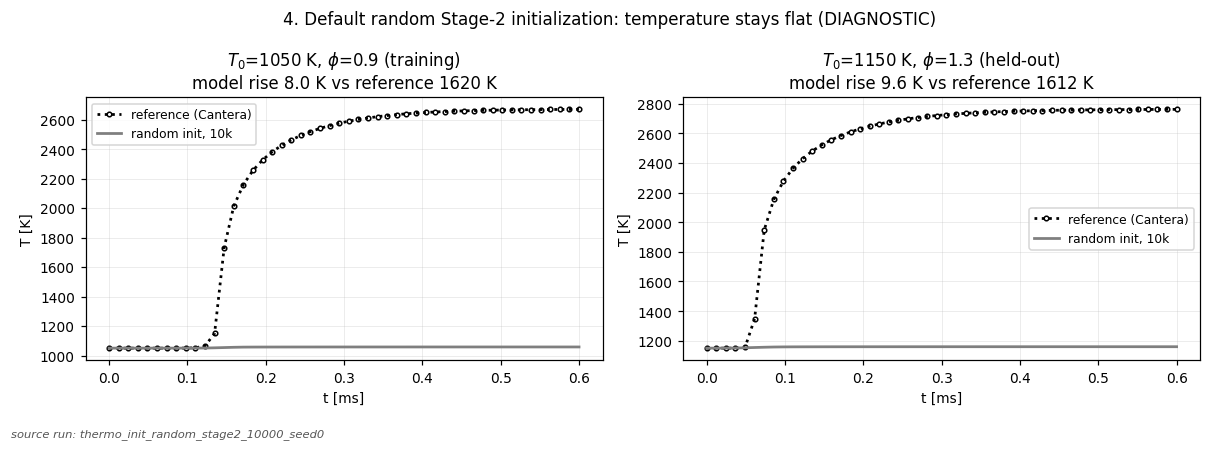

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for c, (T0, phi, role) in enumerate(CONDS):
    d = base[role]
    ax[c].plot(t * 1e3, d["ref"][:, -1], "ko:", ms=3, mfc="none", lw=1.8, label="reference (Cantera)")
    ax[c].plot(t * 1e3, d["pred"][:, -1], "-", color="#7f7f7f", lw=1.8, label="random init, 10k")
    ax[c].set_title(f"$T_0$={T0:.0f} K, $\\phi$={phi:g} ({role})\n"
                    f"model rise {d['peak_T_K']-d['pred'][0,-1]:.1f} K vs reference "
                    f"{d['reference_T_rise_K']:.0f} K")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("T [K]"); ax[c].legend(fontsize=8)
fig.suptitle("4. Default random Stage-2 initialization: temperature stays flat (DIAGNOSTIC)", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k")
fig.tight_layout(); plt.show()

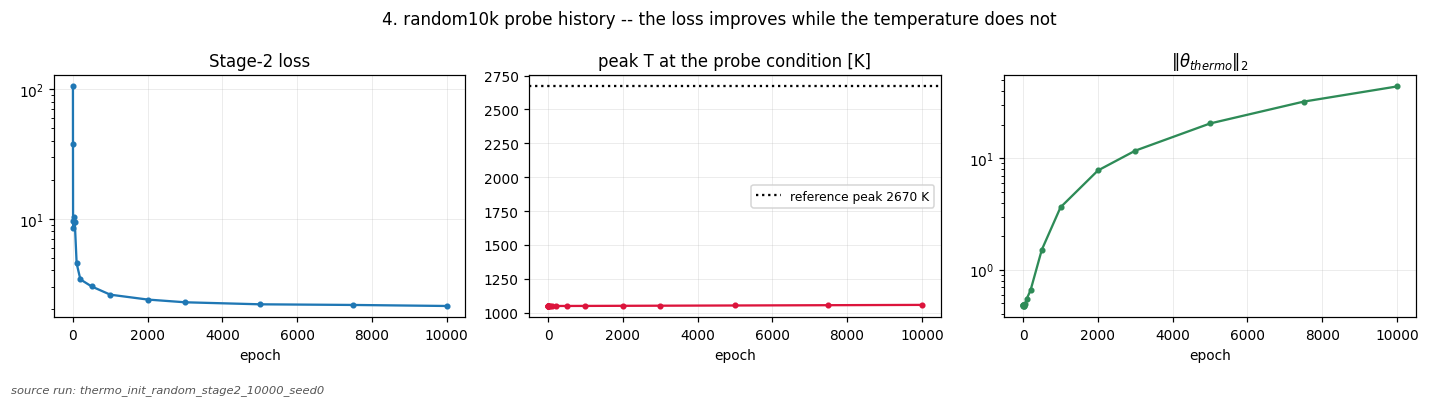

peak T over 10k epochs: 1050.0 K -> 1058.0 K
||thermo.linear||     : 0.4848 -> 43.9749  (x90.7)
ignites at any probe epoch: False


In [9]:
# Probe history of the control arm: loss falls, peak T does not move, ||thermo.linear|| grows slowly.
pr = probe_history(A["random10k"]["run_dir"])
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(pr["epoch"], pr["stage2_loss"], "o-", ms=3); ax[0].set_yscale("log")
ax[0].set_title("Stage-2 loss"); ax[0].set_xlabel("epoch")
ax[1].plot(pr["epoch"], pr["peak_T_K"], "o-", ms=3, color="crimson")
ax[1].axhline(base["training"]["reference_peak_T_K"], color="k", ls=":",
              label=f"reference peak {base['training']['reference_peak_T_K']:.0f} K")
ax[1].set_title("peak T at the probe condition [K]"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
ax[2].plot(pr["epoch"], pr["thermo_linear_norm"], "o-", ms=3, color="seagreen")
ax[2].set_yscale("log"); ax[2].set_title(r"$\|\theta_{thermo}\|_2$"); ax[2].set_xlabel("epoch")
fig.suptitle("4. random10k probe history -- the loss improves while the temperature does not", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k")
fig.tight_layout(); plt.show()
print(f"peak T over 10k epochs: {pr['peak_T_K'].iloc[0]:.1f} K -> {pr['peak_T_K'].iloc[-1]:.1f} K")
print(f"||thermo.linear||     : {pr['thermo_linear_norm'].iloc[0]:.4f} -> "
      f"{pr['thermo_linear_norm'].iloc[-1]:.4f}  (x{pr['thermo_linear_norm'].iloc[-1]/pr['thermo_linear_norm'].iloc[0]:.1f})")
print(f"ignites at any probe epoch: {bool(pr['ignites'].any())}")

**Reading §4.** The Stage-2 loss falls by roughly an order of magnitude, the temperature
channel does not move, and `‖θ_thermo‖` grows steadily but remains ~4 orders of magnitude
below the physical heat-release scale derived in §7. The optimizer is making progress on
the nine species — 9/10 of the equally-weighted Eq. 18 objective — while temperature stays
pinned near its initial value.

---
# 5. Stage-1 sanity check — is the kinetic core inert?

Stage 1 trains the kinetic core with the **observed** temperature history supplied from
the data (paper-explicit). The question here is narrow: *when the correct thermal history
is supplied, does the kinetic core produce meaningful species dynamics?*

This is the Stage-1 regime, integrated species-only with `ObservedTemperature` driving
`T(t)` from the reference — exactly the configuration the paper describes for Stage 1.

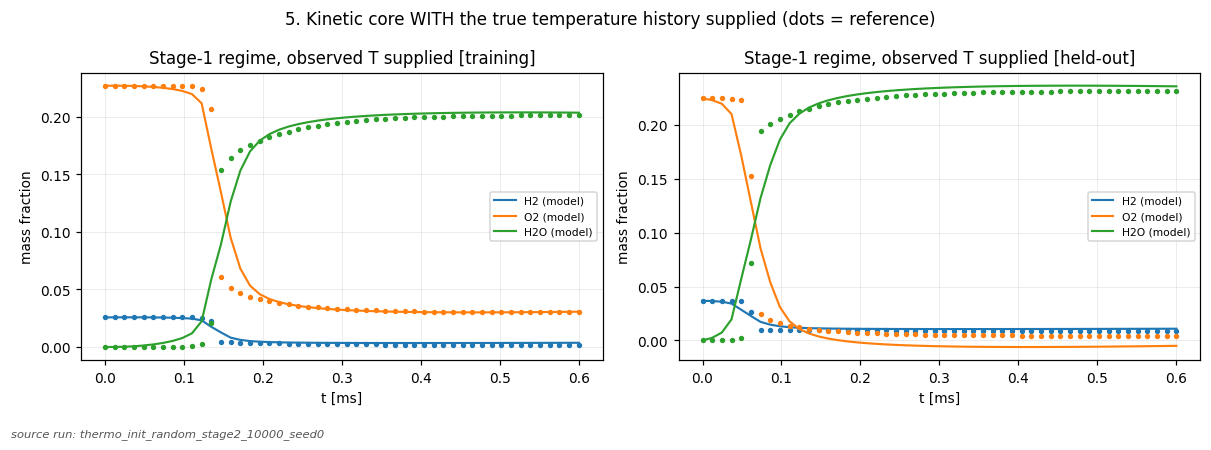

,stage1_species_MSE,closed_loop_case_MSE
condition,,
training,0.0557,0.0563
held-out,0.0700,0.0631


In [10]:
def stage1_species_observed_T(arm, T0, phi):
    """Species-only integration with THIS condition's true T(t) supplied (Stage-1 regime)."""
    ref = reference(T0, phi)
    obsT = ObservedTemperature(torch.as_tensor(t, dtype=torch.float32),
                               torch.as_tensor(ref[:, -1], dtype=torch.float32).reshape(-1, 1, 1))
    kin = KineticDynamics(arm["model"].kinetic, obsT, input_normalizer=arm["input_norm"])
    with torch.no_grad():
        return integrate(kin, torch.as_tensor(ref[0, :m], dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(t, dtype=torch.float32), arm["solver"])[:, 0].numpy()

rows = []
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for c, (T0, phi, role) in enumerate(CONDS):
    ref = reference(T0, phi)
    s1  = stage1_species_observed_T(A["random10k"], T0, phi)
    refN = normstate(ref)[:, :m]
    s1N  = normstate(np.c_[s1, ref[:, -1]])[:, :m]
    rows.append(dict(condition=role, stage1_species_MSE=float(((s1N - refN) ** 2).mean()),
                     closed_loop_case_MSE=base[role]["case_MSE"]))
    for sp in ("H2", "O2", "H2O"):
        k = species.index(sp)
        line, = ax[c].plot(t * 1e3, s1[:, k], "-", lw=1.4, label=f"{sp} (model)")
        ax[c].plot(t * 1e3, ref[:, k], "o", ms=2.5, color=line.get_color())
    ax[c].set_title(f"Stage-1 regime, observed T supplied [{role}]")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("mass fraction"); ax[c].legend(fontsize=7)
fig.suptitle("5. Kinetic core WITH the true temperature history supplied (dots = reference)", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k")
fig.tight_layout(); plt.show()
stage1_check = pd.DataFrame(rows).set_index("condition")
stage1_check

In [11]:
# Cross-check against the stored reaction-extent artifact of the PRIMARY run, if present.
p = OLD_TAB / "hydrogen_reaction_extent.csv"
if p.exists():
    print("reaction extent recorded for the primary run:", rel(p))
    display(pd.read_csv(p))
else:
    print("UNAVAILABLE:", rel(p), "-- reaction-extent artifact not found; skipping cross-check.")

reaction extent recorded for the primary run: results/reproduction/tables/hydrogen_reaction_extent.csv


,condition,role,H2_progress_%,O2_progress_%,H2O_progress_%,OH_progress_%,T_rise_ref_K,T_rise_model_K,T_rise_pct
0,1050/0.9,training,97.8,94.5,95.4,101.0,1619.7,8.0,0.5
1,1150/1.3,held-out,99.7,103.2,101.3,112.3,1611.6,9.6,0.6


**Interpretation (careful).** With the correct thermal history supplied, the kinetic core
tracks the major species through ignition. This shows the Stage-1 model **can produce
meaningful species dynamics under the correct thermal history**.

It does **not** prove the kinetic core is fully correct. In the closed loop the model
supplies its own temperature, and the reaction-extent artifact above shows that even in
the failed closed-loop run the species reach ~95–103 % of their final reference values
while the temperature rises by <10 K. The species are not the thing that is broken; that
is the observation §6 turns into a localization.

---
# 6. Localizing the failure to the thermodynamic pathway

Three diagnostics, in increasing specificity.

**A.** Per-state closed-loop error — which state dominates the failure?
**B.** Model RHS evaluated on the exact reference states (open loop) — is `dT/dt` itself wrong?
**C.** The decisive test: feed **reference** species rates into the **learned**
`thermo.linear` and ask whether the resulting temperature rate is even the right *size*.

> **Derivative provenance.** The reference `dY/dt` and `dT/dt` used here are
> `np.gradient` finite differences of the **stored 50-point trajectories**. They are an
> *approximate sampled-trajectory derivative*, **not** the exact Cantera right-hand side.
> Near the ignition peak this under-resolves the true rate, so the ratios below are, if
> anything, **generous** to the model.

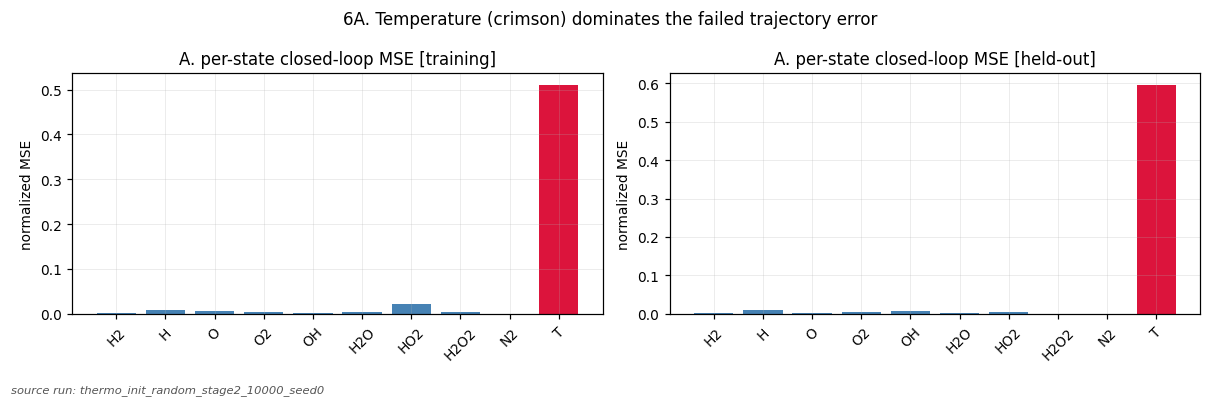

,H2,H,O,O2,OH,H2O,HO2,H2O2,N2,T,T_share_of_total
training,0.0012,0.0081,0.0068,0.0046,0.0029,0.0032,0.0211,0.0047,9.7396e-07,0.5102,0.9064
held-out,0.0017,0.0102,0.0026,0.0038,0.0083,0.0031,0.0050,0.0004,2.0426e-07,0.5960,0.9444


In [12]:
def rhs_along_reference(arm, T0, phi):
    """Model d[Y,T]/dt on the EXACT reference states (open loop) + finite-diff reference."""
    ref = reference(T0, phi)
    dyn = ChemKANDynamics(arm["model"], input_normalizer=arm["input_norm"])
    tf = torch.as_tensor(t, dtype=torch.float32)
    with torch.no_grad():
        md_ = torch.stack([dyn(tf[j], torch.as_tensor(ref[j], dtype=torch.float32).unsqueeze(0))[0]
                           for j in range(len(t))]).numpy()
    return md_, np.gradient(ref, t, axis=0), ref

# A. per-state closed-loop error
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
labels = species + ["T"]
per_state = {}
for c, (T0, phi, role) in enumerate(CONDS):
    d = base[role]
    per = ((normstate(d["pred"]) - normstate(d["ref"])) ** 2).mean(axis=0)
    per_state[role] = per
    ax[c].bar(labels, per, color=["crimson" if l == "T" else "steelblue" for l in labels])
    ax[c].set_title(f"A. per-state closed-loop MSE [{role}]"); ax[c].tick_params(axis="x", rotation=45)
    ax[c].set_ylabel("normalized MSE")
fig.suptitle("6A. Temperature (crimson) dominates the failed trajectory error", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k")
fig.tight_layout(); plt.show()
pd.DataFrame(per_state, index=labels).T.assign(
    T_share_of_total=lambda d: d["T"] / d.sum(axis=1))

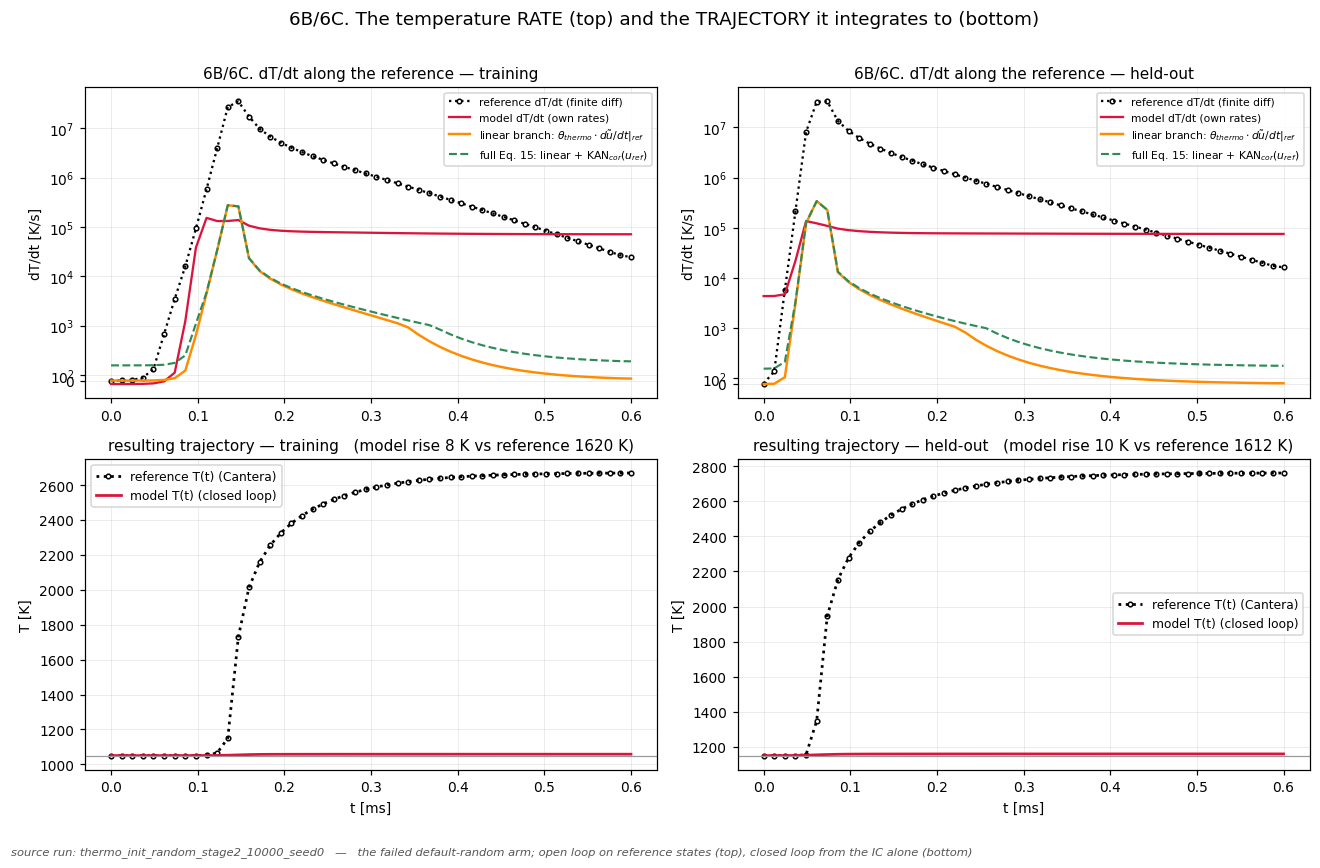

condition,training,held-out
reference_peak_dTdt,3.5282e+07,3.2899e+07
model_peak_dTdt,1.3901e+05,1.0932e+05
linear_branch_on_reference_rates,2.6330e+05,2.2727e+05
full_thermo_path_on_reference_rates,2.6362e+05,2.2758e+05
correction_at_peak,3.1540e+02,3.1698e+02
correction_share_of_full,1.1964e-03,1.3928e-03
deficit_factor_linear,1.3400e+02,1.4476e+02
deficit_factor_full,1.3384e+02,1.4456e+02
species_rate_relL2,1.5202e+00,1.4727e+00


In [13]:
# 6B & 6C. Open-loop temperature RATE on the exact reference states, decomposed,
# shown together with the TRAJECTORY that rate integrates to.
#
#   LINEAR-BRANCH ISOLATION   dT/dt_linear = theta_thermo . dYdt_reference
#   FULL THERMO PATH (Eq. 15) dT/dt_full   = theta_thermo . dYdt_reference + KAN_cor(u_ref)
#
# The correction term is evaluated on the NORMALIZED reference state, exactly as the model
# would see it inside ChemKANDynamics, so the two branches combine the way the forward pass
# combines them. Only the SOURCE of dYdt differs from a real forward pass: here it is the
# reference rate, not the model's own kinetic output.
def thermo_branches(arm, T0, phi):
    ref = reference(T0, phi)
    dref = np.gradient(ref, t, axis=0)                       # sampled-trajectory derivative
    W = arm["model"].thermo.linear.weight.detach().numpy().ravel()
    u = torch.as_tensor(ref, dtype=torch.float32)
    u_model = u if arm["input_norm"] is None else arm["input_norm"].normalize(u)
    with torch.no_grad():
        corr = arm["model"].thermo.correction(u_model).numpy().ravel()   # KAN_cor(u_ref)
    lin = dref[:, :m] @ W
    return dict(reference=dref[:, -1], linear=lin, correction=corr, full=lin + corr, dref=dref)

scale_rows = []
fig, ax = plt.subplots(2, 2, figsize=(12, 7.6))
for c, (T0, phi, role) in enumerate(CONDS):
    mdl, rd, ref = rhs_along_reference(A["random10k"], T0, phi)
    br = thermo_branches(A["random10k"], T0, phi)
    kmax = int(rd[:, -1].argmax())                      # reference peak-heat-release index

    # --- top row: the RATE dT/dt -------------------------------------------------
    a = ax[0, c]
    a.plot(t * 1e3, br["reference"], "ko:", ms=3, mfc="none", label="reference dT/dt (finite diff)")
    a.plot(t * 1e3, mdl[:, -1], "-", color="crimson", lw=1.5, label="model dT/dt (own rates)")
    a.plot(t * 1e3, br["linear"], "-", color="darkorange", lw=1.6,
           label=r"linear branch: $\theta_{thermo}\cdot d\tilde u/dt|_{ref}$")
    a.plot(t * 1e3, br["full"], "--", color="seagreen", lw=1.4,
           label=r"full Eq. 15: linear + KAN$_{cor}(u_{ref})$")
    a.set_yscale("symlog", linthresh=1e3)
    a.set_title(f"6B/6C. dT/dt along the reference — {role}", fontsize=10)
    a.set_ylabel("dT/dt [K/s]"); a.legend(fontsize=7)

    # --- bottom row: the TRAJECTORY that rate integrates to ----------------------
    b = ax[1, c]
    pred = closed_loop_T = integrate_arm(A["random10k"], T0, phi) if False else None
    u0 = torch.as_tensor(ref[0], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        pred = integrate_hydrogen(A["random10k"]["model"], A["random10k"]["input_norm"],
                                  A["random10k"]["solver"], u0,
                                  torch.as_tensor(t, dtype=torch.float32))[:, 0].numpy()
    b.plot(t * 1e3, ref[:, -1], "ko:", ms=3, mfc="none", lw=1.8, label="reference T(t) (Cantera)")
    b.plot(t * 1e3, pred[:, -1], "-", color="crimson", lw=1.8, label="model T(t) (closed loop)")
    b.axhline(T0, color="#999", lw=.8)
    b.set_title(f"resulting trajectory — {role}   "
                f"(model rise {pred[:, -1].max()-pred[0, -1]:.0f} K vs "
                f"reference {ref[:, -1].max()-ref[0, -1]:.0f} K)", fontsize=10)
    b.set_xlabel("t [ms]"); b.set_ylabel("T [K]"); b.legend(fontsize=8)

    scale_rows.append(dict(condition=role,
        reference_peak_dTdt=rd[kmax, -1], model_peak_dTdt=mdl[kmax, -1],
        linear_branch_on_reference_rates=float(br["linear"][kmax]),
        full_thermo_path_on_reference_rates=float(br["full"][kmax]),
        correction_at_peak=float(br["correction"][kmax]),
        correction_share_of_full=float(abs(br["correction"][kmax]) /
                                       (abs(br["full"][kmax]) + 1e-30)),
        deficit_factor_linear=float(rd[kmax, -1] / br["linear"][kmax]) if br["linear"][kmax] else np.nan,
        deficit_factor_full=float(rd[kmax, -1] / br["full"][kmax]) if br["full"][kmax] else np.nan,
        species_rate_relL2=float(np.linalg.norm(mdl[:, :m] - rd[:, :m]) /
                                 (np.linalg.norm(rd[:, :m]) + 1e-30))))
fig.suptitle("6B/6C. The temperature RATE (top) and the TRAJECTORY it integrates to (bottom)",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig_source(fig, "random10k", note="the failed default-random arm; open loop on reference states (top), closed loop from the IC alone (bottom)")
plt.show()
localization = pd.DataFrame(scale_rows).set_index("condition")
localization.T

In [14]:
# 6B/6C — the deficit factors, stated explicitly rather than left to be divided by hand.
#
# Three different "how far short is it?" questions, each isolating something different:
#
#   ref / model   the model's OWN dT/dt: its own species rates through its own thermo map.
#                 Includes BOTH error sources (rates too small AND coefficients too small).
#   ref / linear  REFERENCE species rates through the LEARNED theta_thermo. Removes the
#                 species-rate error, so it isolates the Eq. 14 COEFFICIENTS.
#   ref / full    the same plus KAN_cor(u_ref), i.e. the complete Eq. 15 path.
#
_L = localization
_def = pd.DataFrame({
    "reference peak dT/dt [K/s]":            _L["reference_peak_dTdt"],
    "model peak dT/dt [K/s]":                _L["model_peak_dTdt"],
    "DEFICIT  ref / model":                  _L["reference_peak_dTdt"] / _L["model_peak_dTdt"],
    "linear branch on reference rates [K/s]": _L["linear_branch_on_reference_rates"],
    "DEFICIT  ref / linear branch":          _L["deficit_factor_linear"],
    "full Eq. 15 on reference rates [K/s]":  _L["full_thermo_path_on_reference_rates"],
    "DEFICIT  ref / full Eq. 15":            _L["deficit_factor_full"],
    "KAN_cor share of the full path":        _L["correction_share_of_full"],
    "species-rate relative L2 error":        _L["species_rate_relL2"],
}).T
display(_def)

print("Worked example — training condition (T0 = 1050 K, phi = 0.9), at the reference "
      "peak-heat-release instant:\n")
_tr = _L.loc["training"]
print(f"   reference dT/dt = {_tr.reference_peak_dTdt:.4e} K/s")
print(f"   model     dT/dt = {_tr.model_peak_dTdt:.4e} K/s")
print(f"   ratio           = {_tr.reference_peak_dTdt:.4e} / {_tr.model_peak_dTdt:.4e} "
      f"= {_tr.reference_peak_dTdt/_tr.model_peak_dTdt:.1f}x too small\n")
print("   and with the SPECIES-RATE error removed (reference rates through the learned map):")
print(f"   ratio           = {_tr.reference_peak_dTdt:.4e} / {_tr.linear_branch_on_reference_rates:.4e} "
      f"= {_tr.deficit_factor_linear:.1f}x too small")
print(f"\n   -> of the {_tr.reference_peak_dTdt/_tr.model_peak_dTdt:.0f}x total shortfall, "
      f"{_tr.deficit_factor_linear:.0f}x survives even when the model is handed the TRUE species")
print(f"      rates. The remaining factor of "
      f"{(_tr.reference_peak_dTdt/_tr.model_peak_dTdt)/_tr.deficit_factor_linear:.1f}x comes from its "
      "own species rates being too small.")

condition,training,held-out
reference peak dT/dt [K/s],3.5282e+07,3.2899e+07
model peak dT/dt [K/s],1.3901e+05,1.0932e+05
DEFICIT ref / model,2.5382e+02,3.0094e+02
linear branch on reference rates [K/s],2.6330e+05,2.2727e+05
DEFICIT ref / linear branch,1.3400e+02,1.4476e+02
full Eq. 15 on reference rates [K/s],2.6362e+05,2.2758e+05
DEFICIT ref / full Eq. 15,1.3384e+02,1.4456e+02
KAN_cor share of the full path,1.1964e-03,1.3928e-03
species-rate relative L2 error,1.5202e+00,1.4727e+00


Worked example — training condition (T0 = 1050 K, phi = 0.9), at the reference peak-heat-release instant:

   reference dT/dt = 3.5282e+07 K/s
   model     dT/dt = 1.3901e+05 K/s
   ratio           = 3.5282e+07 / 1.3901e+05 = 253.8x too small

   and with the SPECIES-RATE error removed (reference rates through the learned map):
   ratio           = 3.5282e+07 / 2.6330e+05 = 134.0x too small

   -> of the 254x total shortfall, 134x survives even when the model is handed the TRUE species
      rates. The remaining factor of 1.9x comes from its own species rates being too small.


**Reading the deficit table.** Three ratios, and the difference between them is the whole
point of the decomposition:

* **`ref / model` ≈ 254× (training), 301× (held-out)** — the model's own temperature rate at
  the reference states. This is the headline shortfall, and it mixes two causes.
* **`ref / linear branch` ≈ 134× / 145×** — the *reference* species rates pushed through the
  *learned* `θ_thermo`. The species-rate error is removed here, so what remains is
  attributable to the nine Eq. 14 coefficients alone.
* **`ref / full Eq. 15` ≈ 134× / 145×** — indistinguishable from the linear branch, because
  `KAN_cor` contributes only ~0.1 % of the total (`KAN_cor share` row).

So the ~254× total splits into roughly **134× from the coefficients** and the remaining
**~1.9× from the model's species rates being too slow at the peak**. The coefficients are the
dominant term, and the correction network is not involved either way.

In [15]:
# Reconciliation with the STORED per-state artifact of the primary run.
# Two things must be checked before the numbers can be compared at all:
#   (i) metric convention -- Eq. 18 SUMS over the Nt observation times; the per-state
#       values above are MEANS over time, so they differ by exactly Nt = len(t).
#  (ii) which run -- the stored artifact is the primary run, the cells above use the
#       controlled random10k arm.
p = OLD_TAB / "fig07_hydrogen_per_state_mse.csv"
if not p.exists():
    print("UNAVAILABLE:", rel(p), "-- skipping reconciliation.")
else:
    stored = pd.read_csv(p).set_index("role")
    rec = pd.DataFrame({
        "recomputed T_MSE (mean over time)":  {r: per_state[r][-1] for r in ("training", "held-out")},
        "x Nt (= Eq. 18 sum over time)":      {r: per_state[r][-1] * len(t) for r in ("training", "held-out")},
        "stored T_MSE (primary run)":         stored["T_MSE"].to_dict(),
    })
    display(rec)
    agree = np.allclose(rec["x Nt (= Eq. 18 sum over time)"], rec["stored T_MSE (primary run)"], rtol=1e-3)
    print(f"convention difference is exactly Nt = {len(t)}: {agree}")

    # The controlled arm and the primary run are then the SAME model, as expected:
    # both trained Stage 1 for 10k epochs at seed 0 and Stage 2 randomly for 10k.
    w_main = A["main_10k"]["w"]
    print(f"\nprimary run   thermo.linear norm = {np.linalg.norm(w_main):.4f}")
    print(f"random10k arm thermo.linear norm = {np.linalg.norm(A['random10k']['w']):.4f}")
    print(f"identical thermo.linear vectors  = {np.allclose(w_main, A['random10k']['w'], rtol=1e-6)}")
    print("-> the controlled random arm REPRODUCES the primary failed run; the diagnostics")
    print("   in this notebook therefore apply to the primary result as well.")

,recomputed T_MSE (mean over time),x Nt (= Eq. 18 sum over time),stored T_MSE (primary run)
training,0.5102,25.5102,25.5102
held-out,0.5960,29.8004,29.8004


convention difference is exactly Nt = 50: True

primary run   thermo.linear norm = 43.9749
random10k arm thermo.linear norm = 43.9749
identical thermo.linear vectors  = True
-> the controlled random arm REPRODUCES the primary failed run; the diagnostics
   in this notebook therefore apply to the primary result as well.


**Reading §6 — carefully.**

Temperature carries the overwhelming majority of the normalized closed-loop trajectory
error (the share is printed above). In the open loop, even when the model is handed the
**exact reference states**, its `dT/dt` falls far short of the reference at the
heat-release peak. Decisively, when the **reference** species rates are pushed through the
**learned** `θ_thermo`, the resulting temperature rate is still short by the
`deficit_factor_linear` printed above — so the shortfall cannot be blamed on the species
rates the model itself produces. Adding `KAN_cor` (the full Eq. 15 path) changes this
picture by the `correction_share_of_full` fraction shown; the correction is not what is
carrying the heat release.

The correct statement of what this establishes is narrow:

> **Temperature dominates the closed-loop trajectory error, and the thermodynamic pathway
> is independently severely inadequate in the failed reproduction. The kinetic pathway is
> active — it tracks the major species under the true thermal history (§5) — but it has
> *not* been established as fully correct.**

The species relative-L2 rate error printed above is itself of order one, so the kinetic
core is *not* exact. What §6 rules out is the hypothesis that the flat temperature is
merely a downstream consequence of bad species rates: it is not, because the same failure
appears when the species rates are replaced by the truth. §7 quantifies the coefficient
scale that is missing.

---
# 6D. Fixed-temperature kinetic diagnostic — does the kinetic core react without heat?

> ## DIAGNOSTIC ONLY — this section changes no conclusion elsewhere until its result is read.

**The question, from the 28.08.2026 supervisor meeting.** If the model's temperature stays
low and flat, why do its species still evolve? The concern was that Arrhenius chemistry
evaluated at ~1050 K should barely react, so a model that burns all its fuel at a frozen
temperature would have learned a kinetic core with **weak temperature gating**.

**The test.** Remove the thermodynamic pathway entirely. Integrate species only,

$$\frac{d\tilde u}{dt} = \mathrm{KAN}_{kin}\big([\,\tilde u,\; T_{\text{fixed}}\,]\big),
\qquad T(t) \equiv T_{\text{fixed}},$$

and compare against **Cantera with the energy equation disabled** — the true isothermal
chemistry at the same fixed temperature, composition, pressure, mechanism, grid and
tolerances.

**Two kinetic cores are compared**, because it matters *when* any pathology appeared:

| core | source |
|---|---|
| **Stage-1** | `diagnostics/stage1_seed0/checkpoint_stage1.pt` — before Stage 2 ever ran |
| **Stage-2 final** | `thermo_init_random_stage2_10000_seed0/checkpoint_final.pt` — the failed arm |

**Pre-registered reading** (fixed before looking at the numbers):

* both cores react far more than isothermal Cantera → weak temperature gating was **already
  present after Stage 1**;
* Stage-1 reasonable but Stage-2 excessive → **Stage 2 damaged the kinetic core**;
* both track isothermal Cantera → the closed-loop species behaviour needs a **different**
  explanation, and "the kinetic core ignores temperature" is refuted.

**The comparison that matters is against the isothermal reference, not against zero.** The
question is not whether species *must* stay constant at 1050 K — it is whether the learned
core reacts *substantially more strongly than the true isothermal chemistry does*.

In [16]:
from chemkan.temperature import ConstantTemperature
from _isothermal import initial_composition, isothermal_case

T_FIXED = [950.0, 1050.0, 1150.0]        # K, held constant for the whole integration
PHI_FIX = 0.9                             # representative composition
t_fix = t                                 # existing 50-point grid over 0-0.6 ms

# --- the two learned kinetic cores ---------------------------------------------------
def _kinetic_from(path, kinetic_state_key=None):
    """Rebuild a ChemKAN and return (kinetic module, input normalizer, solver)."""
    ck = torch.load(path, map_location="cpu", weights_only=False)
    mdl = ChemKAN_(species_dim=m, **ck["architecture"])
    if kinetic_state_key:                                  # Stage-1 artifact: kinetic only
        mdl.kinetic.load_state_dict(ck[kinetic_state_key])
    else:
        mdl.load_state_dict(ck["model_state"])
    sc = ck["input_scaling"]
    inorm = (None if sc.get("method") == "none"
             else MinMaxNormalizer(sc["u_min"], sc["u_max"]))
    return mdl.kinetic.eval(), inorm, solver_from_ckpt(ck)

from chemkan.model import ChemKAN as ChemKAN_
CORES = {
    "Stage-1 (before Stage 2)": _kinetic_from(
        DIAG / "stage1_seed0" / "checkpoint_stage1.pt", "kinetic_state"),
    "Stage-2 final (failed arm)": _kinetic_from(
        DIAG / "thermo_init_random_stage2_10000_seed0" / "checkpoint_final.pt"),
}
_ref_names, _Y0 = initial_composition(PHI_FIX, T_FIXED[0])
assert _ref_names == species, "species order mismatch with the isothermal helper"
print(f"initial composition at phi={PHI_FIX} (mass fractions, T-independent):")
print("   " + "  ".join(f"{s}={v:.4g}" for s, v in zip(species, _Y0) if v > 0))

def fixed_T_species(core, inorm, solver, T_fixed, Y0, tt):
    """Species-only integration with T held CONSTANT. No thermodynamic pathway at all."""
    kin, = (core,)
    dyn = KineticDynamics(kin, ConstantTemperature(torch.tensor([[float(T_fixed)]])),
                          input_normalizer=inorm)
    with torch.no_grad():
        return integrate(dyn, torch.as_tensor(Y0, dtype=torch.float32).unsqueeze(0),
                         torch.as_tensor(tt, dtype=torch.float32), solver)[:, 0].numpy()

def dYdt_at(core, inorm, T_fixed, Y):
    """||dY/dt|| from the kinetic core at given states, at fixed T."""
    Y = np.atleast_2d(np.asarray(Y, dtype=np.float32))
    u = torch.cat([torch.as_tensor(Y), torch.full((len(Y), 1), float(T_fixed))], dim=-1)
    u = u if inorm is None else inorm.normalize(u)
    with torch.no_grad():
        return np.linalg.norm(core(u).numpy(), axis=-1)

initial composition at phi=0.9 (mass fractions, T-independent):
   H2=0.02574  O2=0.227  N2=0.7473


In [17]:
# Integrate every (core, T_fixed) pair and the matching isothermal Cantera reference.
ISO = {}
rows = []
for T_fix in T_FIXED:
    _, Y0 = initial_composition(PHI_FIX, T_fix)
    names, Y_ct, T_check = isothermal_case(T_fix, PHI_FIX, t_fix)
    assert np.allclose(T_check, T_fix), "Cantera temperature did not stay fixed"
    ISO[("Cantera isothermal", T_fix)] = Y_ct
    rows.append(dict(core="Cantera isothermal (truth)", T_fixed=T_fix,
                     max_abs_dY=float(np.abs(Y_ct - Y_ct[0]).max()),
                     total_abs_dY=float(np.abs(Y_ct[-1] - Y_ct[0]).sum()),
                     species_MSE_vs_isothermal=0.0,
                     norm_dYdt_t0=np.nan, max_norm_dYdt=np.nan))
    for label, (core, inorm, solver) in CORES.items():
        Y_m = fixed_T_species(core, inorm, solver, T_fix, Y0, t_fix)
        ISO[(label, T_fix)] = Y_m
        sub = full_norm.subset(slice(0, m))          # species-only Eq. 18 coordinates
        dn = (sub.normalize(torch.as_tensor(Y_m, dtype=torch.float32))
              - sub.normalize(torch.as_tensor(Y_ct, dtype=torch.float32))).numpy()
        g = dYdt_at(core, inorm, T_fix, Y_m)
        rows.append(dict(core=label, T_fixed=T_fix,
                         max_abs_dY=float(np.abs(Y_m - Y_m[0]).max()),
                         total_abs_dY=float(np.abs(Y_m[-1] - Y_m[0]).sum()),
                         species_MSE_vs_isothermal=float((dn ** 2).mean()),
                         norm_dYdt_t0=float(g[0]), max_norm_dYdt=float(g.max())))
FIXT = pd.DataFrame(rows).set_index(["T_fixed", "core"])
display(FIXT.round(6))

print("Reaction strength RELATIVE to the true isothermal chemistry "
      "(max|ΔY| model / max|ΔY| Cantera):")
for T_fix in T_FIXED:
    ct_v = FIXT.loc[(T_fix, "Cantera isothermal (truth)"), "max_abs_dY"]
    line = "   ".join(f"{lab.split(' (')[0]}: x{FIXT.loc[(T_fix, lab), 'max_abs_dY']/ct_v:,.1f}"
                      for lab in CORES)
    print(f"   T = {T_fix:6.0f} K  (Cantera max|ΔY| = {ct_v:.3e})   {line}")

max_abs_dY  total_abs_dY  species_MSE_vs_isothermal  norm_dYdt_t0  max_norm_dYdt
T_fixed core                                                                                                        
950.0   Cantera isothermal (truth)      0.0000        0.0000                     0.0000           NaN            NaN
        Stage-1 (before Stage 2)        0.0051        0.0081                     0.0014       83.9323        83.9323
        Stage-2 final (failed arm)      0.0116        0.0269                     0.0008       29.2471        31.3345
1050.0  Cantera isothermal (truth)      0.2101        0.4206                     0.0000           NaN            NaN
        Stage-1 (before Stage 2)        0.2661        0.5674                     1.9106       22.7840      5004.2988
        Stage-2 final (failed arm)      0.1909        0.4177                     0.1825       10.3995      5239.1914
1150.0  Cantera isothermal (truth)      0.2286        0.4575                     0.0000           NaN            NaN
        Stage-1 (before Stage 2)        0.2980        0.6460                     4.0865      204.8352      4966.7686
        Stage-2 final (failed arm)      0.1991        0.4361                     0.1264       67.4621      5151.1528

Reaction strength RELATIVE to the true isothermal chemistry (max|ΔY| model / max|ΔY| Cantera):
   T =    950 K  (Cantera max|ΔY| = 8.221e-08)   Stage-1: x62,367.9   Stage-2 final: x141,626.9
   T =   1050 K  (Cantera max|ΔY| = 2.101e-01)   Stage-1: x1.3   Stage-2 final: x0.9
   T =   1150 K  (Cantera max|ΔY| = 2.286e-01)   Stage-1: x1.3   Stage-2 final: x0.9


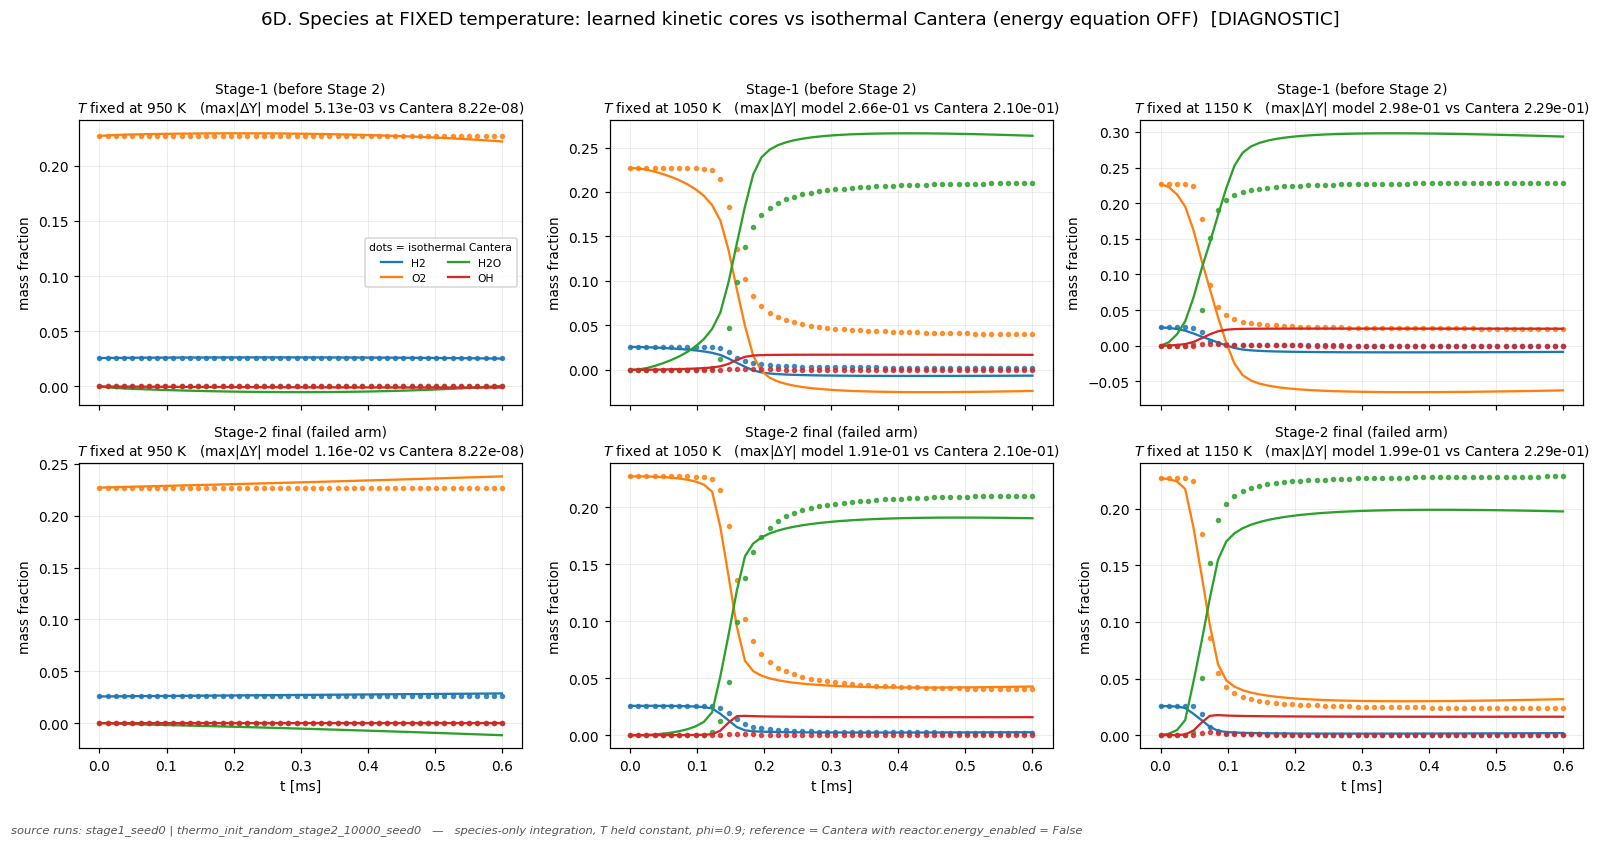

In [18]:
# One column per fixed temperature; dots = isothermal Cantera truth, lines = learned cores.
_show = ["H2", "O2", "H2O", "OH"]
fig, axs = plt.subplots(2, len(T_FIXED), figsize=(14.5, 7.4), sharex=True)
cmap = plt.get_cmap("tab10")
for c, T_fix in enumerate(T_FIXED):
    for r, label in enumerate(CORES):
        ax = axs[r, c]
        Y_ct, Y_m = ISO[("Cantera isothermal", T_fix)], ISO[(label, T_fix)]
        for k, s in enumerate(_show):
            j = species.index(s)
            ax.plot(t_fix * 1e3, Y_ct[:, j], "o", ms=2.6, color=cmap(k), alpha=.8)
            ax.plot(t_fix * 1e3, Y_m[:, j], "-", lw=1.5, color=cmap(k), label=s)
        ax.set_title(f"{label}\n$T$ fixed at {T_fix:.0f} K   "
                     f"(max|ΔY| model {np.abs(Y_m-Y_m[0]).max():.2e} vs "
                     f"Cantera {np.abs(Y_ct-Y_ct[0]).max():.2e})", fontsize=9)
        ax.set_ylabel("mass fraction")
        if r == 1:
            ax.set_xlabel("t [ms]")
        if r == 0 and c == 0:
            ax.legend(fontsize=7, ncol=2, title="dots = isothermal Cantera", title_fontsize=7)
fig.suptitle("6D. Species at FIXED temperature: learned kinetic cores vs isothermal Cantera "
             "(energy equation OFF)  [DIAGNOSTIC]", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig_source(fig, "stage1", "random10k",
           note=f"species-only integration, T held constant, phi={PHI_FIX}; "
                "reference = Cantera with reactor.energy_enabled = False")
plt.show()

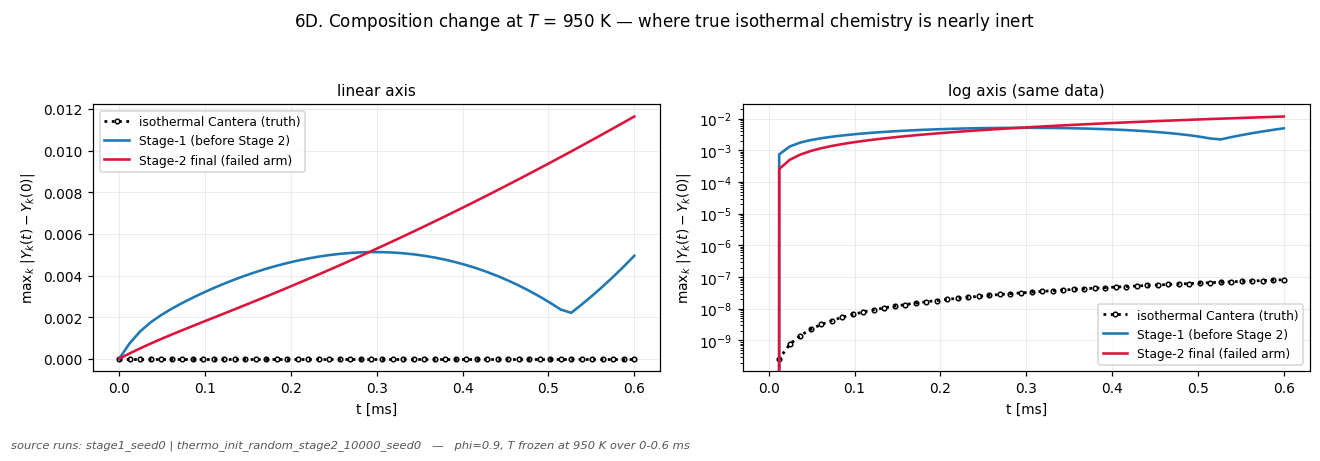

At 950 K over 0.6 ms:
   Cantera isothermal (truth)   max|ΔY| = 8.221e-08
   Stage-1 (before Stage 2)     max|ΔY| = 5.127e-03   ||dY/dt||(t=0) = 8.393e+01
   Stage-2 final (failed arm)   max|ΔY| = 1.164e-02   ||dY/dt||(t=0) = 2.925e+01


In [19]:
# The decisive case: 950 K, where the TRUE isothermal chemistry is essentially inactive.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
T_fix = 950.0
Y_ct = ISO[("Cantera isothermal", T_fix)]
for a, (scale, ttl) in zip(ax, [("linear", "linear axis"), ("log", "log axis (same data)")]):
    a.plot(t_fix * 1e3, np.abs(Y_ct - Y_ct[0]).max(axis=1), "ko:", ms=3, mfc="none",
           lw=1.8, label="isothermal Cantera (truth)")
    for label, col in zip(CORES, ("#1f77b4", "crimson")):
        Y_m = ISO[(label, T_fix)]
        a.plot(t_fix * 1e3, np.abs(Y_m - Y_m[0]).max(axis=1), "-", lw=1.7, color=col,
               label=label)
    a.set_yscale(scale); a.set_xlabel("t [ms]")
    a.set_ylabel(r"max$_k$ $|Y_k(t)-Y_k(0)|$"); a.set_title(ttl, fontsize=10); a.legend(fontsize=8)
fig.suptitle(f"6D. Composition change at $T$ = {T_fix:.0f} K — where true isothermal "
             "chemistry is nearly inert", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig_source(fig, "stage1", "random10k", note=f"phi={PHI_FIX}, T frozen at {T_fix:.0f} K over 0-0.6 ms")
plt.show()

print(f"At {T_fix:.0f} K over {t_fix[-1]*1e3:.1f} ms:")
for lab in ["Cantera isothermal (truth)"] + list(CORES):
    r = FIXT.loc[(T_fix, lab)]
    print(f"   {lab:28s} max|ΔY| = {r.max_abs_dY:.3e}   "
          f"||dY/dt||(t=0) = {r.norm_dYdt_t0:.3e}" if np.isfinite(r.norm_dYdt_t0)
          else f"   {lab:28s} max|ΔY| = {r.max_abs_dY:.3e}")

### Reading 6D — the answer is temperature-dependent, and it corrects an earlier claim

**At 950 K the learned cores react ~10⁵× too strongly.** True isothermal chemistry is
essentially inert over 0.6 ms (`max|ΔY| = 8.2e-08`). Both learned cores are not:

| core | `max\|ΔY\|` at 950 K | vs truth |
|---|---|---|
| Cantera isothermal (truth) | 8.2e-08 | — |
| Stage-1 (before Stage 2) | 5.1e-03 | **×62 000** |
| Stage-2 final (failed arm) | 1.2e-02 | **×142 000** |

This is a real defect: **weak temperature gating at low temperature**. Per the pre-registered
reading, it was **already present after Stage 1** — Stage 2 roughly doubled it (5.1e-03 →
1.2e-02) but did not create it. The Stage-1 core already produces `‖dY/dt‖ ≈ 84` at a state
where the true chemistry is quiescent.

**At 1050 K and 1150 K the extent is roughly right.** Here the true isothermal chemistry
*does* react essentially to completion within the 0.6 ms window, and both cores are close to it:

| T | Cantera `max\|ΔY\|` | Stage-1 | Stage-2 final |
|---|---|---|---|
| 1050 K | 0.2101 | ×1.3 | ×0.9 |
| 1150 K | 0.2286 | ×1.3 | ×0.9 |

Note also that Stage 2 *improved* agreement with the isothermal trajectory (species MSE 1.91 →
0.18 at 1050 K) while worsening the 950 K leakage. The two effects move in opposite directions.

> ### Correction to an earlier statement
>
> Elsewhere in this project the failed closed-loop behaviour was described as *"the chemistry
> ran to completion isothermally, which is physically impossible."* **That inference is
> wrong, and 6D refutes it.** At a frozen 1050 K, real Cantera chemistry with the energy
> equation disabled reaches `max|ΔY| = 0.2101` — essentially the same extent as the adiabatic
> reference (0.2014). Hydrogen at 1050 K and 1 atm ignites well inside 0.6 ms *without* any
> temperature rise. So a model that consumes its fuel while sitting at ~1050 K is **not**
> doing something impossible, and the observation alone is not evidence of broken kinetics.
>
> What survives is narrower and still holds: the **thermodynamic pathway** fails to convert
> that reaction into heat (§6B/6C), and the kinetic core has a genuine **low-temperature
> gating defect** (this section). The supervisor's original question — *"if T stays low, why
> do species still evolve?"* — is now answered concretely: at 1050 K they are *supposed* to,
> and at 950 K they are not, which is where the model is actually wrong.

**What this does NOT establish.** One composition (φ = 0.9) and three temperatures. The 950 K
excess is measured at a fixed initial composition, not along a trajectory the model would
actually visit. And "extent is right at 1050 K" says nothing about the *rate* or *timing* being
right — the isothermal species MSE is 0.13–0.18 for the Stage-2 core, far from zero.

---
# 7. What numerical scale does Eq. 14 require here?

For an adiabatic constant-pressure reactor the energy equation gives

$$\frac{dT}{dt} = -\frac{1}{c_p}\sum_k h_k \frac{dY_k}{dt} \;=\; \sum_k c_k \frac{dY_k}{dt},
\qquad c_k = -\frac{h_k}{c_p}\ \ [\mathrm{K}]$$

with `h_k` the **specific** enthalpy [J/kg] and `c_p` the mixture specific heat
[J/(kg·K)]. Cantera reports `partial_molar_enthalpies` in J/kmol, so it is divided by the
molecular weight [kg/kmol] **exactly once** (`_thermo_coeffs.cantera_coefficients`); a
second division would be a units error.

Two caveats stated up front:

* `thermo.linear` holds **one constant scalar per species**, while the physical `c_k`
  vary with temperature and mixture. A learned constant is **not** expected to equal the
  pointwise Cantera value.
* Eq. 14/15 also contains `KAN_cor`, which is precisely what is meant to absorb that
  state dependence. The comparison below is a **magnitude / sign / structure** diagnostic.

In [20]:
# Learned coefficients at epoch 0 and epoch 10000, straight from the probe history.
coeff_cols = [f"coeff_{s}" for s in species]
pr_rand = probe_history(A["random10k"]["run_dir"])
w_init  = pr_rand.loc[pr_rand["epoch"] == 0, coeff_cols].to_numpy().ravel()
w_final = pr_rand[coeff_cols].to_numpy()[-1]
assert np.allclose(w_final, A["random10k"]["w"], rtol=1e-4), \
    "probe final coefficients disagree with the checkpoint"

# Physical coefficients at the reference state actually used by the diagnostics.
REF_T, REF_PHI = 1050.0, 0.5
ref_Y = resolve_training_ic(npz["train_ics"], npz["train_states"], REF_T, REF_PHI, species_dim=m)
c_phys, cp_mass = cantera_coefficients(REF_T, ref_Y, species=species, mech=MECH)

coeff_table = pd.DataFrame({
    "random_init (epoch 0)":  w_init,
    "random_trained (10k)":   w_final,
    f"physical -h_k/cp @ {REF_T:.0f} K, phi={REF_PHI} [K]": c_phys,
}, index=species)
coeff_table["|physical| / |trained|"] = np.abs(c_phys) / np.abs(w_final)
print(f"cp_mass = {cp_mass:.2f} J/(kg K)   mechanism = {MECH}")
print(f"||w_init||   = {np.linalg.norm(w_init):.6f}")
print(f"||w_trained||= {np.linalg.norm(w_final):.4f}")
print(f"||c_phys||   = {np.linalg.norm(c_phys):.4f}   "
      f"-> ratio {np.linalg.norm(c_phys)/np.linalg.norm(w_final):.1f}x")
coeff_table

cp_mass = 1360.63 J/(kg K)   mechanism = h2o2.yaml
||w_init||   = 0.484827
||w_trained||= 43.9749
||c_phys||   = 171227.4433   -> ratio 3893.8x


,random_init (epoch 0),random_trained (10k),"physical -h_k/cp @ 1050 K, phi=0.5 [K]",|physical| / |trained|
H2,0.0033,-18.2778,-8093.1686,442.7868
H,0.1378,15.2263,-170340.8934,11187.2808
O,0.0261,16.7857,-12176.9974,725.4388
O2,0.0278,-18.7719,-561.7267,29.9238
OH,0.0416,19.4617,-2670.9467,137.2412
H2O,-0.2620,18.3325,8719.9185,475.6535
HO2,0.0262,3.5168,-990.8854,281.7545
H2O2,0.2308,2.4971,2050.0424,820.9759
N2,0.3004,-0.5399,-606.4103,1123.0943


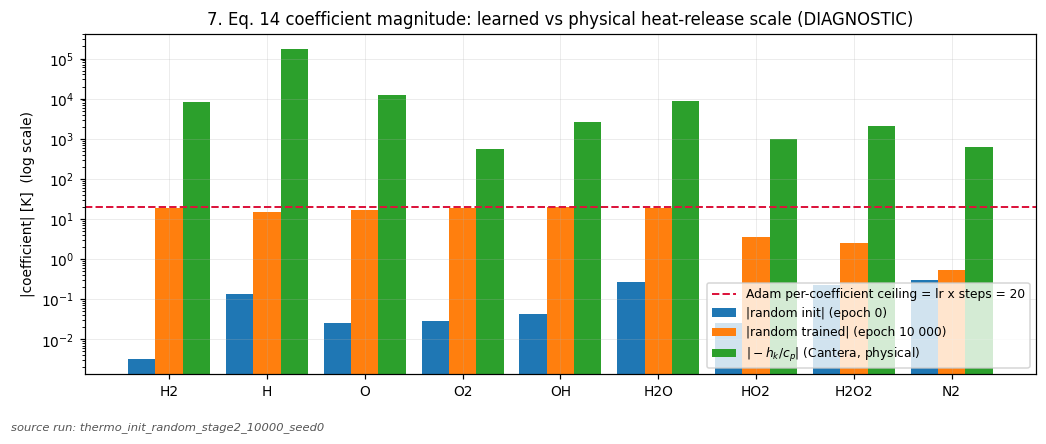

largest single trained coefficient : 19.46 K  (97% of the Adam ceiling 20)
L2 NORM of the 9 trained coefficients: 43.9749   <- a vector length across all nine, NOT any single bar
largest physical coefficient        : 170341 K


In [21]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
x = np.arange(m); wdt = 0.28
ax.bar(x - wdt, np.abs(w_init),  wdt, label="|random init| (epoch 0)")
ax.bar(x,        np.abs(w_final), wdt, label="|random trained| (epoch 10 000)")
ax.bar(x + wdt, np.abs(c_phys),  wdt, label=r"$|-h_k/c_p|$ (Cantera, physical)")
# How far could ONE coefficient possibly travel? Adam's per-coordinate step is bounded by
# ~lr, so over N steps the ceiling is lr*N. This explains WHERE the trained bars stop.
_ceiling = 2e-3 * 10000
ax.axhline(_ceiling, color="crimson", ls="--", lw=1.3,
           label=f"Adam per-coefficient ceiling = lr x steps = {_ceiling:.0f}")
ax.set_yscale("log"); ax.set_xticks(x, species); ax.set_ylabel("|coefficient| [K]  (log scale)")
ax.set_title("7. Eq. 14 coefficient magnitude: learned vs physical heat-release scale (DIAGNOSTIC)")
ax.legend(fontsize=8, loc="lower right"); fig.tight_layout(); fig_source(fig, "random10k")
ax.legend(fontsize=8, loc="lower right"); fig.tight_layout(); plt.show()

print(f"largest single trained coefficient : {np.abs(w_final).max():.2f} K  "
      f"({100*np.abs(w_final).max()/_ceiling:.0f}% of the Adam ceiling {_ceiling:.0f})")
print(f"L2 NORM of the 9 trained coefficients: {np.linalg.norm(w_final):.4f}"
      "   <- a vector length across all nine, NOT any single bar")
print(f"largest physical coefficient        : {np.abs(c_phys).max():.0f} K")

**Reading this figure — three points that are easy to misread.**

1. **The y-axis is logarithmic.** The orange bars top out just above `10^1`, i.e. **~19 K**,
   not ~100. The tallest is `OH` at 19.46 K.
2. **A single bar is not the norm.** Individual coefficients span 0.54 – 19.46 K; the L2
   *norm* quoted elsewhere, `‖θ‖ = 43.97`, is the length of the nine-component vector
   (`√Σθ_k²`), so it is necessarily larger than any single bar. Both numbers describe the
   same vector.
3. **How the coefficients reached ~19 and stopped there.** They start at O(0.03–0.3). Adam's
   per-coordinate update is bounded by roughly `lr` per step, so in 10 000 steps a single
   coefficient can travel at most `lr × steps = 0.002 × 10 000 = 20`. The largest trained
   coefficient is **19.46 — about 97 % of that ceiling**. The optimizer moved these
   parameters essentially as far as it is able to, and they are still ~3900× below the
   physical scale (green bars). This is why "just train longer" is not a fix: at this
   learning rate, reaching O(10⁵) from O(0.1) would require on the order of 10⁷ Adam steps
   even if every step were perfectly aligned.

---
# 8. Physical coefficient intervention (no retraining)

Take the **failed trained model**, replace **only** `thermo.linear.weight` with
Cantera-derived physical coefficients, and leave the kinetic core and `KAN_cor`
untouched. Nothing is retrained. Because `-h_k/c_p` is state dependent, the repository
script repeats the swap at four reference states along each trajectory.

Produced by `chemkan/scripts/diagnostics/hydrogen_thermo_intervention.py`
(against the **primary** run `main/base_off_direct_autograd_seed0`); the stored table is
loaded rather than recomputed.

In [22]:
p = OLD_TAB / "hydrogen_thermo_intervention.csv"
if not p.exists():
    print("UNAVAILABLE:", rel(p),
          "\nRe-generate with: python3 chemkan/scripts/diagnostics/hydrogen_thermo_intervention.py"
          " --run-dir results/reproduction/chemkan/hydrogen/main/base_off_direct_autograd_seed0")
    interv = None
else:
    interv = pd.read_csv(p)
    view = interv[["coefficient_reference_state", "condition", "role", "peak_T",
                   "T_rise", "ignites", "trajectory_MSE", "temperature_MSE"]]
    display(view.set_index(["role", "coefficient_reference_state"]))
    b = interv[interv["coefficient_reference_state"].str.startswith("none")]
    s = interv[~interv["coefficient_reference_state"].str.startswith("none")]
    for role in ("training", "held-out"):
        bb, ss = b[b.role == role], s[s.role == role]
        print(f"[{role}] baseline peak {bb['peak_T'].iloc[0]:.0f} K (ignites="
              f"{bool(bb['ignites'].iloc[0])}, traj MSE {bb['trajectory_MSE'].iloc[0]:.3f})"
              f"  ->  intervention peak {ss['peak_T'].min():.0f}-{ss['peak_T'].max():.0f} K "
              f"(ignites={sorted(set(bool(x) for x in ss['ignites']))}, "
              f"traj MSE {ss['trajectory_MSE'].min():.3f}-{ss['trajectory_MSE'].max():.3f}, "
              f"T-MSE {ss['temperature_MSE'].min():.3f}-{ss['temperature_MSE'].max():.3f})")

condition     peak_T     T_rise  ignites  trajectory_MSE  temperature_MSE
role     coefficient_reference_state                                                                          
training none (baseline, as trained)  1050/0.9  1058.0076     8.0076    False          2.8144          25.5102
         initial                      1050/0.9  2891.9998  1841.9998     True          3.7775           0.7628
         pre_ignition                 1050/0.9  2892.0007  1842.0007     True          3.7775           0.7628
         ignition                     1050/0.9  2810.5962  1760.5962     True          3.4364           0.3506
         post_ignition                1050/0.9  2741.1064  1691.1064     True          3.0879           0.1204
held-out none (baseline, as trained)  1150/1.3  1159.5979     9.5979    False          3.1556          29.8004
         initial                      1150/1.3  2969.5544  1819.5544     True          4.0337           0.5681
         pre_ignition                 1150/1.3  2969.5396  1819.5396     True          4.0337           0.5680
         ignition                     1150/1.3  2879.8313  1729.8313     True          3.7189           0.2549
         post_ignition                1150/1.3  2826.8738  1676.8738     True          3.5252           0.1629

[training] baseline peak 1058 K (ignites=False, traj MSE 2.814)  ->  intervention peak 2741-2892 K (ignites=[True], traj MSE 3.088-3.777, T-MSE 0.120-0.763)
[held-out] baseline peak 1160 K (ignites=False, traj MSE 3.156)  ->  intervention peak 2827-2970 K (ignites=[True], traj MSE 3.525-4.034, T-MSE 0.163-0.568)


**What the intervention establishes — and what it does not.**

Replacing only the nine `θ_thermo` scalars with physically scaled values restores
ignition-scale heating in a model that otherwise produces none, at every reference state
tried. That localizes a **major bottleneck** in the thermodynamic linear pathway.

It is **not a solution**: the intervened model **overshoots** the reference peak, and the
**total** trajectory MSE is *not* better than the baseline (the temperature-channel MSE
collapses, but the species channels degrade). A model with correct coefficients and an
untrained-for-those-coefficients kinetic core is not a trained model. The intervention is
a diagnostic probe, not a fix.

---
# 9. Controlled experiment — random vs Cantera thermo init (10k epochs)

Both arms start Stage 2 from the **same saved Stage-1 checkpoint** (`stage1_seed0`), with
the same global seed, solver, loss, PINN term and epoch budget. The **only** difference is
the initial value of the nine `thermo.linear` scalars.

> **Category: DIAGNOSTIC / ABLATION.** Cantera-based initialization of `θ_thermo` is a
> hypothesis test invented here. The paper does not describe it and this notebook never
> presents it as paper methodology.

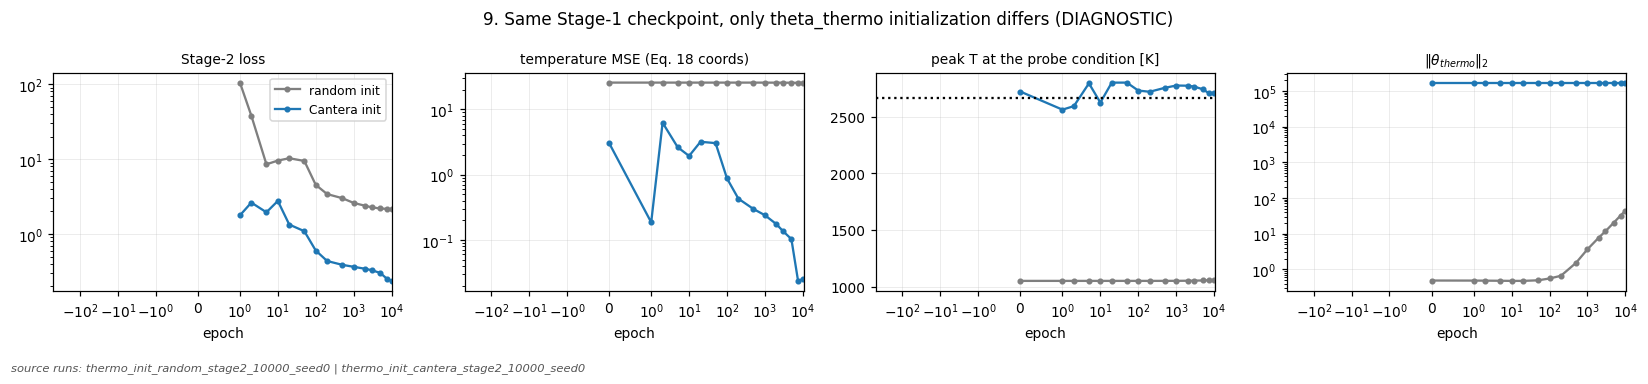

,stage2_loss,temperature_MSE,peak_T_K,ignites,thermo_linear_norm,theta_thermo relative change over 10k
random init,2.1272,25.5102,1058.0,False,43.9749,8.9702e+01
Cantera init,0.2366,0.0252,2714.1,True,171227.0,2.3361e-06


In [23]:
pr_r = probe_history(A["random10k"]["run_dir"])
pr_c = probe_history(A["cantera10k"]["run_dir"])
panels = [("stage2_loss", "Stage-2 loss", True),
          ("temperature_MSE", "temperature MSE (Eq. 18 coords)", True),
          ("peak_T_K", "peak T at the probe condition [K]", False),
          ("thermo_linear_norm", r"$\|\theta_{thermo}\|_2$", True)]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for j, (col, title, logy) in enumerate(panels):
    ax[j].plot(pr_r["epoch"], pr_r[col], "o-", ms=3, color="#7f7f7f", label="random init")
    ax[j].plot(pr_c["epoch"], pr_c[col], "o-", ms=3, color="#1f77b4", label="Cantera init")
    if col == "peak_T_K":
        ax[j].axhline(base["training"]["reference_peak_T_K"], color="k", ls=":",
                      label="reference peak")
    if logy: ax[j].set_yscale("log")
    ax[j].set_xscale("symlog", linthresh=1); ax[j].set_xlabel("epoch"); ax[j].set_title(title, fontsize=9)
ax[0].legend(fontsize=8)
fig.suptitle("9. Same Stage-1 checkpoint, only theta_thermo initialization differs (DIAGNOSTIC)", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k", "cantera10k")
fig.tight_layout(); plt.show()

cmp10k = pd.DataFrame({
    "random init": pr_r.set_index("epoch")[["stage2_loss","temperature_MSE","peak_T_K","ignites","thermo_linear_norm"]].iloc[-1],
    "Cantera init": pr_c.set_index("epoch")[["stage2_loss","temperature_MSE","peak_T_K","ignites","thermo_linear_norm"]].iloc[-1],
}).T
cmp10k["theta_thermo relative change over 10k"] = [
    abs(pr_r["thermo_linear_norm"].iloc[-1] - pr_r["thermo_linear_norm"].iloc[0]) / pr_r["thermo_linear_norm"].iloc[0],
    abs(pr_c["thermo_linear_norm"].iloc[-1] - pr_c["thermo_linear_norm"].iloc[0]) / pr_c["thermo_linear_norm"].iloc[0]]
cmp10k

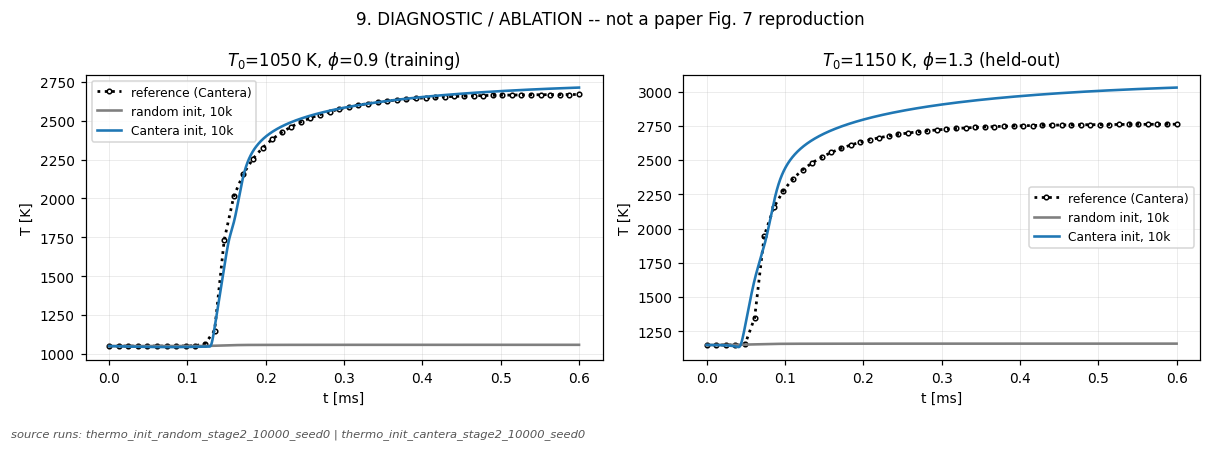

In [24]:
# Fig. 7-style T(t) for both final checkpoints (DIAGNOSTIC, not a Fig. 7 reproduction).
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for c, (T0, phi, role) in enumerate(CONDS):
    ref = reference(T0, phi)
    ax[c].plot(t * 1e3, ref[:, -1], "ko:", ms=3, mfc="none", lw=1.8, label="reference (Cantera)")
    for key, col, lab in (("random10k", "#7f7f7f", "random init, 10k"),
                          ("cantera10k", "#1f77b4", "Cantera init, 10k")):
        ax[c].plot(T_DENSE * 1e3, integrate_arm(A[key], T0, phi, T_DENSE)[:, -1],
                   "-", color=col, lw=1.7, label=lab)
    ax[c].set_title(f"$T_0$={T0:.0f} K, $\\phi$={phi:g} ({role})")
    ax[c].set_xlabel("t [ms]"); ax[c].set_ylabel("T [K]"); ax[c].legend(fontsize=8)
fig.suptitle("9. DIAGNOSTIC / ABLATION -- not a paper Fig. 7 reproduction", fontsize=11)
fig.tight_layout(); fig_source(fig, "random10k", "cantera10k")
fig.tight_layout(); plt.show()

**Observations, from the artifacts above.**

* The **random** arm reproduces the original non-igniting failure: `ignites = False` at
  every probe epoch through 10 000, peak T essentially unchanged.
* The **Cantera** arm is in an ignition-capable regime from **epoch 0**, before any
  optimizer step, and stays there.
* The Cantera arm's Stage-2 loss and temperature MSE end roughly an order of magnitude
  below the random arm's.
* The Cantera arm's `‖θ_thermo‖` changes by a **relative** amount of order 10⁻⁵ over
  10 000 epochs: the optimizer essentially never moves the coefficients away from their
  initial magnitude. The random arm grows its norm by ~90× and still ends ~4 orders of
  magnitude too small.

This says the *initialization* decides which regime Stage-2 optimization lands in. It does
**not** say the paper's authors initialized this way, nor that Cantera structure is
required — §12 tests exactly that.

---
# 10. Eq. 14 representation / normalization audit

The magnitude question only makes sense relative to a **representation**. There are two
self-consistent ways to write Eq. 14.

### A. Physical coordinates

$$\frac{dT}{dt} = \sum_k c_k \frac{dY_k}{dt}, \qquad c_k = -\frac{h_k}{c_p}\ \ [\mathrm{K}]$$

Here `dY_k/dt` is in s⁻¹ and `dT/dt` in K/s, so `c_k` must carry the full heat-release
scale — O(10³–10⁵) K for this mechanism (§7).

### B. Min–max-normalized state coordinates

If the states themselves were carried in Eq. 18's normalized coordinates,

$$\hat Y_k = \frac{Y_k - Y_{k,\min}}{R_{Y_k}}, \qquad \hat T = \frac{T - T_{\min}}{R_T}$$

then differentiating in time (the ranges are constants) gives

$$\frac{d\hat T}{dt} = \frac{1}{R_T}\frac{dT}{dt}
 = \frac{1}{R_T}\sum_k c_k \frac{dY_k}{dt}
 = \sum_k \underbrace{\left[c_k \frac{R_{Y_k}}{R_T}\right]}_{\hat c_k} \frac{d\hat Y_k}{dt}$$

so the coefficient a network would have to learn is

$$\boxed{\hat c_k = c_k \, \frac{R_{Y_k}}{R_T}}$$

which is a **completely different numerical scale** from `c_k`. The table below computes
both from the repository's actual normalization ranges.

In [25]:
R_Y, R_T = (u_max - u_min)[:m], float((u_max - u_min)[-1])
scaling = pd.DataFrame({
    "R_Y (mass-fraction range)": R_Y,
    "physical c_k = -h_k/cp [K]": c_phys,
    "normalized-coordinate c_hat_k = c_k R_Y/R_T": c_phys * R_Y / R_T,
}, index=species)
print(f"R_T = {R_T:.2f} K   (train-only min-max range of the temperature channel)")
print(f"||c_phys|| = {np.linalg.norm(c_phys):.1f}      "
      f"||c_hat|| = {np.linalg.norm(c_phys * R_Y / R_T):.4f}")
print(f"default nn.Linear init bound = +-1/sqrt(m) = +-{1/np.sqrt(m):.4f}  -> ||w_init|| "
      f"= {np.linalg.norm(w_init):.4f}")
scaling

R_T = 1831.07 K   (train-only min-max range of the temperature channel)
||c_phys|| = 171227.4      ||c_hat|| = 1.3344
default nn.Linear init bound = +-1/sqrt(m) = +-0.3333  -> ||w_init|| = 0.4848


,R_Y (mass-fraction range),physical c_k = -h_k/cp [K],normalized-coordinate c_hat_k = c_k R_Y/R_T
H2,4.2093e-02,-8093.1686,-1.8605e-01
H,6.9644e-03,-170340.8934,-6.4789e-01
O,1.8978e-02,-12176.9974,-1.2621e-01
O2,2.2837e-01,-561.7267,-7.0059e-02
OH,2.1441e-02,-2670.9467,-3.1275e-02
H2O,2.3982e-01,8719.9185,1.1421e+00
HO2,1.7038e-04,-990.8854,-9.2200e-05
H2O2,1.0786e-05,2050.0424,1.2076e-05
N2,2.1257e-02,-606.4103,-7.0399e-03


In [26]:
# Which representation does the CURRENT code actually use? Read it, do not assume.
import inspect
from chemkan import dynamics as _dyn, model as _mdl
src_dyn = inspect.getsource(_dyn.ChemKANDynamics.forward)
src_thermo = inspect.getsource(_mdl.ThermodynamicSuperstructure.forward)
print(src_dyn); print(src_thermo)

forward_path = pd.DataFrame([
 ["solver state representation", "PHYSICAL [Y, T]",
  "ChemKANDynamics.forward receives u_physical and the integrator advances it"],
 ["input normalization", "applied to a COPY only",
  "u_model = input_normalizer.normalize(u_physical); the integrated state is untouched"],
 ["kinetic output representation", "PHYSICAL dY/dt [1/s]",
  "the returned derivative is fed straight back to the solver in physical units"],
 ["thermo.linear input", "PHYSICAL dY/dt",
  "ThermodynamicSuperstructure.forward(u, dYdt) -> self.linear(dYdt)"],
 ["thermo.correction input", "NORMALIZED full state u_model",
  "self.correction(u), where u is the scaled copy handed to the model"],
 ["returned RHS representation", "PHYSICAL d[Y,T]/dt",
  "no de-normalization step exists anywhere on the return path"],
 ["time units", "SECONDS", "t comes from the dataset grid, 0 to 6e-4 s"],
], columns=["forward-path element", "representation", "evidence in code"])
forward_path

    def forward(self, t: torch.Tensor, u_physical: torch.Tensor) -> torch.Tensor:
        # (B, m+1) physical -> (B, m+1) physical derivative
        u_model = (u_physical if self.input_normalizer is None
                   else self.input_normalizer.normalize(u_physical))
        return self.model(u_model)

    def forward(self, u: torch.Tensor, dYdt: torch.Tensor) -> torch.Tensor:
        # u: (B, m+1), dYdt: (B, m) -> dT/dt: (B, 1)
        return self.linear(dYdt) + self.correction(u)



,forward-path element,representation,evidence in code
0,solver state representation,"PHYSICAL [Y, T]",ChemKANDynamics.forward receives u_physical an...
1,input normalization,applied to a COPY only,u_model = input_normalizer.normalize(u_physica...
2,kinetic output representation,PHYSICAL dY/dt [1/s],the returned derivative is fed straight back t...
3,thermo.linear input,PHYSICAL dY/dt,"ThermodynamicSuperstructure.forward(u, dYdt) -..."
4,thermo.correction input,NORMALIZED full state u_model,"self.correction(u), where u is the scaled copy..."
5,returned RHS representation,"PHYSICAL d[Y,T]/dt",no de-normalization step exists anywhere on th...
6,time units,SECONDS,"t comes from the dataset grid, 0 to 6e-4 s"


### What the code proves, and only that

The integrated state, the kinetic output and the returned right-hand side are all
**physical**; the min–max normalizer is applied only to the *copy* of the state handed to
the KAN (to keep the internal `tanh` out of saturation), and there is no de-normalization
anywhere on the return path. Therefore:

> **Our current implementation realizes CASE A: physical `dY/dt` → physical `dT/dt`.**
> The nine `θ_thermo` scalars must therefore carry the full O(10³–10⁵) K heat-release
> scale, while PyTorch's default `nn.Linear` initialization places them at O(10⁻¹).

The paper's Eq. 14 is written in physical thermochemical variables and its own motivation
("scaling factors defined by the enthalpy `h` and specific heat `c_p`") describes physical
`-h_k/c_p`. That is consistent with Case A. But the paper documents **neither** an
implementation-level derivative scaling **nor** an initialization scheme for `θ_thermo`.

* **NOT ESTABLISHED:** that the authors used normalized derivatives.
* **NOT ESTABLISHED:** that the authors used physical derivatives with a special init.
* **ESTABLISHED (about this repo only):** in Case A, a default-initialized `θ_thermo` starts
  ~5–6 orders of magnitude below the scale Eq. 14 needs.

No claim is made here about how many epochs Adam "would" need to cross that gap; the
optimizer's reachable set is not bounded by any simple argument, and §12 tests the
question empirically instead.

---
# 11. The historical Cantera-init provenance bug

**Category: DIAGNOSTIC IMPLEMENTATION BUG.** This is a defect in *our* diagnostic
tooling. It is not a paper issue and it does not affect any paper-reproduction result.

The successful 10k Cantera run was launched intending the Fig. 7 training condition
`T = 1050 K, Φ = 0.9`. The historical code path:

* passed `--thermo-init-temperature` to Cantera correctly (**1050 K**), but
* took the composition from `data["species_TBm"][0, 0]` — the **first training
  condition** — and **ignored `--thermo-init-phi` entirely** in the calculation, while
  still recording it in `config.json`.

Because H₂/air mass fractions depend on **Φ only** (not on `T₀`), "first training
condition" means **Φ = 0.5**. So the effective historical reference state was
**T = 1050 K with the Φ = 0.5 composition**. The cell below verifies this against the
stored vector rather than asserting it.

In [27]:
hist = np.array(A["cantera10k"]["config"]["thermo_init"]["coefficients"])
hist_meta = A["cantera10k"]["config"]["thermo_init"]

def coeffs_at(T0, phi):
    Y = resolve_training_ic(npz["train_ics"], npz["train_states"], T0, phi, species_dim=m)
    c, _ = cantera_coefficients(T0, Y, species=species, mech=MECH)
    return c

cand = {"1050 K / phi 0.9 (INTENDED)": coeffs_at(1050.0, 0.9),
        "1050 K / phi 0.5 (ACTUAL)":   coeffs_at(1050.0, 0.5)}
rows = []
for name, c in cand.items():
    c32 = c.astype(np.float32)                       # the loader stores float32
    rows.append(dict(candidate=name, norm=float(np.linalg.norm(c)),
                     max_abs_diff_vs_stored=float(np.abs(c32 - hist.astype(np.float32)).max()),
                     reproduces_stored=bool(np.allclose(c32, hist.astype(np.float32), atol=0, rtol=0))))
print(f"recorded config: reference_T_K={hist_meta['reference_T_K']}, "
      f"reference_phi={hist_meta['reference_phi']}  (phi was RECORDED but not USED)")
print(f"stored historical coefficient norm = {np.linalg.norm(hist):.4f}\n")
pd.DataFrame(rows).set_index("candidate")

recorded config: reference_T_K=1050.0, reference_phi=0.9  (phi was RECORDED but not USED)
stored historical coefficient norm = 171227.4433



,norm,max_abs_diff_vs_stored,reproduces_stored
candidate,,,
1050 K / phi 0.9 (INTENDED),153535.3804,17600.4531,False
1050 K / phi 0.5 (ACTUAL),171227.4433,0.0000,True


In [28]:
# Corrected semantics: --thermo-init-temperature / --thermo-init-phi now resolve an EXACT
# training initial condition, and a non-training request fails loudly instead of silently
# picking a neighbour.
print("resolver docstring:\n ", (resolve_training_ic.__doc__ or "").strip().split("\n")[0], "\n")
for T0, phi in ((1050.0, 0.9), (1050.0, 0.5)):
    Y = resolve_training_ic(npz["train_ics"], npz["train_states"], T0, phi, species_dim=m)
    print(f"  ({T0:.0f} K, phi={phi}) -> resolved composition, ||c|| = "
          f"{np.linalg.norm(coeffs_at(T0, phi)):.4f}")
try:
    resolve_training_ic(npz["train_ics"], npz["train_states"], 1234.0, 0.77, species_dim=m)
    print("  (1234 K, phi=0.77) -> UNEXPECTEDLY SUCCEEDED")
except SystemExit as e:
    print(f"  (1234 K, phi=0.77) -> refused: {str(e).splitlines()[0]}")

# Independent confirmation: the 500-epoch comparator was launched with the CORRECTED flags
# at 1050/0.5, so its probe history must reproduce the historical 10k run's first rows.
p5, p10 = probe_history(A["cantera500"]["run_dir"]), probe_history(A["cantera10k"]["run_dir"])
common = sorted(set(p5["epoch"]) & set(p10["epoch"]))
cols = ["stage2_loss", "temperature_MSE", "peak_T_K", "thermo_linear_norm"]
a = p5.set_index("epoch").loc[common, cols].to_numpy(float)
b = p10.set_index("epoch").loc[common, cols].to_numpy(float)
print(f"\ncantera500 (corrected flags, phi=0.5) vs cantera10k (buggy path) over epochs {common}:")
print(f"  identical to within rtol=1e-12: {np.allclose(a, b, rtol=1e-12, equal_nan=True)}")
print("  -> the corrected 1050/0.5 request reproduces the historical run exactly,")
print("     confirming phi=0.5 was the composition actually used.")

resolver docstring:
  Initial species composition of the EXACT training condition ``(temperature, phi)``. 

  (1050 K, phi=0.9) -> resolved composition, ||c|| = 153535.3804
  (1050 K, phi=0.5) -> resolved composition, ||c|| = 171227.4433
  (1234 K, phi=0.77) -> refused: reference state (T0=1234 K, phi=0.77) is not an exact training initial condition (0 matches). Pass a real training IC. First few available: (950,0.5), (950,0.7), (950,0.9), (950,1.1), (950,1.3), (950,1.5), (1000,0.5), (1000,0.7) ...

cantera500 (corrected flags, phi=0.5) vs cantera10k (buggy path) over epochs [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]:
  identical to within rtol=1e-12: True
  -> the corrected 1050/0.5 request reproduces the historical run exactly,
     confirming phi=0.5 was the composition actually used.


**Consequence for interpretation.** The scaled-random controls of §12 target the norm of
the **actually successful** vector (`T = 1050 K, Φ = 0.5`), not the intended-but-unused
`Φ = 0.9` vector, because the control must match what demonstrably worked. `1050 K / Φ 0.9`
is retained as the **paper-anchored diagnostic reference** (it is the Fig. 7 training
condition) — it was never an ignition threshold, and neither choice is paper methodology.

---
# 12. Is magnitude alone sufficient? Scale vs direction at **500 epochs**

`thermo.linear` is a 9-dimensional vector with a **magnitude** `‖w‖` and a **direction**
`w/‖w‖`. The Cantera vector supplies both a large magnitude *and* a physically meaningful
direction (signs and relative species ratios). These can be separated:

* **`--thermo-init-scale-factor`** multiplies the default random draw by a constant —
  magnitude changes, **direction is untouched**.
* **`--thermo-match-cantera-norm`** rescales the random draw to exactly the Cantera vector's
  L2 norm — same magnitude as the physical vector, **random direction**.
* **`--thermo-linear-init-seed k`** redraws **only** the `thermo.linear` vector (its
  direction) from an isolated RNG. **The global training seed stays 0** for every arm, so
  data order, the Stage-1 state and every other initialization are unchanged.

"Direction seed" therefore means: *which random direction in 9-D coefficient space*,
nothing else.

> **Budget discipline.** Every loss quoted in this section is at **epoch 500**, including
> the default-random control's — reading the epoch-500 row out of its longer probe history
> rather than comparing a 500-epoch arm against a 10 000-epoch number. §15 repeats the whole
> comparison at 10 000 epochs for both sides.

> **`thermo_linear_init_seed` ("direction seed") is NOT the training seed.** Two separate
> seeds are in play and conflating them would break the controlled design:
>
> | seed | set by | controls |
> |---|---|---|
> | **global training seed** | `--seed 0` | *everything*: kinetic-core initialization, `thermo.correction` initialization, data order, and the default `thermo.linear` draw. **Fixed at 0 for every arm in this notebook.** |
> | **direction seed** | `--thermo-linear-init-seed k` | *only* the 9-component direction of `thermo.linear`, drawn from an isolated `torch.Generator` that consumes no numbers from the global stream. |
>
> So `dir0`, `dir1` and `dir2` are the **same model, same data order, same kinetic core, same
> correction network**, differing only in which random direction the nine Eq. 14 coefficients
> point in — after which all three are rescaled to the *same* L2 norm. That is what makes
> "direction matters independently of magnitude" a controlled claim rather than a seed effect.

**The claim above is verifiable — the next two cells prove it from the initialization itself, not from any saved run.**

In [29]:
# PROOF, not assertion: rebuild the arms exactly as train_hydrogen.py does and compare
# EVERY parameter tensor. Nothing here is loaded from a run; it is the initialization itself.
from chemkan.model import ChemKAN as _ChemKAN

def _build_arm(dir_seed, arch=None):
    """Reproduce train_hydrogen.py's initialization order for one direction seed."""
    arch = arch or dict(hidden_dim=3, num_basis=5, n_mu=3, use_base_act=False)
    torch.manual_seed(0)                        # GLOBAL seed - identical for every arm
    mdl = _ChemKAN(species_dim=m, **arch)       # whole model built here, global RNG consumed
    w = mdl.thermo.linear.weight
    if dir_seed != 0:                           # seed 0 => no redraw whatsoever
        g = torch.Generator(device="cpu").manual_seed(int(dir_seed))   # ISOLATED generator:
        bound = 1.0 / np.sqrt(w.shape[-1])      # never advances the global RNG stream
        with torch.no_grad():
            w.copy_(torch.empty(w.shape).uniform_(-bound, bound, generator=g))
    return mdl

_arms = {k: _build_arm(k) for k in (0, 1, 2)}
rows, tot, same = [], 0, 0
for n, p0 in _arms[0].named_parameters():
    p1, p2 = dict(_arms[1].named_parameters())[n], dict(_arms[2].named_parameters())[n]
    eq1, eq2 = torch.equal(p0, p1), torch.equal(p0, p2)
    tot += p0.numel(); same += p0.numel() if (eq1 and eq2) else 0
    rows.append(dict(parameter=n, numel=p0.numel(),
                     **{"dir0 vs dir1": "IDENTICAL" if eq1 else "DIFFERS",
                        "dir0 vs dir2": "IDENTICAL" if eq2 else "DIFFERS"}))
display(pd.DataFrame(rows).set_index("parameter"))
print(f"{same} of {tot} parameters are bit-identical across the three arms; "
      f"{tot - same} differ — exactly thermo.linear.weight.")
assert tot - same == m, "the direction seed touched something other than thermo.linear"

,numel,dir0 vs dir1,dir0 vs dir2
parameter,,,
kinetic.add.edges.w_rbf,150,IDENTICAL,IDENTICAL
kinetic.lean.edges.w_rbf,135,IDENTICAL,IDENTICAL
thermo.linear.weight,9,DIFFERS,DIFFERS
thermo.correction.edges.w_rbf,50,IDENTICAL,IDENTICAL


335 of 344 parameters are bit-identical across the three arms; 9 differ — exactly thermo.linear.weight.


In [30]:
# Are seeds 0/1/2 really three DIFFERENT directions, or could two of them be near-duplicates?
_raw = {k: _arms[k].thermo.linear.weight.detach().numpy().ravel() for k in (0, 1, 2)}
_unit = {k: v / np.linalg.norm(v) for k, v in _raw.items()}
_cos = pd.DataFrame([[float(_unit[a] @ _unit[b]) for b in (0, 1, 2)] for a in (0, 1, 2)],
                    index=[f"dir{k}" for k in (0, 1, 2)],
                    columns=[f"dir{k}" for k in (0, 1, 2)])
print("pairwise cosine between the three initial directions (1 = same, 0 = orthogonal):")
display(_cos.round(4))

# Reference: what do INDEPENDENT draws from the same distribution look like in 9-D?
_g = torch.Generator().manual_seed(12345)
_b = 1.0 / np.sqrt(m)
_s = torch.empty(4000, 2, m).uniform_(-_b, _b, generator=_g).numpy()
_s /= np.linalg.norm(_s, axis=-1, keepdims=True)
_null = np.abs((_s[:, 0] * _s[:, 1]).sum(-1))
_obs = [abs(_cos.iloc[i, j]) for i in range(3) for j in range(i + 1, 3)]
print(f"|cos| for 4000 independent random pairs in {m}-D: mean {_null.mean():.3f}, "
      f"95th pct {np.percentile(_null, 95):.3f}")
print(f"our three pairs:  {', '.join(f'{c:.3f}' for c in _obs)}")
print("-> all within the ordinary spread of independent draws: seeds 0/1/2 give three genuinely")
print("   distinct directions, and none is an outlier or a near-duplicate of another.")
print(f"\nSign agreement with the physical Cantera vector (out of {m}):")
for k in (0, 1, 2):
    print(f"   dir{k}: {int((np.sign(_raw[k]) == np.sign(c_phys)).sum())}/{m}")

pairwise cosine between the three initial directions (1 = same, 0 = orthogonal):


,dir0,dir1,dir2
dir0,1.0000,-0.1278,-0.3700
dir1,-0.1278,1.0000,-0.2901
dir2,-0.3700,-0.2901,1.0000


|cos| for 4000 independent random pairs in 9-D: mean 0.274, 95th pct 0.641
our three pairs:  0.128, 0.370, 0.290
-> all within the ordinary spread of independent draws: seeds 0/1/2 give three genuinely
   distinct directions, and none is an outlier or a near-duplicate of another.

Sign agreement with the physical Cantera vector (out of 9):
   dir0: 1/9
   dir1: 6/9
   dir2: 4/9


### "If nine numbers change the answer this much, is the model stable?"

**No — and that is the point of the experiment, not a flaw in it.** The right conclusion is
that the norm-matched arms are **probes of the optimization landscape, not candidate models.**

Three facts make this precise:

1. **At the DEFAULT initialization the model is highly reproducible.** It fails, but it fails
   *consistently*: test trajectory MSE 3.156 (N=5/base-OFF) vs 3.146 (N=4/base-ON) — 0.3 %
   apart across a different architecture and a separately trained Stage-1 core. The
   reproduction failure is a stable, repeatable property.
2. **The instability appears only once we impose a magnitude the optimizer cannot revise.**
   At `‖θ‖ ≈ 1.7e5`, Adam can move each coefficient by at most `lr × steps = 20`, a *relative*
   change of ~1e-4. Those nine numbers are therefore effectively **hyperparameters, not
   learned parameters** — fixed at epoch 0 and carried unchanged to epoch 10 000.
3. **Whatever is fixed at epoch 0 decides the outcome.** The epoch-0 probe shows `dir1`
   already at 2447 K against a 2670 K reference *before a single optimizer step*, while `dir0`
   sits at 1050 K. Training then refines within the basin the initialization chose; it does
   not escape it.

So a model whose behaviour is set by nine frozen scalars is **not** a well-posed trained
model, and none of these arms should be presented as a working ChemKAN. What they establish
is narrower and more useful:

> Under the current physical-rate Eq. 14 formulation, Stage-2 optimization cannot recover the
> thermodynamic mapping on its own. It can only refine a mapping it is given. That is a
> statement about the **formulation**, and it is exactly why the next test is the
> paper-explicit training method (FSA) rather than a better initialization.

**How `dir1` should and should not be described.** It is **one favourable draw out of three**,
and it looks good largely because it *started* good (6/9 signs matching the physical vector by
chance). It is evidence that the physical direction is not *uniquely* necessary. It is **not**
evidence that "a random direction works", and it must never be reported as a reproduction
result.

In [31]:
def init_meta(key, at_epoch=500):
    ti = A[key]["config"]["thermo_init"]
    pr = probe_history(A[key]["run_dir"])
    row = pr.loc[pr["epoch"] == at_epoch]
    return dict(
        arm=key,
        thermo_init=ti.get("thermo_init"),
        dir_seed=ti.get("thermo_linear_init_seed"),
        initial_norm=float(pr["thermo_linear_norm"].iloc[0]),
        scale_factor=ti.get("effective_scale_factor"),
        sign_match_vs_cantera=ti.get("sign_match_vs_cantera"),
        norm_at_500=float(row["thermo_linear_norm"].iloc[0]) if len(row) else np.nan,
        loss_at_500=float(row["stage2_loss"].iloc[0]) if len(row) else np.nan,
    )

ABL = ["random10k", "x1e4_dir0", "x1e5_dir0", "nm_dir0", "nm_dir1", "nm_dir2", "cantera500"]
ablation = pd.DataFrame([init_meta(k) for k in ABL if k in A]).set_index("arm")
print(f"Cantera reference norm @ {REF_T:.0f} K / phi {REF_PHI} = {np.linalg.norm(c_phys):.4f}")
print("All losses below are at EPOCH 500, including the default-random control.")
ablation

Cantera reference norm @ 1050 K / phi 0.5 = 171227.4433
All losses below are at EPOCH 500, including the default-random control.


,thermo_init,dir_seed,initial_norm,scale_factor,sign_match_vs_cantera,norm_at_500,loss_at_500
arm,,,,,,,
random10k,random,NaN,0.4848,NaN,NaN,1.5144,3.0104
x1e4_dir0,scaled-random,0.0,4848.2710,10000.0000,1/9,4849.1820,3.8230
x1e5_dir0,scaled-random,0.0,48482.7100,100000.0000,1/9,48484.4200,4.9974
nm_dir0,scaled-random,0.0,171227.4000,353172.1997,1/9,171227.5000,5.0617
nm_dir1,scaled-random,1.0,171227.5000,339849.2806,6/9,171227.4000,0.3979
nm_dir2,scaled-random,2.0,171227.4000,480018.3606,4/9,171227.4000,4.4417
cantera500,cantera,NaN,171227.4000,NaN,NaN,171227.4000,0.3877


In [32]:
print("=" * 78)
print("ONE-DIRECTION SCALE RESPONSE  (direction seed 0 throughout; magnitude is the only")
print("variable; all quantities at epoch 500). Valid for THIS random direction only.")
print("=" * 78)
scale_resp = ablation.loc[[k for k in ("random10k", "x1e4_dir0", "x1e5_dir0", "nm_dir0")
                           if k in ablation.index],
                          ["initial_norm", "scale_factor", "norm_at_500", "loss_at_500"]].copy()
scale_resp["x vs default"] = scale_resp["initial_norm"] / scale_resp.loc["random10k", "initial_norm"]
display(scale_resp)

print()
print("=" * 78)
print("EQUAL-NORM STRUCTURE COMPARISON  (all four carry the same L2 norm; only the")
print("DIRECTION differs -- Cantera's physical direction vs three random ones; epoch 500).")
print("=" * 78)
struct = ablation.loc[[k for k in ("cantera500", "nm_dir0", "nm_dir1", "nm_dir2")
                       if k in ablation.index],
                      ["dir_seed", "initial_norm", "sign_match_vs_cantera", "norm_at_500",
                       "loss_at_500"]].copy()
struct["norm / Cantera norm"] = struct["initial_norm"] / np.linalg.norm(c_phys)
display(struct)
assert np.allclose(struct["norm / Cantera norm"], 1.0, atol=1e-5), \
    "the equal-norm arms are not actually equal-norm"
print("verified: all equal-norm arms match the Cantera L2 norm to within 1e-5 relative.")

ONE-DIRECTION SCALE RESPONSE  (direction seed 0 throughout; magnitude is the only
variable; all quantities at epoch 500). Valid for THIS random direction only.


,initial_norm,scale_factor,norm_at_500,loss_at_500,x vs default
arm,,,,,
random10k,0.4848,NaN,1.5144,3.0104,1.0000
x1e4_dir0,4848.2710,10000.0000,4849.1820,3.8230,10000.0000
x1e5_dir0,48482.7100,100000.0000,48484.4200,4.9974,100000.0000
nm_dir0,171227.4000,353172.1997,171227.5000,5.0617,353172.0896



EQUAL-NORM STRUCTURE COMPARISON  (all four carry the same L2 norm; only the
DIRECTION differs -- Cantera's physical direction vs three random ones; epoch 500).


,dir_seed,initial_norm,sign_match_vs_cantera,norm_at_500,loss_at_500,norm / Cantera norm
arm,,,,,,
cantera500,NaN,171227.4,NaN,171227.4,0.3877,1.0
nm_dir0,0.0,171227.4,1/9,171227.5,5.0617,1.0
nm_dir1,1.0,171227.5,6/9,171227.4,0.3979,1.0
nm_dir2,2.0,171227.4,4/9,171227.4,4.4417,1.0


verified: all equal-norm arms match the Cantera L2 norm to within 1e-5 relative.


---
# 13. Probe histories and the operational ignition-flag classification

Every arm's `stage2_probe.csv` records, at chosen epochs and under `torch.no_grad()`, the
Stage-2 loss, the temperature MSE, the peak temperature at the probe condition, an
**operational ignition flag**, the ignition delay and `‖θ_thermo‖`.

> **What the classification is and is not.** The flag is `True` only when the repository's
> operational guard fires — a total temperature rise of at least 100 K — which is what makes
> `argmax dT/dt` a meaningful quantity at all (§19). It is emphatically **not** a statement
> that the trajectory is physically correct. An arm can carry
> `operational ignition = True` while having the wrong induction period, the wrong
> temperature shape, the wrong peak and a bad full-trajectory MSE — §15–§17 show exactly
> that happening. The label below is therefore called an **operational ignition-flag
> history**, never "ignition quality".

The class set was **pre-registered before the runs** (see
`results/reproduction/chemkan/hydrogen/EXPERIMENTS.md` §7) and is applied to the **whole**
history, never to the final epoch alone.

In [33]:
def classify(pr):
    """Pre-registered OPERATIONAL ignition-flag class, from the FULL probe history.

    Describes when the >=100 K guard fired, not whether the trajectory is physical.
    """
    if pr is None or len(pr) == 0:
        return "no_probe_history"
    if not np.isfinite(pr["peak_T_K"].to_numpy(float)).all():
        return "unstable_at_initialization"
    ig = pr["ignites"].to_numpy(bool)
    if not ig.any():
        return "never_ignites"
    if ig.all():
        return "ignites_initially_and_persists"
    first_true = int(np.argmax(ig))
    if ig[first_true:].all():
        return ("ignition_emerges_and_persists" if first_true > 0
                else "ignites_initially_and_persists")
    if ig[0] and not ig[-3:].any():
        return "ignites_then_loses_ignition"
    return "intermittent"

PROBE_ARMS = [k for k, _, _ in ARMS] if False else [
    k for k in ("random10k", "cantera10k", "cantera500", "x1e4_dir0", "x1e5_dir0",
                "nm_dir0", "nm_dir1", "nm_dir2", "x1e5_dir0_10k", "nm_dir0_10k",
                "nm_dir1_10k", "nm_dir2_10k") if k in A]
CLASS = {}
for k in PROBE_ARMS:
    pr = probe_history(A[k]["run_dir"])
    CLASS[k] = classify(pr)
budget = {k: (A[k]["config"].get("epochs") or {}).get("stage2") for k in PROBE_ARMS}
pd.DataFrame({"stage2_epochs": budget, "operational_ignition_flag_history": CLASS})

,stage2_epochs,operational_ignition_flag_history
random10k,10000,never_ignites
cantera10k,10000,ignites_initially_and_persists
cantera500,500,ignites_initially_and_persists
x1e4_dir0,500,never_ignites
x1e5_dir0,500,ignition_emerges_and_persists
nm_dir0,500,ignition_emerges_and_persists
nm_dir1,500,intermittent
nm_dir2,500,intermittent
x1e5_dir0_10k,10000,ignition_emerges_and_persists
nm_dir0_10k,10000,ignition_emerges_and_persists


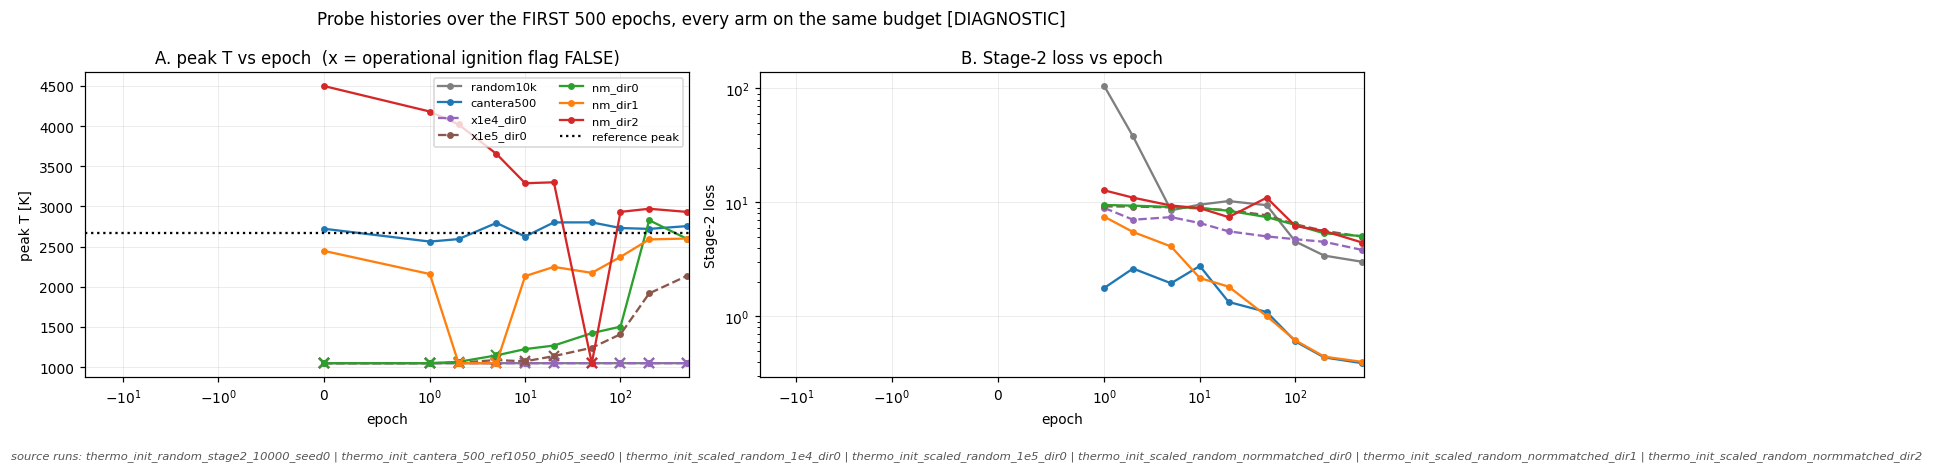

In [34]:
# 500-epoch probe histories (the long-budget view is section 13B, after section 18
# defines the 10k arm registry).
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
COL500 = {"random10k": "#7f7f7f", "cantera500": "#1f77b4", "x1e4_dir0": "#9467bd",
          "x1e5_dir0": "#8c564b", "nm_dir0": "#2ca02c", "nm_dir1": "#ff7f0e",
          "nm_dir2": "#d62728"}
for k, col in COL500.items():
    pr = probe_history(A[k]["run_dir"])
    pr = pr[pr["epoch"] <= 500]                      # fair budget: 500 epochs for every arm
    ls = "--" if k in ("x1e4_dir0", "x1e5_dir0") else "-"
    ax[0].plot(pr["epoch"], pr["peak_T_K"], "o" + ls, ms=3.5, color=col, label=k)
    ni = pr[~pr["ignites"]]
    ax[0].plot(ni["epoch"], ni["peak_T_K"], "x", ms=7, color=col, mew=1.4)
    ax[1].plot(pr["epoch"], pr["stage2_loss"], "o" + ls, ms=3.5, color=col, label=k)
ax[0].axhline(float(reference(1050.0, 0.9)[:, -1].max()), color="k", ls=":", lw=1.5,
              label="reference peak")
ax[0].set_ylabel("peak T [K]")
ax[0].set_title("A. peak T vs epoch  (x = operational ignition flag FALSE)")
ax[1].set_yscale("log"); ax[1].set_ylabel("Stage-2 loss")
ax[1].set_title("B. Stage-2 loss vs epoch")
for a_ in ax:
    a_.set_xscale("symlog", linthresh=1); a_.set_xlabel("epoch")
ax[0].legend(fontsize=7.5, ncol=2)
fig.suptitle("Probe histories over the FIRST 500 epochs, every arm on the same budget "
             "[DIAGNOSTIC]", fontsize=11)
fig.tight_layout(); fig_source(fig, *[k for k in COL500])
fig.tight_layout(); plt.show()

**Why the full history matters.** Two arms would be misread from their final epoch
alone: `nm_dir1` raises the flag at epoch 0, **loses** it at epochs 2–5, then recovers;
`nm_dir2` carries it from the start but **drops out at epoch 50** before recovering. Both
are `intermittent`, not "ignites and persists". The `x` markers mark every probe epoch at
which the operational flag was false. Section 13B repeats this over the full 10 000-epoch
budget.

---
# 14. Temperature trajectories at 500 epochs — what the scalar losses hide

The comparison logic lives in
`chemkan/scripts/diagnostics/plot_thermo_initialization_comparison.py`; the notebook
imports its registry and styling rather than re-implementing it, and recomputes the curves
here so they are visible inline. These are the **500-epoch** checkpoints; §16 shows the
10 000-epoch counterparts.

> ## DIAGNOSTIC / ABLATION — **not** a paper Fig. 7 reproduction.

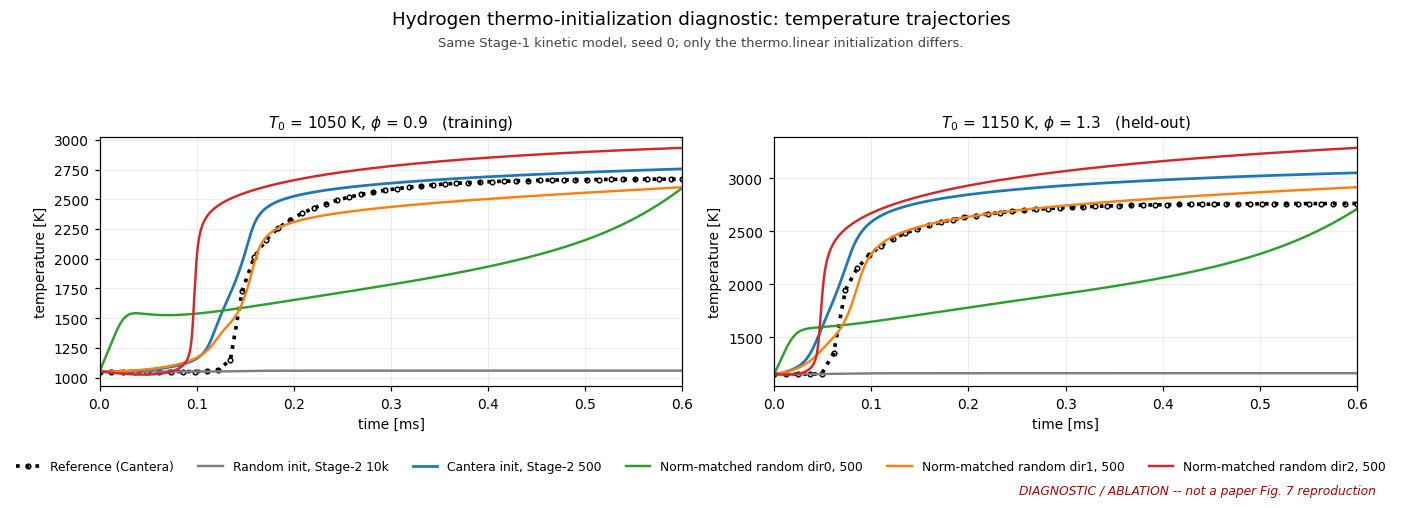

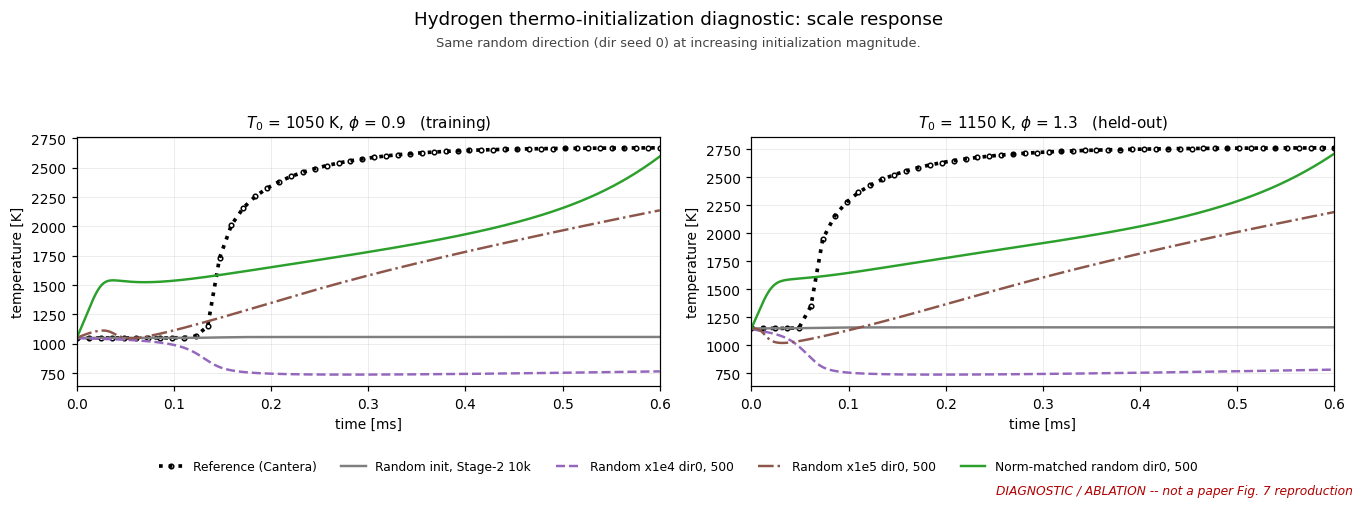

In [35]:
import matplotlib
_backend = matplotlib.get_backend()
import plot_thermo_initialization_comparison as PTIC   # the script forces the Agg backend
matplotlib.use(_backend)                               # restore the notebook's inline backend

def trajectory_panel(keys, title, subtitle):
    fig, axs = plt.subplots(1, 2, figsize=(12.4, 4.4))
    for ax_, (T0, phi, role) in zip(axs, CONDS):
        ref = reference(T0, phi)
        ax_.plot(t * 1e3, ref[:, -1], label="Reference (Cantera)", **PTIC.REF_STYLE)
        for key in keys:
            lab = next(l for k, _, l, _ in PTIC.RUNS if k == PTIC_KEY[key])
            ax_.plot(T_DENSE * 1e3, integrate_arm(A[key], T0, phi, T_DENSE)[:, -1],
                     label=lab, **PTIC.STYLE[PTIC_KEY[key]])
        ax_.set_title(f"$T_0$ = {T0:.0f} K, $\\phi$ = {phi:g}   ({role})", fontsize=10)
        ax_.set_xlabel("time [ms]"); ax_.set_ylabel("temperature [K]")
        ax_.set_xlim(0, t[-1] * 1e3)
    handles = axs[0].get_legend_handles_labels()
    fig.suptitle(title, fontsize=12, y=1.00)
    fig.text(0.5, 0.925, subtitle, ha="center", fontsize=8.5, color="#444444")
    fig.legend(*handles, fontsize=8, loc="lower center", ncol=min(len(keys) + 1, 6),
               frameon=False, bbox_to_anchor=(0.5, 0.02))
    fig.text(0.995, 0.0, "DIAGNOSTIC / ABLATION -- not a paper Fig. 7 reproduction",
             ha="right", fontsize=8, color="#b00000", style="italic")
    fig.tight_layout(rect=(0, 0.10, 1, 0.885)); plt.show()

# notebook arm key -> the script's registry key (identical here, kept explicit)
PTIC_KEY = {"random10k": "random10k", "cantera500": "cantera500", "nm_dir0": "nm_dir0",
            "nm_dir1": "nm_dir1", "nm_dir2": "nm_dir2",
            "x1e4_dir0": "x1e4_dir0", "x1e5_dir0": "x1e5_dir0"}

trajectory_panel(["random10k", "cantera500", "nm_dir0", "nm_dir1", "nm_dir2"],
                 "Hydrogen thermo-initialization diagnostic: temperature trajectories",
                 "Same Stage-1 kinetic model, seed 0; only the thermo.linear initialization differs.")
trajectory_panel(["random10k", "x1e4_dir0", "x1e5_dir0", "nm_dir0"],
                 "Hydrogen thermo-initialization diagnostic: scale response",
                 "Same random direction (dir seed 0) at increasing initialization magnitude.")

In [36]:
# Verify the qualitative shape claims FROM the computed curves rather than asserting them.
def shape_descriptors(key, T0, phi):
    """Descriptive shape measures on the dense grid. Not an ignition criterion."""
    Td = integrate_arm(A[key], T0, phi, T_DENSE)[:, -1]
    T0v = float(Td[0])
    above = np.flatnonzero(Td >= T0v + 100.0)
    return {
        "arm": key, "condition": ("training" if phi == 0.9 else "held-out"),
        "peak_T_K": float(Td.max()), "min_T_K": float(Td.min()), "final_T_K": float(Td[-1]),
        "cools_below_T0": bool(Td.min() < T0v - 1.0),
        "t_first_+100K_ms": (np.nan if above.size == 0 else float(T_DENSE[above[0]] * 1e3)),
        "t_max_dTdt_ms": (np.nan if ignition_delay(T_DENSE, Td) is None
                          else ignition_delay(T_DENSE, Td) * 1e3)}

shapes = pd.DataFrame([shape_descriptors(k, T0, phi)
                       for k in ("random10k", "cantera500", "nm_dir0", "nm_dir1", "nm_dir2",
                                 "x1e4_dir0", "x1e5_dir0") if k in A
                       for T0, phi, _ in CONDS])
def _ref_shape(T0, phi, role):
    Tr = reference(T0, phi)[:, -1]
    above = np.flatnonzero(Tr >= Tr[0] + 100.0)
    return {"arm": "REFERENCE", "condition": role,
            "peak_T_K": float(Tr.max()), "min_T_K": float(Tr.min()),
            "final_T_K": float(Tr[-1]), "cools_below_T0": False,
            "t_first_+100K_ms": (np.nan if above.size == 0 else float(t[above[0]] * 1e3)),
            "t_max_dTdt_ms": ignition_delay(t, Tr) * 1e3}

ref_shape = pd.DataFrame([_ref_shape(T0, phi, role) for T0, phi, role in CONDS])
shape_table = pd.concat([ref_shape, shapes]).set_index(["condition", "arm"]).sort_index()
shape_table

peak_T_K    min_T_K  final_T_K  cools_below_T0  t_first_+100K_ms  t_max_dTdt_ms
condition arm                                                                                         
held-out  REFERENCE   2761.5843  1150.0000  2761.5843           False            0.0612         0.0735
          cantera500  3051.1648  1150.0000  3051.1648           False            0.0287         0.0731
          nm_dir0     2710.4895  1150.0000  2710.4895           False            0.0050         0.0044
          nm_dir1     2915.6367  1150.0000  2915.6367           False            0.0331         0.0851
          nm_dir2     3286.8298  1146.2466  3286.8298            True            0.0408         0.0479
          random10k   1159.5980  1150.0000  1159.5808           False               NaN            NaN
          x1e4_dir0   1150.0000   737.5515   782.1311            True               NaN            NaN
          x1e5_dir0   2188.7161  1020.1498  2188.7161            True            0.1521         0.1782
training  REFERENCE   2669.7177  1050.0000  2669.7177           False            0.1469         0.1469
          cantera500  2755.7925  1049.4072  2755.7925           False            0.0980         0.1523
          nm_dir0     2596.3804  1050.0000  2596.3804           False            0.0052         0.0089
          nm_dir1     2601.0984  1049.2295  2601.0984           False            0.0957         0.1573
          nm_dir2     2932.4321  1024.3999  2932.4321            True            0.0902         0.0974
          random10k   1058.0077  1049.9999  1058.0011           False               NaN            NaN
          x1e4_dir0   1050.0000   737.0771   764.5999            True               NaN            NaN
          x1e5_dir0   2137.4087  1046.8030  2137.4087            True            0.1166         0.0000

**Verified from the curves above** (each claim maps to a column of the table):

* `random10k` — **flat**: never reaches `T₀ + 100 K`; no `t_max_dTdt`.
* `x1e4_dir0` — **cools and never recovers**: `cools_below_T0 = True`, `min_T` far below
  `T₀`, `final_T < T₀`, never ignites. Larger magnitude is not automatically better.
* `x1e5_dir0` — heats, but with the **wrong induction**: it ramps from the start rather
  than igniting after a delay.
* `nm_dir0` — **near-correct peak for the wrong temporal reason**: its peak error is the
  smallest of any arm, yet it crosses `T₀ + 100 K` almost immediately and its maximum
  `dT/dt` sits at the very start. A scalar peak or final-loss ranking would place it well;
  it has no ignition event at all.
* `nm_dir1` — **genuine induction followed by a sharp rise**. On the grid-consistent
  comparison of §15 its delay error is +15 % (training) and +35 % (held-out). It is a
  *nonphysical* direction (its sign pattern matches Cantera in only 6 of 9 components)
  that nevertheless behaves qualitatively like the physical one.
* `nm_dir2` — **early and excessive heating**: it dips slightly, then rises far too soon
  and overshoots the reference peak substantially.
* `cantera500` — genuine induction with the closest timing of any arm (+12 % / +16 %
  grid-consistent), but it **overshoots the held-out peak by ~290 K**.

---
# 15. Long-budget persistence study: 500 → 10 000 epochs

> ## DIAGNOSTIC / ABLATION — **NOT PAPER REPRODUCTION METHODOLOGY**

**Experimental question.** Sections 12–14 established that at **500** Stage-2 epochs the
`thermo.linear` initialization scale *and* direction select radically different closed-loop
dynamical regimes. A 500-epoch snapshot cannot distinguish a **persistent** basin from a
**transient** optimization artifact that long training would repair.

> **Are the initialization-dependent dynamical regimes seen after 500 epochs repaired by
> long Stage-2 optimization, or do they persist?**

**Controlled design.** Every arm below shares:

| held fixed | value |
|---|---|
| Stage-1 checkpoint | `diagnostics/stage1_seed0/checkpoint_stage1.pt` (one file, all arms) |
| global training seed | 0 |
| architecture | ChemKAN, hidden 3, 5 basis, n_mu 3, base act off |
| loss | Eq. 18 normalized trajectory MSE + element-conservation PINN |
| solver | Tsit5, rtol 1e-6, atol 1e-8 |
| sensitivity backend | `direct_autograd` (**not** the paper's FSA) |
| optimizer | Adam, lr 2e-3 |
| Stage-2 budget | 10 000 epochs |

The **only** difference between arms is the initial value of the nine `thermo.linear`
scalars. The cell above asserts this programmatically — including that no configuration
drifted between an arm's 500-epoch and 10 000-epoch runs.

The answer must rest on the **full** evidence set — trajectory MSE on both splits, actual
`T(t)` shape, ignition timing, peak temperature, probe histories, and coefficient evolution
— not on any single scalar.

In [37]:
# 500 vs 10k, every quantity recomputed from checkpoints and probe CSVs.
PERSIST = [("x1e5_dir0", "x1e5_dir0_10k",   "scaled-random x1e5, dir 0"),
           ("nm_dir0",   "nm_dir0_10k",     "norm-matched random, dir 0"),
           ("nm_dir1",   "nm_dir1_10k",     "norm-matched random, dir 1"),
           ("nm_dir2",   "nm_dir2_10k",     "norm-matched random, dir 2"),
           ("cantera500", "cantera10k",     "Cantera physical direction"),
           ("random10k",  "random10k",      "default random (control)")]

def split_mse(key):
    ck = str(A[key]["run_dir"] / "checkpoint_final.pt")
    return {s: evaluate_hydrogen(ck, s, "cpu")["mse"] for s in ("train", "test")}

def peaks_and_delays(key):
    """Peak T and ignition delay at both conditions, on the GENUINE dense Cantera grid."""
    out = {}
    for T0, phi, role in CONDS:
        Td = integrate_arm(A[key], T0, phi, T_DENSE)[:, -1]
        out[(role, "peak_T_K")] = float(Td.max())
        d = ignition_delay(T_DENSE, Td)
        out[(role, "delay_s")] = np.nan if d is None else d
    return out

_MSE, _PD = {}, {}
for a, b, _ in PERSIST:
    for k in (a, b):
        if k not in _MSE:
            _MSE[k], _PD[k] = split_mse(k), peaks_and_delays(k)

rows = []
for a, b, label in PERSIST:
    pa, pb = probe_history(A[a]["run_dir"]), probe_history(A[b]["run_dir"])
    # fair budget comparison: read the 500-epoch row out of the long history where needed
    def at(pr, ep, col):
        s = pr.loc[pr["epoch"] == ep, col]
        return float(s.iloc[0]) if len(s) else np.nan
    r = dict(arm=label, key_500=a, key_10k=b,
             initial_thermo_norm=at(pa, 0, "thermo_linear_norm"),
             loss_at_500=at(pa if a != b else pb, 500, "stage2_loss"),
             loss_at_10k=at(pb, 10000, "stage2_loss"),
             final_thermo_norm_500=pa["thermo_linear_norm"].iloc[-1] if a != b else at(pb, 500, "thermo_linear_norm"),
             final_thermo_norm_10k=pb["thermo_linear_norm"].iloc[-1],
             train_MSE_500=_MSE[a]["train"], train_MSE_10k=_MSE[b]["train"],
             test_MSE_500=_MSE[a]["test"],  test_MSE_10k=_MSE[b]["test"])
    for role in ("training", "held-out"):
        pre = "train" if role == "training" else "held"
        r[f"{pre}_peak_T_500"] = _PD[a][(role, "peak_T_K")]
        r[f"{pre}_peak_T_10k"] = _PD[b][(role, "peak_T_K")]
        r[f"{pre}_delay_500_ms"] = _PD[a][(role, "delay_s")] * 1e3
        r[f"{pre}_delay_10k_ms"] = _PD[b][(role, "delay_s")] * 1e3
    rows.append(r)

persistence = pd.DataFrame(rows).set_index("arm")
out = TABLES / "hydrogen_thermo_initialization_500_vs_10k.csv"
persistence.to_csv(out); print("saved", rel(out))

REF_PD = {role: dict(peak=float(reference_T_dense(T0, phi).max()),
                     delay_ms=ignition_delay(T_DENSE, reference_T_dense(T0, phi)) * 1e3)
          for T0, phi, role in CONDS}
print("genuine dense Cantera reference:",
      {r: (round(v["peak"], 1), round(v["delay_ms"], 4)) for r, v in REF_PD.items()})
persistence[["initial_thermo_norm", "loss_at_500", "loss_at_10k",
             "train_MSE_500", "train_MSE_10k", "test_MSE_500", "test_MSE_10k"]]

saved results/reproduction/chemkan/hydrogen/tables/hydrogen_thermo_initialization_500_vs_10k.csv
genuine dense Cantera reference: {'training': (2669.7, 0.1419), 'held-out': (2761.6, 0.0631)}


,initial_thermo_norm,loss_at_500,loss_at_10k,train_MSE_500,train_MSE_10k,test_MSE_500,test_MSE_10k
arm,,,,,,,
"scaled-random x1e5, dir 0",48482.7100,4.9974,3.7473,4.9912,3.7567,8.1217,6.5977
"norm-matched random, dir 0",171227.4000,5.0617,3.0426,5.0613,3.1108,7.6838,5.3996
"norm-matched random, dir 1",171227.5000,0.3979,0.2698,0.3983,0.2697,0.2937,0.2071
"norm-matched random, dir 2",171227.4000,4.4417,2.2674,4.4284,2.2576,7.2689,3.9029
Cantera physical direction,171227.4000,0.3877,0.2366,0.3876,0.2368,0.4093,0.2381
default random (control),0.4848,3.0104,2.1272,2.1227,2.1227,3.1556,3.1556


In [38]:
# Same study, trajectory-shape view. Peak T and delay against the dense Cantera reference.
view = persistence[["train_peak_T_500", "train_peak_T_10k", "train_delay_500_ms",
                    "train_delay_10k_ms", "held_peak_T_500", "held_peak_T_10k",
                    "held_delay_500_ms", "held_delay_10k_ms",
                    "final_thermo_norm_500", "final_thermo_norm_10k"]].copy()
ref_row = pd.Series({
    "train_peak_T_500": REF_PD["training"]["peak"], "train_peak_T_10k": REF_PD["training"]["peak"],
    "train_delay_500_ms": REF_PD["training"]["delay_ms"], "train_delay_10k_ms": REF_PD["training"]["delay_ms"],
    "held_peak_T_500": REF_PD["held-out"]["peak"], "held_peak_T_10k": REF_PD["held-out"]["peak"],
    "held_delay_500_ms": REF_PD["held-out"]["delay_ms"], "held_delay_10k_ms": REF_PD["held-out"]["delay_ms"],
    "final_thermo_norm_500": np.nan, "final_thermo_norm_10k": np.nan}, name="REFERENCE (Cantera)")
pd.concat([pd.DataFrame([ref_row]), view])

,train_peak_T_500,train_peak_T_10k,train_delay_500_ms,train_delay_10k_ms,held_peak_T_500,held_peak_T_10k,held_delay_500_ms,held_delay_10k_ms,final_thermo_norm_500,final_thermo_norm_10k
REFERENCE (Cantera),2669.7177,2669.7177,0.1419,0.1419,2761.5843,2761.5843,0.0631,0.0631,NaN,NaN
"scaled-random x1e5, dir 0",2137.4087,2229.6069,0.0000,0.1600,2188.7161,2324.7209,0.1782,0.0813,48484.4200,48511.2500
"norm-matched random, dir 0",2596.3804,2428.8157,0.0089,0.1643,2710.4895,2619.7932,0.0044,0.0826,171227.5000,171231.8000
"norm-matched random, dir 1",2601.0984,2606.8530,0.1573,0.1573,2915.6367,2804.9521,0.0851,0.0719,171227.4000,171227.5000
"norm-matched random, dir 2",2932.4321,2853.0098,0.0974,0.1511,3286.8298,3104.2229,0.0479,0.0686,171227.4000,171228.4000
Cantera physical direction,2755.7925,2714.0945,0.1523,0.1382,3051.1648,3029.1331,0.0731,0.0516,171227.4000,171227.0000
default random (control),1058.0077,1058.0077,NaN,NaN,1159.5980,1159.5980,NaN,NaN,1.5144,43.9749


---
# 16. Ground truth vs model temperature at 10 000 epochs

> ## DIAGNOSTIC — thermo initialization comparison
> **Not** a reproduction of paper Fig. 7. It uses the same two representative conditions
> the paper plots (training `T₀ = 1050 K, Φ = 0.9`; held-out `T₀ = 1150 K, Φ = 1.3`) so the
> arms can be read against a familiar picture, but every curve here comes from a diagnostic
> initialization ablation, and none of these initializations is paper methodology.

All seven trajectories are integrated from the initial condition alone with the saved
10 000-epoch checkpoints, on the genuine dense Cantera time grid. Read the **shape**:
induction period, early heating, cooling below `T₀`, ignition rise, plateau, over/undershoot
— **not** the peak alone.

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison.png and .pdf


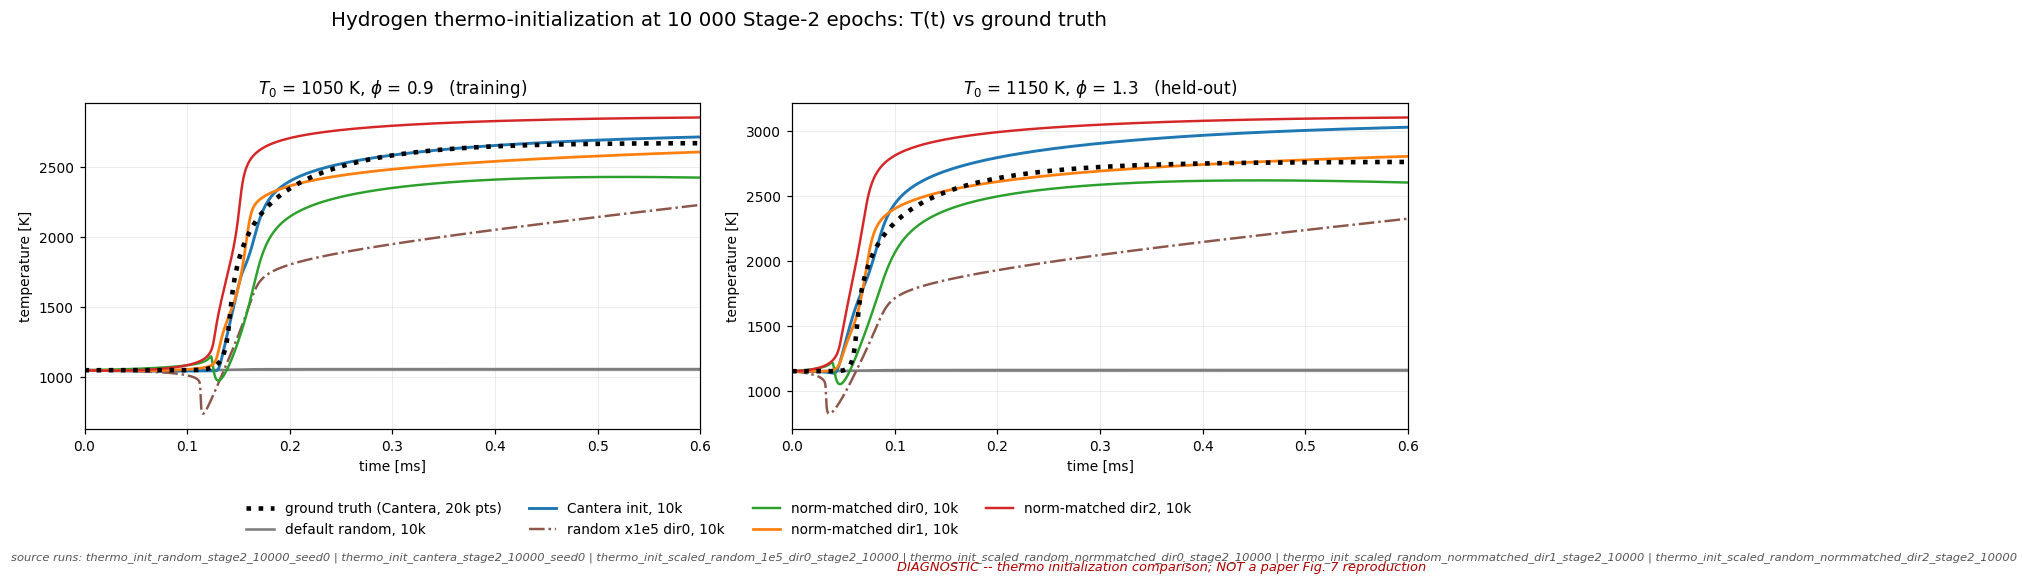

In [39]:
FIG10K = [("random10k",     "#7f7f7f", "-",   1.7, "default random, 10k"),
          ("cantera10k",    "#1f77b4", "-",   1.9, "Cantera init, 10k"),
          ("x1e5_dir0_10k", "#8c564b", "-.",  1.6, "random x1e5 dir0, 10k"),
          ("nm_dir0_10k",   "#2ca02c", "-",   1.6, "norm-matched dir0, 10k"),
          ("nm_dir1_10k",   "#ff7f0e", "-",   1.8, "norm-matched dir1, 10k"),
          ("nm_dir2_10k",   "#d62728", "-",   1.6, "norm-matched dir2, 10k")]

_TRAJ10K = {}                      # cached dense trajectories, reused by later sections
def dense_T(key, T0, phi):
    if (key, T0, phi) not in _TRAJ10K:
        _TRAJ10K[(key, T0, phi)] = integrate_arm(A[key], T0, phi, T_DENSE)[:, -1]
    return _TRAJ10K[(key, T0, phi)]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
for ax_, (T0, phi, role) in zip(axs, CONDS):
    Tr = reference_T_dense(T0, phi)
    ax_.plot(T_DENSE * 1e3, Tr, color="black", ls=":", lw=3.0,
             label="ground truth (Cantera, 20k pts)", zorder=10)
    for key, col, ls, lw, lab in FIG10K:
        ax_.plot(T_DENSE * 1e3, dense_T(key, T0, phi), color=col, ls=ls, lw=lw, label=lab)
    ax_.axhline(T0, color="#999999", lw=0.8, ls="-", zorder=0)
    ax_.set_title(f"$T_0$ = {T0:.0f} K, $\\phi$ = {phi:g}   ({role})", fontsize=11)
    ax_.set_xlabel("time [ms]"); ax_.set_ylabel("temperature [K]")
    ax_.set_xlim(0, T_DENSE[-1] * 1e3)
handles = axs[0].get_legend_handles_labels()
fig.suptitle("Hydrogen thermo-initialization at 10 000 Stage-2 epochs: T(t) vs ground truth",
             fontsize=13, y=1.005)
fig.legend(*handles, fontsize=9, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
fig.text(0.995, -0.055, "DIAGNOSTIC -- thermo initialization comparison; NOT a paper Fig. 7 "
         "reproduction", ha="right", fontsize=8.5, color="#b00000", style="italic")
fig.tight_layout(rect=(0, 0.10, 1, 0.97))
stem = FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison"
for ext in ("png", "pdf"):
    fig.savefig(f"{stem}.{ext}", dpi=200 if ext == "png" else None, bbox_inches="tight")
print("saved", rel(f"{stem}.png"), "and .pdf")
fig_source(fig, *[k for k, *_ in FIG10K])
plt.show()

---
# 17. Did long training repair the trajectory shape? 500 → 10 000 epochs

One panel per initialization: the genuine Cantera ground truth, the **epoch-500** model and
the **epoch-10 000** model, integrated from the same initial condition. The training
condition is shown first; the held-out condition follows.

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k.png and .pdf


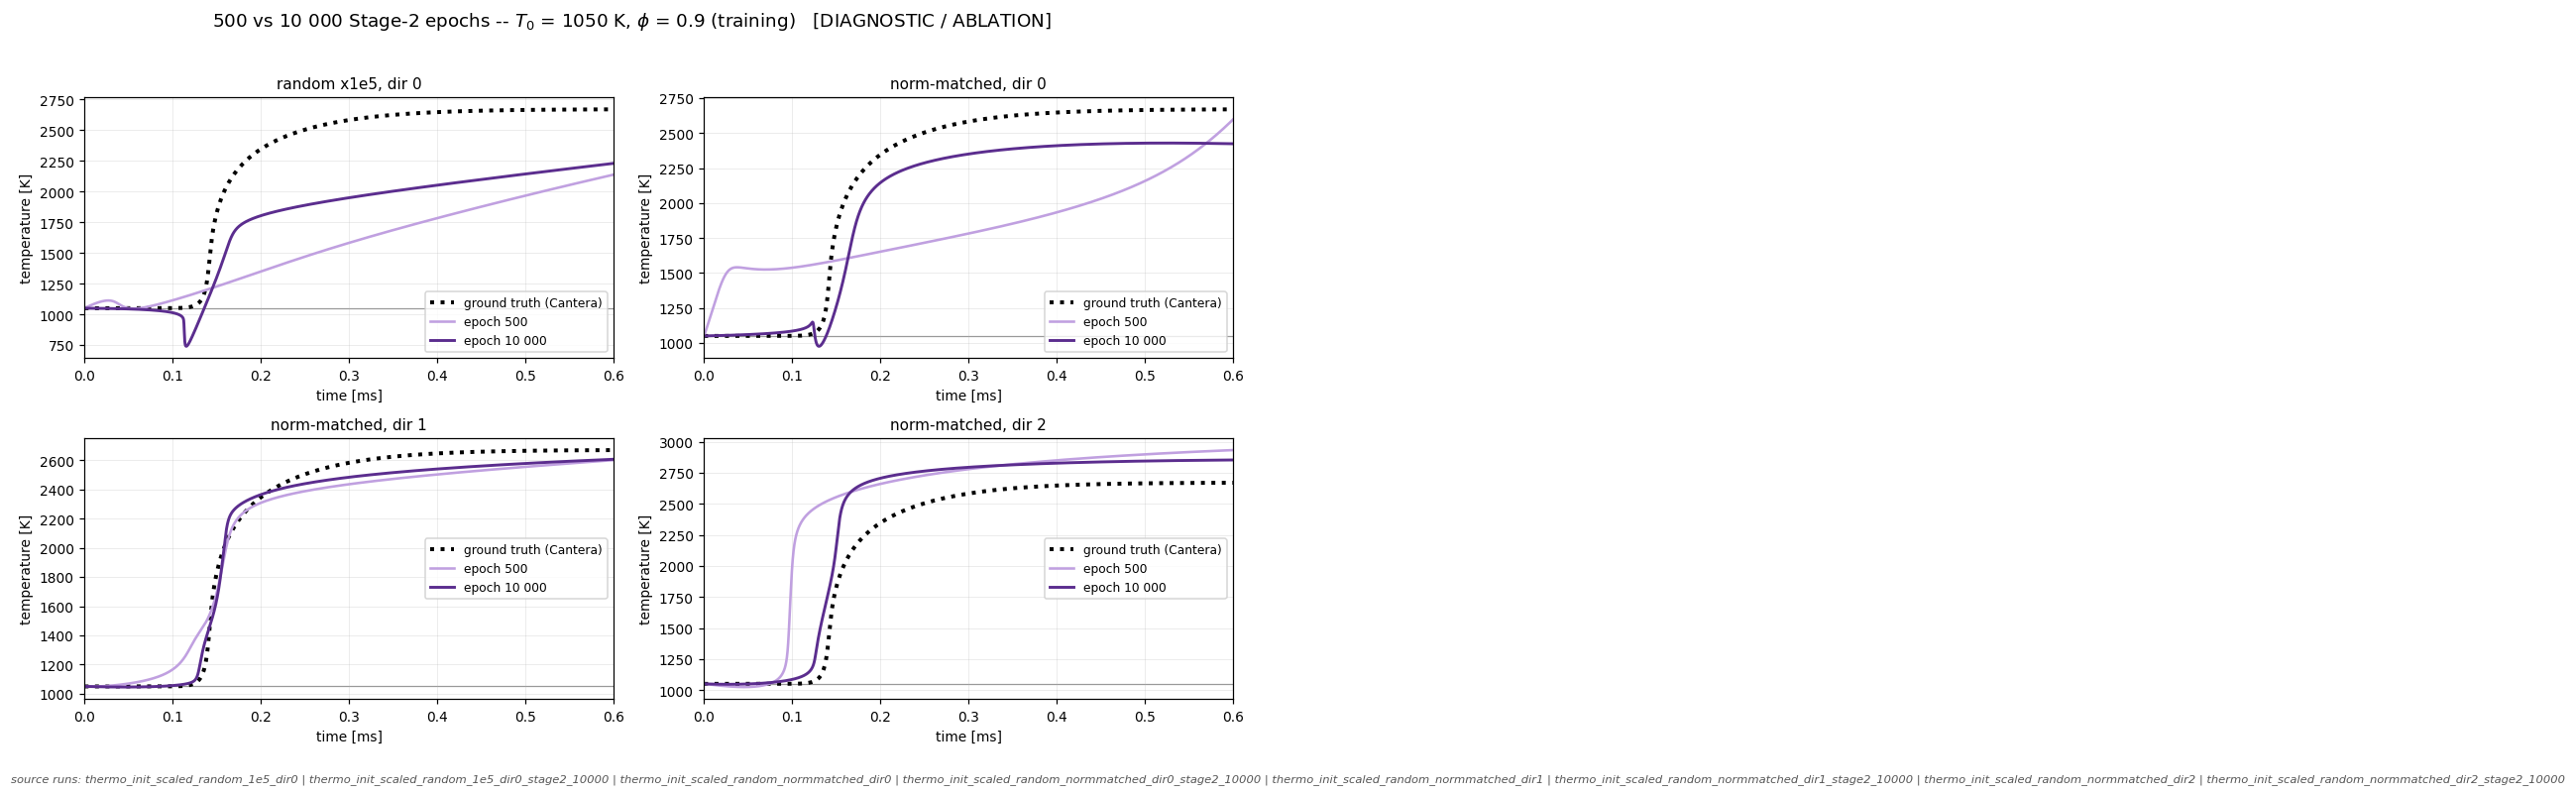

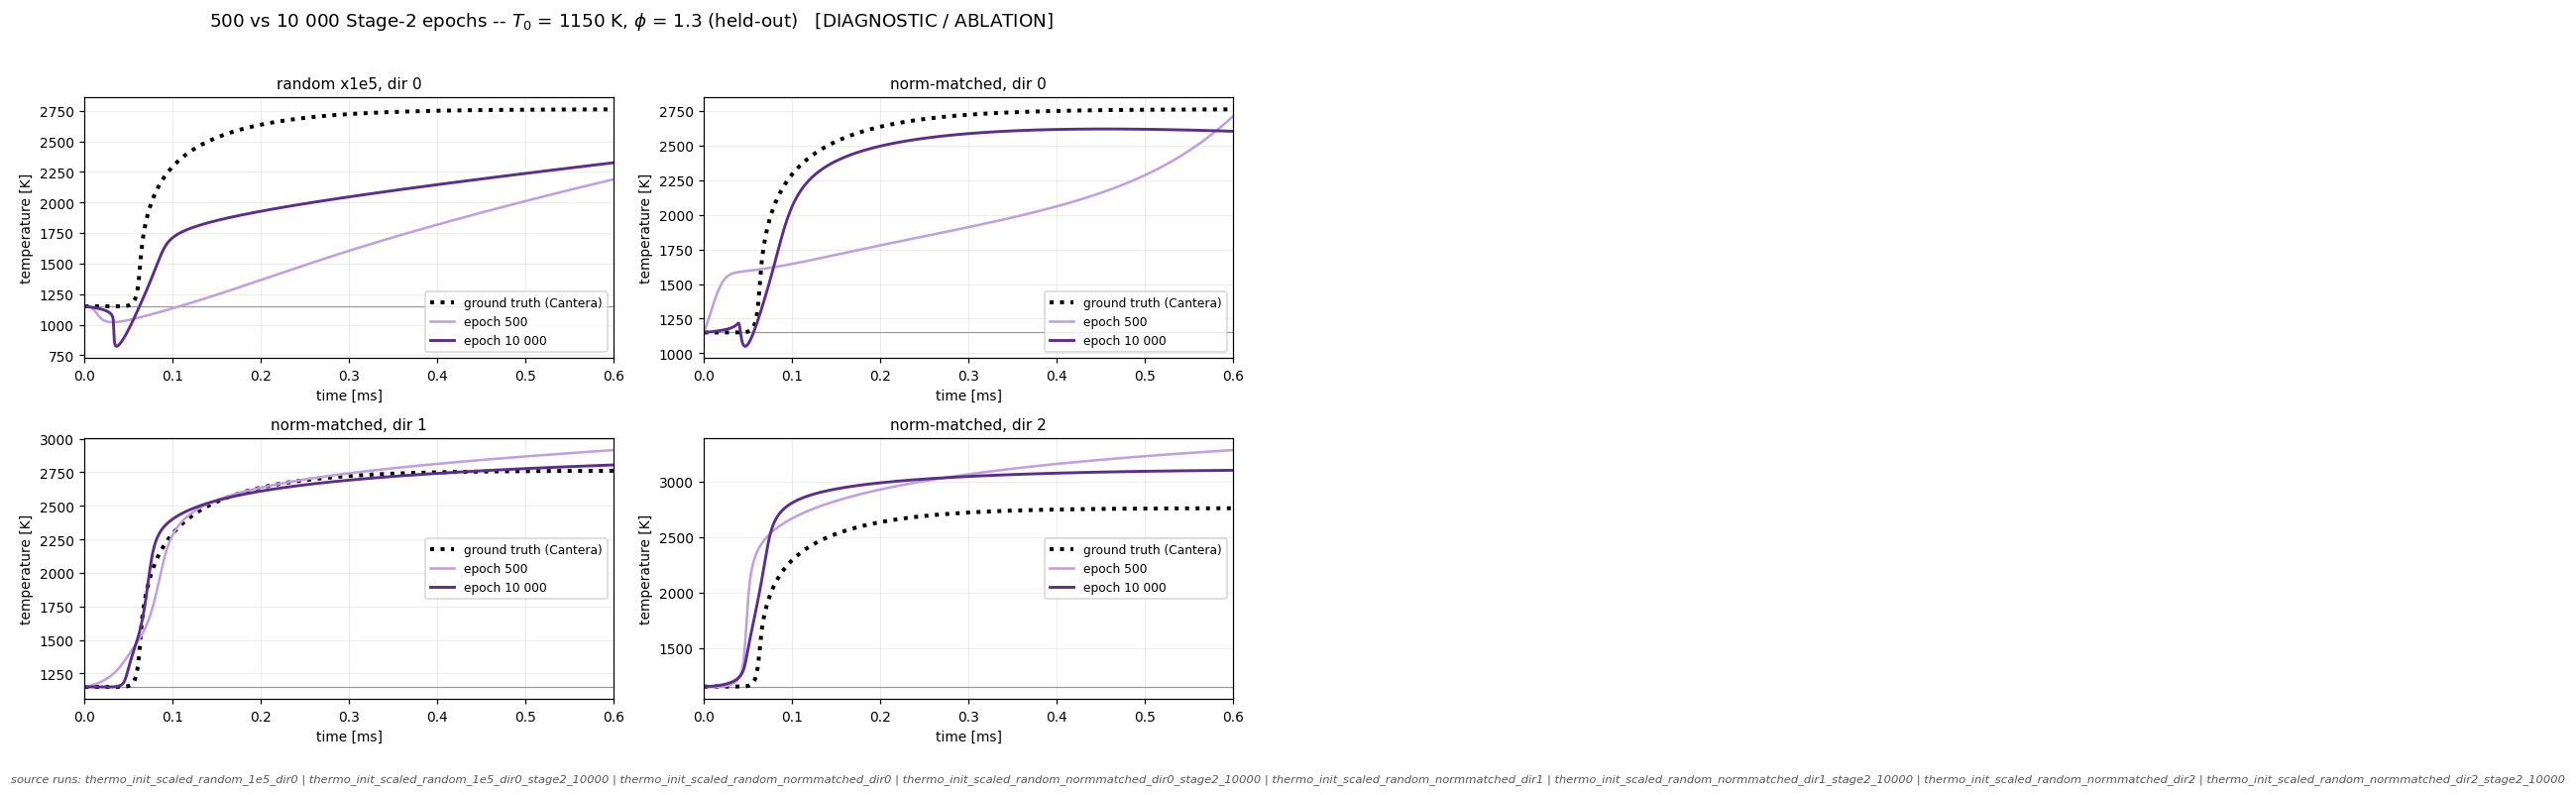

In [40]:
PERSIST_FIG = [("x1e5_dir0", "x1e5_dir0_10k", "random x1e5, dir 0"),
               ("nm_dir0",   "nm_dir0_10k",   "norm-matched, dir 0"),
               ("nm_dir1",   "nm_dir1_10k",   "norm-matched, dir 1"),
               ("nm_dir2",   "nm_dir2_10k",   "norm-matched, dir 2")]

def persistence_figure(T0, phi, role, stem=None):
    fig, axs = plt.subplots(2, 2, figsize=(11.5, 7.0))
    Tr = reference_T_dense(T0, phi)
    for ax_, (k500, k10k, label) in zip(axs.ravel(), PERSIST_FIG):
        ax_.plot(T_DENSE * 1e3, Tr, color="black", ls=":", lw=2.6, label="ground truth (Cantera)")
        ax_.plot(T_DENSE * 1e3, dense_T(k500, T0, phi), color="#c0a0e0", lw=1.7,
                 label="epoch 500")
        ax_.plot(T_DENSE * 1e3, dense_T(k10k, T0, phi), color="#5b2d8e", lw=1.9,
                 label="epoch 10 000")
        ax_.axhline(T0, color="#999999", lw=0.8, zorder=0)
        ax_.set_title(label, fontsize=10)
        ax_.set_xlabel("time [ms]"); ax_.set_ylabel("temperature [K]")
        ax_.set_xlim(0, T_DENSE[-1] * 1e3); ax_.legend(fontsize=8)
    fig.suptitle(f"500 vs 10 000 Stage-2 epochs -- $T_0$ = {T0:.0f} K, $\\phi$ = {phi:g} "
                 f"({role})   [DIAGNOSTIC / ABLATION]", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    if stem is not None:
        for ext in ("png", "pdf"):
            fig.savefig(f"{stem}.{ext}", dpi=200 if ext == "png" else None, bbox_inches="tight")
        print("saved", rel(f"{stem}.png"), "and .pdf")
    fig_source(fig, *[k for pair in PERSIST_FIG for k in pair[:2]])
    plt.show()

persistence_figure(1050.0, 0.9, "training",
                   FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k")
persistence_figure(1150.0, 1.3, "held-out")

---
# 18. How much does `θ_thermo` actually move during 10 000 epochs?

Norm alone cannot distinguish "the vector barely changed" from "the vector rotated while
keeping its length". This section therefore reports, at every probe epoch:

| quantity | meaning |
|---|---|
| `‖θ(e)‖` | magnitude |
| `‖θ(e) − θ(0)‖` | absolute parameter displacement |
| `‖θ(e) − θ(0)‖ / ‖θ(0)‖` | relative displacement |
| `cos(θ(e), θ(0))` | how much the direction rotated away from its initialization |
| `cos(θ(e), θ_Cantera)` | whether optimization moved *toward* the physical direction |

All nine coefficients are recorded per probe epoch in `stage2_probe.csv`, so this is read
from artifacts, not reconstructed. `θ_Cantera` is the historical diagnostic vector
(`T = 1050 K, Φ = 0.5`) recomputed here from Cantera, not copied.

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k.png and .pdf


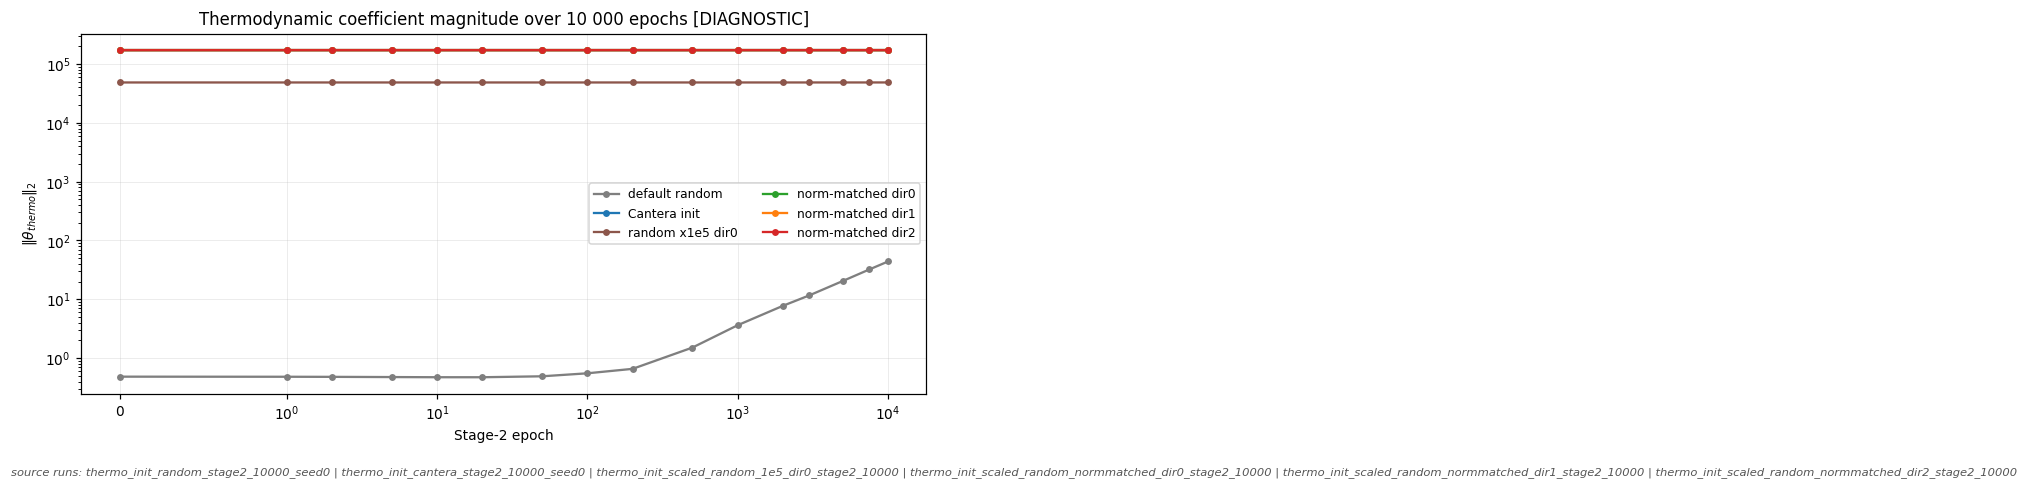

Norm alone is NOT evidence about rotation -- the direction analysis below is.


In [41]:
ARMS_10K = [("random10k",     "#7f7f7f", "default random"),
            ("cantera10k",    "#1f77b4", "Cantera init"),
            ("x1e5_dir0_10k", "#8c564b", "random x1e5 dir0"),
            ("nm_dir0_10k",   "#2ca02c", "norm-matched dir0"),
            ("nm_dir1_10k",   "#ff7f0e", "norm-matched dir1"),
            ("nm_dir2_10k",   "#d62728", "norm-matched dir2")]
COEFF_COLS = [f"coeff_{s}" for s in species]

def theta_history(key):
    """(epochs, theta(epoch) as (n_probe, m)) straight from stage2_probe.csv."""
    pr = probe_history(A[key]["run_dir"])
    return pr["epoch"].to_numpy(int), pr[COEFF_COLS].to_numpy(float), pr

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for key, col, lab in ARMS_10K:
    ep, th, pr = theta_history(key)
    ax.plot(ep, pr["thermo_linear_norm"], "o-", ms=3.5, color=col, label=lab)
ax.set_xscale("symlog", linthresh=1); ax.set_yscale("log")
ax.set_xlabel("Stage-2 epoch"); ax.set_ylabel(r"$\|\theta_{thermo}\|_2$")
ax.set_title("Thermodynamic coefficient magnitude over 10 000 epochs [DIAGNOSTIC]")
ax.legend(fontsize=8, ncol=2)
stem = FIGURES / "hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k"
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(f"{stem}.{ext}", dpi=200 if ext == "png" else None, bbox_inches="tight")
print("saved", rel(f"{stem}.png"), "and .pdf")
fig_source(fig, *[k for k, *_ in ARMS_10K])
plt.show()
print("Norm alone is NOT evidence about rotation -- the direction analysis below is.")

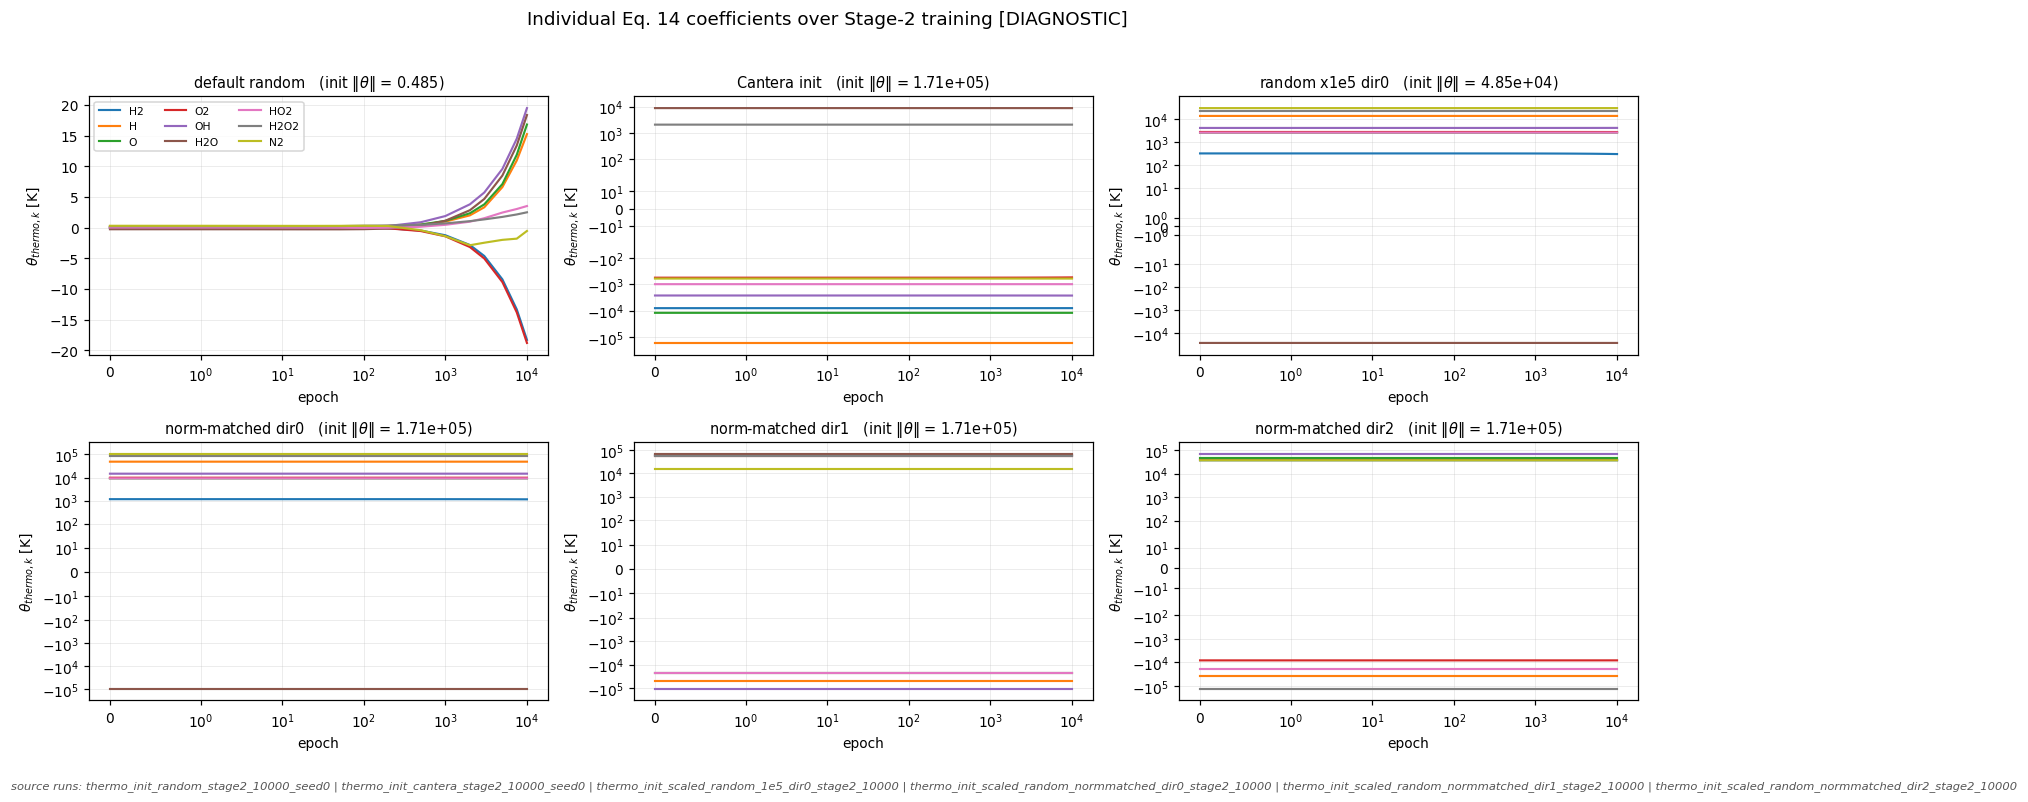

In [42]:
# Individual coefficients over training, one small panel per arm (nine species each).
fig, axs = plt.subplots(2, 3, figsize=(15, 7.0))
cmap = plt.get_cmap("tab10")
for ax_, (key, _, lab) in zip(axs.ravel(), ARMS_10K):
    ep, th, _ = theta_history(key)
    for k, sp in enumerate(species):
        ax_.plot(ep, th[:, k], "-", lw=1.4, color=cmap(k % 10), label=sp)
    ax_.set_xscale("symlog", linthresh=1)
    if np.abs(th).max() > 1e3:
        ax_.set_yscale("symlog", linthresh=max(1.0, np.abs(th).max() * 1e-4))
    ax_.set_title(f"{lab}   (init $\\|\\theta\\|$ = {np.linalg.norm(th[0]):.3g})", fontsize=9.5)
    ax_.set_xlabel("epoch"); ax_.set_ylabel(r"$\theta_{thermo,k}$ [K]")
axs.ravel()[0].legend(fontsize=7, ncol=3)
fig.suptitle("Individual Eq. 14 coefficients over Stage-2 training [DIAGNOSTIC]", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96)); fig_source(fig, *[k for k, *_ in ARMS_10K])
fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_direction_history_10k.png and .pdf


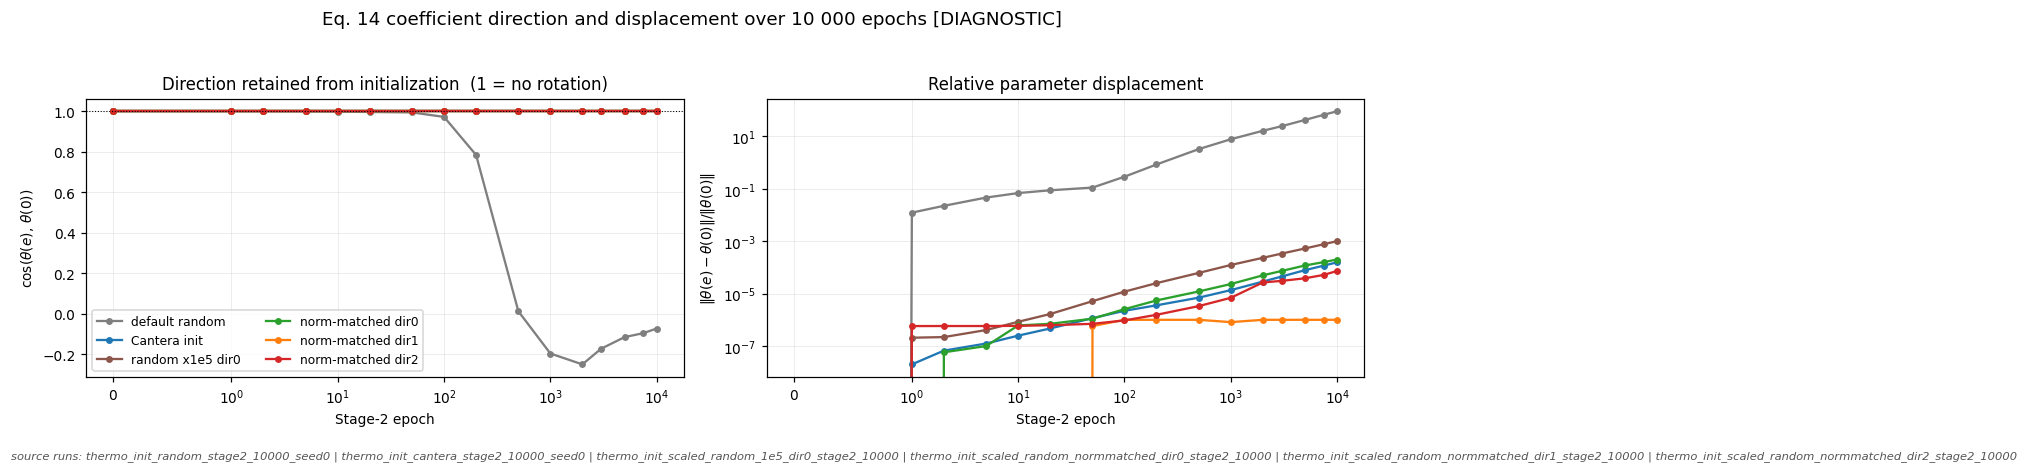

saved results/reproduction/chemkan/hydrogen/tables/hydrogen_thermo_linear_evolution_summary.csv


,key,initial_norm,final_norm,abs_displacement,relative_displacement,cos_final_initial,cos_initial_cantera,cos_final_cantera
arm,,,,,,,,
default random,random10k,0.4848,43.9749,44.0125,9.0780e+01,-0.0719,-0.3128,-0.3360
Cantera init,cantera10k,171227.5497,171227.1274,26.9999,1.5768e-04,1.0000,1.0000,1.0000
random x1e5 dir0,x1e5_dir0_10k,48482.6634,48511.2350,49.0609,1.0119e-03,1.0000,-0.3128,-0.3129
norm-matched dir0,nm_dir0_10k,171227.5980,171231.9278,34.5239,2.0163e-04,1.0000,-0.3128,-0.3129
norm-matched dir1,nm_dir1_10k,171227.5224,171227.5308,0.1732,1.0115e-06,1.0000,0.3169,0.3169
norm-matched dir2,nm_dir2_10k,171227.4231,171228.4328,12.6119,7.3656e-05,1.0000,0.1890,0.1889


In [43]:
def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else np.nan

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
move_rows = []
for key, col, lab in ARMS_10K:
    ep, th, pr = theta_history(key)
    th0 = th[0]
    c_init = np.array([cos(v, th0) for v in th])
    c_cant = np.array([cos(v, c_phys) for v in th])
    reldisp = np.linalg.norm(th - th0, axis=1) / np.linalg.norm(th0)
    ax[0].plot(ep, c_init, "o-", ms=3.5, color=col, label=lab)
    ax[1].plot(ep, reldisp, "o-", ms=3.5, color=col, label=lab)
    move_rows.append(dict(arm=lab, key=key,
                          initial_norm=float(np.linalg.norm(th0)),
                          final_norm=float(np.linalg.norm(th[-1])),
                          abs_displacement=float(np.linalg.norm(th[-1] - th0)),
                          relative_displacement=float(reldisp[-1]),
                          cos_final_initial=float(c_init[-1]),
                          cos_initial_cantera=float(c_cant[0]),
                          cos_final_cantera=float(c_cant[-1])))
for a_ in ax:
    a_.set_xscale("symlog", linthresh=1); a_.set_xlabel("Stage-2 epoch")
ax[0].set_ylabel(r"$\cos(\theta(e),\,\theta(0))$"); ax[0].axhline(1.0, color="k", lw=0.7, ls=":")
ax[0].set_title("Direction retained from initialization  (1 = no rotation)")
ax[1].set_yscale("log"); ax[1].set_ylabel(r"$\|\theta(e)-\theta(0)\|/\|\theta(0)\|$")
ax[1].set_title("Relative parameter displacement")
ax[0].legend(fontsize=8, ncol=2)
fig.suptitle("Eq. 14 coefficient direction and displacement over 10 000 epochs [DIAGNOSTIC]",
             fontsize=12)
stem = FIGURES / "hydrogen_DIAGNOSTIC_thermo_direction_history_10k"
fig.tight_layout(rect=(0, 0, 1, 0.94))
for ext in ("png", "pdf"):
    fig.savefig(f"{stem}.{ext}", dpi=200 if ext == "png" else None, bbox_inches="tight")
print("saved", rel(f"{stem}.png"), "and .pdf")
fig_source(fig, *[k for k, *_ in ARMS_10K])
plt.show()

movement = pd.DataFrame(move_rows).set_index("arm")
out = TABLES / "hydrogen_thermo_linear_evolution_summary.csv"
movement.to_csv(out); print("saved", rel(out))
movement

In [44]:
# Optional: how far did each MODEL BLOCK move during Stage 2?
#
# Epoch-0 availability is the limiting factor and is stated honestly:
#   kinetic core      -- available: it IS the shared checkpoint_stage1.pt
#   thermo.linear     -- available: probe epoch 0 records all nine coefficients
#   thermo.correction -- NOT available: its construction-time random init is not stored in
#                        any artifact, and it is not reconstructed here (that would require
#                        replaying the exact RNG sequence of the training script).
s1 = torch.load(A["stage1"]["run_dir"] / "checkpoint_stage1.pt", map_location="cpu",
                weights_only=False)["kinetic_state"]
rows = []
for key, _, lab in ARMS_10K:
    sd = A[key]["model"].state_dict()
    kin_f = torch.cat([sd[f"kinetic.{n}"].reshape(-1) for n in s1])
    kin_0 = torch.cat([s1[n].reshape(-1) for n in s1])
    ep, th, _ = theta_history(key)
    rows.append(dict(
        arm=lab,
        kinetic_abs_disp=float(torch.linalg.vector_norm(kin_f - kin_0)),
        kinetic_rel_disp=float(torch.linalg.vector_norm(kin_f - kin_0) /
                               torch.linalg.vector_norm(kin_0)),
        thermo_linear_abs_disp=float(np.linalg.norm(th[-1] - th[0])),
        thermo_linear_rel_disp=float(np.linalg.norm(th[-1] - th[0]) / np.linalg.norm(th[0])),
        thermo_correction_rel_disp=np.nan))
blocks = pd.DataFrame(rows).set_index("arm")
print("thermo.correction displacement is left as NaN: its epoch-0 values are not recorded")
print("in any artifact and are NOT invented here.")
blocks

thermo.correction displacement is left as NaN: its epoch-0 values are not recorded
in any artifact and are NOT invented here.


,kinetic_abs_disp,kinetic_rel_disp,thermo_linear_abs_disp,thermo_linear_rel_disp,thermo_correction_rel_disp
arm,,,,,
default random,7.4730,0.1870,44.0125,9.0780e+01,NaN
Cantera init,17.2200,0.4309,26.9999,1.5768e-04,NaN
random x1e5 dir0,50.3769,1.2605,49.0609,1.0119e-03,NaN
norm-matched dir0,35.5546,0.8896,34.5239,2.0163e-04,NaN
norm-matched dir1,8.9099,0.2229,0.1732,1.0115e-06,NaN
norm-matched dir2,17.8982,0.4478,12.6119,7.3656e-05,NaN


In [45]:
# Runtime of each 10k Stage-2 run, parsed from run.log timestamps (no re-running).
import re, datetime as _dt
def run_wall_time(key):
    log = (A[key]["run_dir"] / "run.log")
    if not log.exists():
        return np.nan
    ts = re.findall(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),\d+", log.read_text(), re.M)
    if len(ts) < 2:
        return np.nan
    fmt = "%Y-%m-%d %H:%M:%S"
    return (_dt.datetime.strptime(ts[-1], fmt) - _dt.datetime.strptime(ts[0], fmt)).total_seconds()

rt = pd.DataFrame([dict(arm=lab, key=key, wall_time_h=run_wall_time(key) / 3600.0)
                   for key, _, lab in ARMS_10K]).set_index("arm")
rt["s_per_epoch"] = rt["wall_time_h"] * 3600 / 10000.0
rt["x slowest / fastest"] = rt["wall_time_h"] / rt["wall_time_h"].min()
rt

,key,wall_time_h,s_per_epoch,x slowest / fastest
arm,,,,
default random,random10k,1.1864,0.4271,1.0000
Cantera init,cantera10k,1.6950,0.6102,1.4287
random x1e5 dir0,x1e5_dir0_10k,3.2233,1.1604,2.7169
norm-matched dir0,nm_dir0_10k,1.5908,0.5727,1.3409
norm-matched dir1,nm_dir1_10k,1.4744,0.5308,1.2428
norm-matched dir2,nm_dir2_10k,1.8628,0.6706,1.5701


> **What `nfe` counts.** NFE = "number of function evaluations" = the number of times the ODE
> **right-hand side** `f(t, u)` was evaluated during that epoch's solve. It counts calls to
> `ChemKANDynamics.forward`, recorded by a forward hook.
>
> It is **not** the number of `odeint` calls — that is exactly **one per epoch**, a single
> batched solve covering all 35 trajectories. NFE is how much work the *adaptive* Tsit5 solver
> needed *inside* that one call: more internal steps, or more rejected steps, mean more RHS
> evaluations. Tsit5 uses ~6–7 RHS evaluations per accepted step, so NFE ≈ 7 × (steps taken).
>
> It is therefore a direct measure of **solver effort**, and a proxy for how numerically
> difficult the learned dynamics are to integrate — not a stiffness measurement in the formal
> (Jacobian eigenvalue) sense. Rising NFE at fixed tolerances means the solver is being forced
> into smaller steps.

### Runtime observation (recorded, not explained)

The 10 000-epoch runs differ substantially in wall-clock time despite an identical epoch
budget, architecture, solver and tolerances. The table above is parsed from each run's
`run.log` timestamps.

**What can be said:** some of the large-scale arms became substantially slower over the
course of optimization.

**What cannot be said:** *why*. Two candidate explanations are

* increased adaptive-solver work — a learned right-hand side that is numerically harder to
  integrate would force smaller Tsit5 steps and more RHS evaluations; and
* system-level effects on the machine, e.g. CPU thermal throttling or contention.

**Neither has been isolated**, because the runs did not record per-epoch wall time or the
number of RHS evaluations (NFE). Stiffness is therefore **not** claimed as the cause.

*Motivation for future instrumentation* (not implemented here, and **not** a reason to
re-run these experiments): log `epoch_wall_time_s` and an NFE/RHS counter per epoch so the
solver-work hypothesis becomes testable directly.

### 18E. Why does `dir0` fail where `dir1` succeeds?

§15–§17 measure *that* two equal-norm random directions end ~26× apart in test trajectory
MSE. They do not explain *why*. This subsection tests one candidate explanation:
**alignment with the physical direction, restricted to the species that actually react.**

The plain 9-D cosine of §18 weights all nine species equally. But `dT/dt = Σ c_k dY_k/dt`,
so a coefficient multiplying a species whose rate is ~0 contributes nothing to heat release,
no matter how large it is. N2 is inert by construction and H2O2/HO2 are trace intermediates.
A cosine that counts them equally can therefore be dominated by coefficients that do no
work. The **rate-weighted** cosine below scales each species by its peak `|dY_k/dt|` along
the reference trajectory before taking the angle.

In [46]:
# Initial coefficient vectors (from each run's config provenance) against the physical one,
# weighted by how much each species actually moves.
def initial_vector(key):
    ti = A[key]["config"]["thermo_init"]
    return np.asarray(ti.get("resulting_vector") or ti["coefficients"], dtype=float)

DIRS = [("nm_dir0", "dir0"), ("nm_dir1", "dir1"), ("nm_dir2", "dir2")]
V = {lab: initial_vector(k) for k, lab in DIRS}
V["Cantera"] = c_phys

# how much each species moves on the reference trajectory (training condition)
_ref = reference(1050.0, 0.9)
dY_ref = np.gradient(_ref, t, axis=0)[:, :m]
rate_weight = np.abs(dY_ref).max(axis=0)

vec = pd.DataFrame(V, index=species)
vec["peak |dY/dt| [1/s]"] = rate_weight
for _, lab in DIRS:
    vec[f"{lab} sign vs Cantera"] = np.where(np.sign(V[lab]) == np.sign(c_phys), "ok", "WRONG")
print("Initial Eq. 14 coefficients [K], and how much each species actually reacts:\n")
display(vec.round(0))

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

align = pd.DataFrame({
    "plain cosine vs Cantera": {lab: cosine(V[lab], c_phys) for _, lab in DIRS},
    "RATE-WEIGHTED cosine vs Cantera": {lab: cosine(V[lab] * rate_weight,
                                                   c_phys * rate_weight) for _, lab in DIRS},
    "test MSE at 10k": {lab: _MSE[f"nm_{lab}_10k"]["test"] for _, lab in DIRS},
})
display(align)

Initial Eq. 14 coefficients [K], and how much each species actually reacts:



,dir0,dir1,dir2,Cantera,peak |dY/dt| [1/s],dir0 sign vs Cantera,dir1 sign vs Cantera,dir2 sign vs Cantera
H2,1161.0,58371.0,36704.0,-8093.0,861.0,WRONG,WRONG,WRONG
H,48679.0,-50001.0,-38077.0,-170341.0,139.0,WRONG,ok,ok
O,9227.0,-21961.0,43878.0,-12177.0,667.0,WRONG,ok,WRONG
O2,9834.0,53172.0,-8173.0,-562.0,6657.0,WRONG,WRONG,ok
OH,14700.0,-106649.0,68353.0,-2671.0,682.0,WRONG,ok,WRONG
H2O,-92549.0,67938.0,38093.0,8720.0,6171.0,WRONG,ok,ok
HO2,9252.0,-23305.0,-18390.0,-991.0,5.0,WRONG,ok,ok
H2O2,81520.0,57632.0,-129359.0,2050.0,0.0,ok,ok,WRONG
N2,106083.0,15748.0,36532.0,-606.0,0.0,WRONG,WRONG,WRONG


,plain cosine vs Cantera,RATE-WEIGHTED cosine vs Cantera,test MSE at 10k
dir0,-0.3128,-0.9066,5.3996
dir1,0.3169,0.6399,0.2071
dir2,0.1890,0.8323,3.9029


In [47]:
# Per-species heat release c_k * dY_k/dt at the reference peak-dT/dt instant.
kmax = int(np.gradient(_ref[:, -1], t).argmax())
contrib = pd.DataFrame({lab: V[lab] * dY_ref[kmax] for lab in V}, index=species)
ref_dTdt = float(np.gradient(_ref[:, -1], t)[kmax])
print(f"Per-species linear-branch heat release at the reference peak instant "
      f"(t = {t[kmax]*1e3:.4f} ms) [K/s]:\n")
display(contrib.round(0))
net = contrib.sum().rename("net linear-branch dT/dt [K/s]").to_frame()
net["ratio to reference"] = net.iloc[:, 0] / ref_dTdt
print(f"reference dT/dt at that instant = {ref_dTdt:.4e} K/s")
display(net)

dom = contrib.abs().idxmax()
print("dominant species in each vector:", dict(dom))
print(f"\nH2O is the largest positive reference rate ({rate_weight[species.index('H2O')]:.0f} 1/s) "
      f"and has a POSITIVE physical coefficient ({c_phys[species.index('H2O')]:+.0f} K):")
for lab in ("dir0", "dir1", "dir2", "Cantera"):
    v = V[lab][species.index("H2O")]
    print(f"    {lab:8s} c_H2O = {v:+10.0f} K   -> contributes {contrib.loc['H2O', lab]:+.3e} K/s")

Per-species linear-branch heat release at the reference peak instant (t = 0.1469 ms) [K/s]:



,dir0,dir1,dir2,Cantera
H2,-8.9099e+05,-4.4796e+07,-2.8168e+07,6.2111e+06
H,3.4205e+06,-3.5134e+06,-2.6756e+06,-1.1969e+07
O,4.5463e+06,-1.0821e+07,2.1620e+07,-5.9999e+06
O2,-6.2374e+07,-3.3726e+08,5.1839e+07,3.5630e+06
OH,1.0023e+07,-7.2716e+07,4.6604e+07,-1.8211e+06
H2O,-5.4328e+08,3.9881e+08,2.2361e+08,5.1188e+07
HO2,-4.2513e+04,1.0709e+05,8.4506e+04,4.5530e+03
H2O2,-7.5290e+03,-5.3230e+03,1.1948e+04,-1.8900e+02
N2,0.0000e+00,0.0000e+00,0.0000e+00,-0.0000e+00


reference dT/dt at that instant = 3.5282e+07 K/s


,net linear-branch dT/dt [K/s],ratio to reference
dir0,-5.8860e+08,-16.6829
dir1,-7.0197e+07,-1.9896
dir2,3.1293e+08,8.8694
Cantera,4.1176e+07,1.1671


dominant species in each vector: {'dir0': 'H2O', 'dir1': 'H2O', 'dir2': 'H2O', 'Cantera': 'H2O'}

H2O is the largest positive reference rate (6171 1/s) and has a POSITIVE physical coefficient (+8720 K):
    dir0     c_H2O =     -92549 K   -> contributes -5.433e+08 K/s
    dir1     c_H2O =     +67938 K   -> contributes +3.988e+08 K/s
    dir2     c_H2O =     +38093 K   -> contributes +2.236e+08 K/s
    Cantera  c_H2O =      +8720 K   -> contributes +5.119e+07 K/s


**What this establishes.** `dir0`'s H2O coefficient has the **wrong sign** and is the largest
entry in its vector, while H2O carries the largest positive species rate in the mechanism.
The result is that `dir0` begins Stage 2 as a **heat sink where the reference is a heat
source**, with a net linear-branch `dT/dt` of about **−17×** the reference value at its peak
instant. Its two biggest coefficients overall sit on N2 (inert) and H2O2 (trace), which is
exactly why the *plain* cosine understates how badly it is misaligned: rate-weighting moves
`dir0` from ≈ −0.31 to ≈ **−0.91**, i.e. nearly anti-parallel to the physical direction in
the subspace that produces heat.

For calibration, none of the random directions starts out well: at that same instant `dir1`
is also net-negative (≈ −2× the reference) and `dir2` is net-positive but ≈ +9× too large,
against Cantera's ≈ +1.2×. The distinction is one of degree and of *sign structure* —
`dir0` is an order of magnitude further from the reference than `dir1`, and it is the only
one whose dominant H2O term opposes physics.

**Why it is never repaired.** §18 showed `cos(θ_final, θ_0) = 1` to ~1e−7 for every
large-scale arm — and §18F below shows this is a consequence of the optimizer's bounded step
against a vector of norm ~1.7e5, not of a vanishing gradient. Either way the conclusion for
`dir0` is the same: **the initial sign structure is effectively locked in for the whole run.**
The network can only compensate by deforming the *kinetic* core around a broken
*thermodynamic* map, which is what the block-displacement table shows it doing.

**What this does NOT establish.** Rate-weighted alignment separates `dir0` from the other
two, but it does **not** rank `dir1` above `dir2`: `dir2` has the *higher* rate-weighted
alignment yet ends up far worse in test MSE (see the table above). So this explains `dir0`'s
**failure**; it does **not** explain `dir1`'s **success**. With three directions and one
global seed that remains open, consistent with §23's NOT ESTABLISHED entry on whether
`dir1` is special among random directions.

### 18F. What gradient actually reaches `θ_thermo`?

Everything measured so far is parameter **displacement** (`θ_final − θ_0`); the Stage-2 probe
runs entirely under `torch.no_grad()`, so no gradient was ever recorded during training. That
leaves the §18 reading ambiguous: does `θ_thermo` barely move because its **gradient is
tiny**, or because a vector of norm ~1.7e5 simply **cannot be moved far** by an optimizer
whose step is bounded?

Both questions are settled below. The cell performs **one forward + one backward pass** per
arm on the *exact* Stage-2 objective — `chemkan_loss` with the PINN term, the same
normalization, solver and tolerances — and reads `‖∂L/∂θ‖` per block. **No optimizer step is
taken and no parameter is modified.** The reconstructed loss is reported against each run's
recorded final loss as a sanity check — an *exact* match is not expected, because the probe's
epoch-10000 value is evaluated before that epoch's optimizer step while the checkpoint holds
the parameters after it.

**Two limitations, stated up front.** This is the gradient **at the final checkpoint**, not
during training; per-epoch gradient norms were never logged. And a true **epoch-0** gradient
is **not reconstructible**, because `thermo.correction`'s construction-time values are not
stored in any artifact — the same gap that leaves its displacement as `NaN` above. Neither is
invented here.

In [48]:
from chemkan.losses import chemkan_loss
from _chemistry import ELEMENT_COUNTS, ATOMIC_WEIGHTS, MOLAR_WEIGHTS
from _data import load_hydrogen

_d2 = load_hydrogen(split="train")
_u0 = _d2["full_TBm1"][0]
_tt = _d2["t"]
_fn2 = MinMaxNormalizer(_d2["u_min"], _d2["u_max"])   # exactly as train_hydrogen builds it
_tgt = _fn2.normalize(_d2["full_TBm1"])

def stage2_gradients(key):
    """One forward+backward on the exact Stage-2 loss. Takes NO optimizer step."""
    ckpt = torch.load(A[key]["run_dir"] / "checkpoint_final.pt", map_location="cpu",
                      weights_only=False)
    mdl = build_chemkan(ckpt, m, "cpu")           # a fresh copy; A[key]["model"] is untouched
    mdl.train()
    for p in mdl.parameters():
        p.requires_grad_(True)
    dyn = ChemKANDynamics(mdl, input_normalizer=load_input_scaling(ckpt, "cpu"))
    pred = integrate(dyn, _u0, _tt, solver_from_ckpt(ckpt))          # differentiable solve
    loss = chemkan_loss(_fn2.normalize(pred), _tgt, use_pinn=True, alpha_pinn=1e-4,
                        Y_phys=pred[..., :m], element_counts=ELEMENT_COUNTS,
                        atomic_weights=ATOMIC_WEIGHTS, molar_weights=MOLAR_WEIGHTS)
    mdl.zero_grad(set_to_none=True)
    loss.backward()
    grads = {n: p.grad.detach() for n, p in mdl.named_parameters() if p.grad is not None}
    pars = {n: p.detach() for n, p in mdl.named_parameters()}
    def nrm(prefix, src):
        sel = [v.reshape(-1) for k, v in src.items() if k.startswith(prefix)]
        return float(torch.linalg.vector_norm(torch.cat(sel)))
    return dict(loss=float(loss.detach()),
                grad_kinetic=nrm("kinetic", grads),
                grad_thermo_linear=nrm("thermo.linear", grads),
                grad_thermo_correction=nrm("thermo.correction", grads),
                theta_thermo_norm=nrm("thermo.linear", pars),
                max_abs_grad_thermo=float(grads["thermo.linear.weight"].abs().max()))

grad_rows = []
for key, _, lab in ARMS_10K:
    r = stage2_gradients(key)
    recorded = float(probe_history(A[key]["run_dir"])["stage2_loss"].iloc[-1])
    grad_rows.append(dict(arm=lab, key=key, recorded_final_loss=recorded, **r))
gradients = pd.DataFrame(grad_rows).set_index("arm")
gradients["grad_thermo / grad_kinetic"] = (gradients.grad_thermo_linear
                                           / gradients.grad_kinetic)
gradients["rel_loss_gap"] = ((gradients.loss - gradients.recorded_final_loss).abs()
                             / gradients.recorded_final_loss)
print("dL/dtheta AT THE FINAL CHECKPOINT -- one backward pass per arm, no optimizer step.\n")
print("Consistency of the reconstructed Stage-2 loss against each run's recorded value:")
for a in gradients.index:
    print(f"   {a:20s} reconstructed {gradients.loc[a,'loss']:.4f}  vs recorded "
          f"{gradients.loc[a,'recorded_final_loss']:.4f}   "
          f"({gradients.loc[a,'rel_loss_gap']:.2%})")
_worst = gradients['rel_loss_gap'].idxmax()
print(f"\nLargest gap: {_worst} at {gradients.loc[_worst,'rel_loss_gap']:.2%}; all others "
      f"<= {gradients['rel_loss_gap'].drop(_worst).max():.2%}.")
print("An exact match is NOT expected: the probe's epoch-10000 value is evaluated BEFORE that")
print("epoch's optimizer step, whereas the checkpoint holds the parameters after it, and the")
print("adaptive solver is not bit-reproducible across a different call pattern. The gap is")
print("largest for the arm whose loss is still descending fastest. It is reported, not hidden,")
print("and cannot affect the conclusion below, which rests on ratios spanning 5-6 orders of")
print("magnitude.\n")
gradients[["loss", "recorded_final_loss", "rel_loss_gap", "grad_kinetic",
           "grad_thermo_linear", "grad_thermo_correction",
           "grad_thermo / grad_kinetic", "max_abs_grad_thermo"]]

dL/dtheta AT THE FINAL CHECKPOINT -- one backward pass per arm, no optimizer step.

Consistency of the reconstructed Stage-2 loss against each run's recorded value:
   default random       reconstructed 2.1228  vs recorded 2.1272   (0.21%)
   Cantera init         reconstructed 0.2369  vs recorded 0.2366   (0.12%)
   random x1e5 dir0     reconstructed 3.7575  vs recorded 3.7473   (0.27%)
   norm-matched dir0    reconstructed 3.1114  vs recorded 3.0426   (2.26%)
   norm-matched dir1    reconstructed 0.2698  vs recorded 0.2698   (0.01%)
   norm-matched dir2    reconstructed 2.2581  vs recorded 2.2674   (0.41%)

Largest gap: norm-matched dir0 at 2.26%; all others <= 0.41%.
An exact match is NOT expected: the probe's epoch-10000 value is evaluated BEFORE that
epoch's optimizer step, whereas the checkpoint holds the parameters after it, and the
adaptive solver is not bit-reproducible across a different call pattern. The gap is
largest for the arm whose loss is still descending fastest. It is

,loss,recorded_final_loss,rel_loss_gap,grad_kinetic,grad_thermo_linear,grad_thermo_correction,grad_thermo / grad_kinetic,max_abs_grad_thermo
arm,,,,,,,,
default random,2.1228,2.1272,0.0021,48.4900,7.8526e-04,9.6506e-06,1.6194e-05,5.7206e-04
Cantera init,0.2369,0.2366,0.0012,19.0782,1.8802e-05,2.8691e-06,9.8553e-07,1.4976e-05
random x1e5 dir0,3.7575,3.7473,0.0027,7.2915,8.7774e-05,2.4821e-06,1.2038e-05,7.6271e-05
norm-matched dir0,3.1114,3.0426,0.0226,77.9333,4.2581e-04,1.6166e-05,5.4638e-06,4.1955e-04
norm-matched dir1,0.2698,0.2698,0.0001,50.2278,1.0402e-04,6.8844e-06,2.0709e-06,7.7479e-05
norm-matched dir2,2.2581,2.2674,0.0041,40.9301,1.3801e-04,7.5534e-06,3.3718e-06,1.3381e-04


In [49]:
# Is the small MOVEMENT explained by the small gradient, or by the optimizer's step bound?
#
# Adam's per-coordinate update is lr * m_hat / (sqrt(v_hat) + eps), whose magnitude is
# bounded by roughly lr REGARDLESS of the gradient's size. Over N steps a p-dimensional
# vector can therefore travel at most about lr * N * sqrt(p) even with every step aligned.
LR = float(A["random10k"]["config"]["learning_rate"])
N_STEPS = int((A["random10k"]["config"].get("epochs") or {}).get("stage2"))
ADAM_CEILING = LR * N_STEPS * np.sqrt(m)
print(f"lr = {LR}, steps = {N_STEPS}, dim = {m}")
print(f"-> Adam displacement ceiling ~ lr*steps*sqrt(dim) = {ADAM_CEILING:.1f}\n")

budget = movement[["initial_norm", "abs_displacement", "relative_displacement"]].copy()
budget["% of Adam ceiling"] = 100 * budget["abs_displacement"] / ADAM_CEILING
budget["grad_thermo_linear"] = [gradients.loc[l, "grad_thermo_linear"]
                                if l in gradients.index else np.nan for l in budget.index]
display(budget)

x = np.log10(budget["initial_norm"].to_numpy())
print(f"corr(log10 ||theta_0||, ABSOLUTE displacement) = "
      f"{np.corrcoef(x, budget['abs_displacement'])[0,1]:+.3f}")
print(f"corr(log10 ||theta_0||, log10 RELATIVE displacement) = "
      f"{np.corrcoef(x, np.log10(budget['relative_displacement']))[0,1]:+.3f}")
out = TABLES / "hydrogen_thermo_gradient_flow.csv"
gradients.join(budget[["abs_displacement", "% of Adam ceiling"]]).to_csv(out)
print("\nsaved", rel(out))

lr = 0.002, steps = 10000, dim = 9
-> Adam displacement ceiling ~ lr*steps*sqrt(dim) = 60.0



,initial_norm,abs_displacement,relative_displacement,% of Adam ceiling,grad_thermo_linear
arm,,,,,
default random,0.4848,44.0125,9.0780e+01,73.3541,7.8526e-04
Cantera init,171227.5497,26.9999,1.5768e-04,44.9998,1.8802e-05
random x1e5 dir0,48482.6634,49.0609,1.0119e-03,81.7682,8.7774e-05
norm-matched dir0,171227.5980,34.5239,2.0163e-04,57.5398,4.2581e-04
norm-matched dir1,171227.5224,0.1732,1.0115e-06,0.2887,1.0402e-04
norm-matched dir2,171227.4231,12.6119,7.3656e-05,21.0199,1.3801e-04


corr(log10 ||theta_0||, ABSOLUTE displacement) = -0.483
corr(log10 ||theta_0||, log10 RELATIVE displacement) = -0.943

saved results/reproduction/chemkan/hydrogen/tables/hydrogen_thermo_gradient_flow.csv


**What the gradient measurement establishes.**

1. **`θ_thermo` receives a gradient 5–6 orders of magnitude smaller than the kinetic core**
   at the final checkpoint, in *every* arm including the default-random control.
   `thermo.correction`'s is smaller still. The nine Eq. 14 scalars are, in raw gradient
   terms, by far the most weakly driven parameters in the network.
2. **But that does not explain the small movement, and the §18 relative-displacement metric
   is confounded.** Adam normalizes by the gradient's running RMS, so the step size is
   bounded by ≈ `lr` per coordinate whatever the gradient magnitude. Most arms travel
   **45–82 % of that ceiling** — they are moving at close to the maximum rate the optimizer
   permits. `relative_displacement` is then essentially `(bounded travel) / ‖θ₀‖`, which is
   why it correlates with `log‖θ₀‖` at ≈ −0.94 while the *absolute* displacement barely
   correlates with it at all.
3. **`dir1` is the genuine exception.** It moves only ~0.3 % of the ceiling — two orders
   below every other arm — which means its gradient is not merely small but *cancelling*
   across steps. That is the signature of a parameter sitting near a stationary point, and
   it is consistent with `dir1` being the best-fitting arm rather than a stuck one.

**Correction to the earlier reading.** §18's headline — "large `θ_thermo` vectors undergo
essentially no directional movement" — is arithmetically true but was over-interpreted as an
*optimization* finding. It is mostly a consequence of the initialization scale set against a
bounded step budget. The claim that survives, and that the rest of the notebook actually
relies on, is narrower and still decisive:

> **A `θ_thermo` initialized at O(10⁵) cannot be rotated appreciably within a 10 000-epoch
> Adam budget at `lr = 2e-3`, so whatever sign structure it starts with is effectively locked
> in for the entire run.** This is why `dir0`'s wrong-signed H2O coefficient (§18E) is never
> repaired, and why the *initial direction* — not the trained one — decides the outcome.

*Future instrumentation* (not a reason to re-run anything): log `‖∂L/∂θ‖` per block per epoch
alongside the `epoch_wall_time_s` / NFE counters already proposed, so the gradient history
becomes observable rather than reconstructed at a single point.

---
# 13B. Operational ignition-flag history over the full 10 000-epoch budget

The pre-registered classifier of §13, now applied to the complete long-budget histories.

In [50]:
# Full probe history of every 10k arm (the 500-epoch arms are the first ten rows of these
# same schedules; see the persistence study in section 15).
for k in [x for x in ("random10k", "cantera10k", "x1e5_dir0_10k", "nm_dir0_10k",
                      "nm_dir1_10k", "nm_dir2_10k") if x in A]:
    pr = probe_history(A[k]["run_dir"])
    print(f"\n=== {k}   ->   {CLASS[k].upper()}")
    print(pr[["epoch", "stage2_loss", "temperature_MSE", "peak_T_K", "ignites",
              "ignition_delay_s", "thermo_linear_norm"]].to_string(index=False, na_rep="-"))


=== random10k   ->   NEVER_IGNITES
 epoch  stage2_loss  temperature_MSE  peak_T_K  ignites  ignition_delay_s  thermo_linear_norm
     0            -          25.7763    1050.0    False                 -              0.4848
     1     105.0933          25.7753    1050.0    False                 -              0.4829
     2      37.9985          25.7742    1050.0    False                 -              0.4812
     5       8.5208          25.7738    1050.0    False                 -              0.4772
    10       9.5595          25.7737    1050.0    False                 -              0.4741
    20      10.2671          25.7737    1050.0    False                 -              0.4738
    50       9.4528          25.7738    1050.0    False                 -              0.4918
   100       4.5307          25.7746    1050.0    False                 -              0.5528
   200       3.4112          25.7737    1050.0    False                 -              0.6582
   500       3.0104     

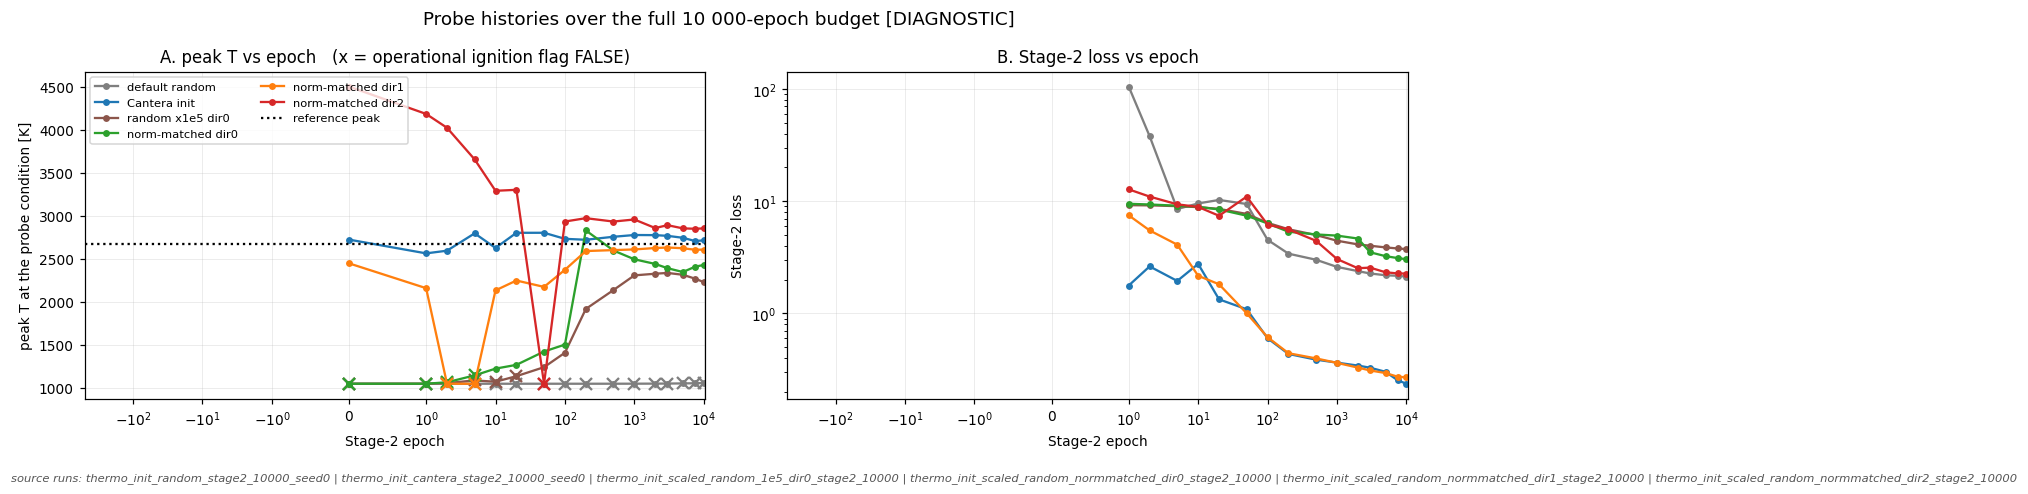

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
COL = {"random10k": "#7f7f7f", "cantera10k": "#1f77b4", "x1e5_dir0_10k": "#8c564b",
       "nm_dir0_10k": "#2ca02c", "nm_dir1_10k": "#ff7f0e", "nm_dir2_10k": "#d62728"}
for k, col, lab in ARMS_10K:
    pr = probe_history(A[k]["run_dir"])
    ax[0].plot(pr["epoch"], pr["peak_T_K"], "o-", ms=3.5, color=col, label=lab)
    ni = pr[~pr["ignites"]]
    ax[0].plot(ni["epoch"], ni["peak_T_K"], "x", ms=8, color=col, mew=1.5)
    ax[1].plot(pr["epoch"], pr["stage2_loss"], "o-", ms=3.5, color=col, label=lab)
ax[0].axhline(REF_PD["training"]["peak"], color="k", ls=":", lw=1.5, label="reference peak")
ax[0].set_ylabel("peak T at the probe condition [K]")
ax[0].set_title("A. peak T vs epoch   (x = operational ignition flag FALSE)")
ax[1].set_yscale("log"); ax[1].set_ylabel("Stage-2 loss")
ax[1].set_title("B. Stage-2 loss vs epoch")
for a_ in ax:
    a_.set_xscale("symlog", linthresh=1)   # keeps epoch 0 visible
    a_.set_xlabel("Stage-2 epoch")
ax[0].legend(fontsize=7.5, ncol=2)
fig.suptitle("Probe histories over the full 10 000-epoch budget [DIAGNOSTIC]", fontsize=12)
fig.tight_layout(); fig_source(fig, *[k for k, *_ in ARMS_10K])
fig.tight_layout(); plt.show()

### Reading the 500 → 10 000 persistence study

Each statement below is produced by the cell above from the recomputed artifacts.

**Default random, 10k.** Remains essentially flat at both representative conditions; no
operational ignition at any probe epoch. Long training does not rescue it.

**Cantera init, 10k.** Reaches the lowest losses of the physical-direction arms and gives a
genuine induction period at both conditions; the held-out plateau still **overshoots**
substantially. Good timing, imperfect amplitude.

**`x1e5` dir0, 10k.** Ignition *timing* improves markedly relative to its 500-epoch
behaviour, yet the full trajectory stays poor: the train/test trajectory MSE remain among
the worst of any arm and the trajectory dips to physically suspicious temperatures.

> **This is the single most important methodological lesson of the section:**
> **a correct ignition delay is not, by itself, evidence of a correct model.** An arm can
> land the argmax-`dT/dt` instant while getting the amplitude, the plateau and the overall
> trajectory badly wrong. Any ranking built on ignition delay alone would rank this arm
> above arms that are visibly better everywhere else.

**Norm-matched dir0, 10k.** Its 500-epoch pathology — heating essentially from `t = 0`,
with no induction period — is substantially repaired by long training: the timing moves
towards the reference. But the global train/test MSE stay poor and the training-condition
peak stays too low. Timing repaired, amplitude not.

**Norm-matched dir1, 10k.** See the printed verdict for whether its favourable 500-epoch
behaviour persisted, how its full-trajectory MSE compares, and whether both representative
conditions show a physical induction period. Whatever the outcome:

> `nm_dir1` is a **nonphysical random direction whose *norm* was deliberately matched to a
> Cantera-scale coefficient vector**. Its performance is a diagnostic result about
> optimization basins. It is **not** a paper reproduction and must never be reported as one.

**Norm-matched dir2, 10k.** Timing improves; the peak remains too hot, most visibly at the
held-out condition; global MSE stays poor.

In [52]:
# Everything the interpretation below asserts, printed from the recomputed objects so the
# prose cannot drift away from the artifacts.
print("PERSISTENCE VERDICT (all values recomputed above)\n" + "=" * 78)
for a, b, label in PERSIST:
    if a == b:
        continue
    p = persistence.loc[label]
    print(f"\n{label}")
    print(f"  test MSE   {p['test_MSE_500']:8.3f} (500)  ->  {p['test_MSE_10k']:8.3f} (10k)"
          f"   [{'improved' if p['test_MSE_10k'] < p['test_MSE_500'] else 'worse'}]")
    print(f"  train MSE  {p['train_MSE_500']:8.3f} (500)  ->  {p['train_MSE_10k']:8.3f} (10k)")
    for pre, role in (("train", "training"), ("held", "held-out")):
        rp, rd_ = REF_PD[role]["peak"], REF_PD[role]["delay_ms"]
        print(f"  [{role:8s}] peak {p[pre+'_peak_T_500']:7.1f} -> {p[pre+'_peak_T_10k']:7.1f} K "
              f"(ref {rp:7.1f})   delay {p[pre+'_delay_500_ms']:7.4f} -> "
              f"{p[pre+'_delay_10k_ms']:7.4f} ms (ref {rd_:7.4f})")
    print(f"  ||theta||  {p['final_thermo_norm_500']:.4g} (500) -> {p['final_thermo_norm_10k']:.4g} (10k)")

print("\n" + "=" * 78)
print("DIRECTION RETAINED FROM INITIALIZATION over 10 000 epochs")
for lab in movement.index:
    r = movement.loc[lab]
    print(f"  {lab:20s} cos(final, init) = {r['cos_final_initial']:+.6f}   "
          f"rel. displacement = {r['relative_displacement']:.3e}   "
          f"cos(init, Cantera) = {r['cos_initial_cantera']:+.4f} -> "
          f"cos(final, Cantera) = {r['cos_final_cantera']:+.4f}")

PERSISTENCE VERDICT (all values recomputed above)

scaled-random x1e5, dir 0
  test MSE      8.122 (500)  ->     6.598 (10k)   [improved]
  train MSE     4.991 (500)  ->     3.757 (10k)
  [training] peak  2137.4 ->  2229.6 K (ref  2669.7)   delay  0.0000 ->  0.1600 ms (ref  0.1419)
  [held-out] peak  2188.7 ->  2324.7 K (ref  2761.6)   delay  0.1782 ->  0.0813 ms (ref  0.0631)
  ||theta||  4.848e+04 (500) -> 4.851e+04 (10k)

norm-matched random, dir 0
  test MSE      7.684 (500)  ->     5.400 (10k)   [improved]
  train MSE     5.061 (500)  ->     3.111 (10k)
  [training] peak  2596.4 ->  2428.8 K (ref  2669.7)   delay  0.0089 ->  0.1643 ms (ref  0.1419)
  [held-out] peak  2710.5 ->  2619.8 K (ref  2761.6)   delay  0.0044 ->  0.0826 ms (ref  0.0631)
  ||theta||  1.712e+05 (500) -> 1.712e+05 (10k)

norm-matched random, dir 1
  test MSE      0.294 (500)  ->     0.207 (10k)   [improved]
  train MSE     0.398 (500)  ->     0.270 (10k)
  [training] peak  2601.1 ->  2606.9 K (ref  2669.7)   d

---
# 19. Ignition-metric audit and grid consistency

Three distinct things are often conflated. They are separated here.

**A. Paper definition (PAPER-EXPLICIT).** "Ignition here is defined as **the point of
maximum temperature rise rate**" (Fig. 8B discussion, following ChemNODE). The paper also
notes the lowest-temperature cases "did not see ignition given the time span of 0.6 ms" —
i.e. non-ignition is decided by the *physics within the window*, and **no numerical
threshold is given**.

**B. Repository operational non-ignition guard (CURRENT IMPLEMENTATION CHOICE).** The repo
function returns the argmax-`dT/dt` time **only if the total temperature rise exceeds
100 K**, otherwise `None`. The 100 K threshold is **our operational safeguard, not a
paper-explicit or universal physical criterion for ignition.** It exists because a
completely flat trajectory still has a mathematical `argmax` of its derivative: without a
guard, the failed model would report a confident, meaningless "ignition delay" at whatever
point numerical noise happened to peak. It decides only whether `argmax dT/dt` is
*meaningful*, never whether a trajectory is *correct*.

**C. Reproduction acceptance gate (CURRENT IMPLEMENTATION CHOICE).** Separately, a
representative-condition gate (peak within 150 K, delay within 25 %) decides whether a run
counts as reproducing the Fig. 7 conditions. That is a pass/fail gate for *our*
reproduction, not a definition of ignition, and §15–§17 show an arm can pass it while being
wrong elsewhere.

In [53]:
import inspect
print(inspect.getsource(ignition_delay))

def ignition_delay(t, T, rise_threshold: float = 100.0):
    """Time of maximum dT/dt, or None if the trajectory never rises enough."""
    T = np.asarray(T, dtype=float)
    t = np.asarray(t, dtype=float)
    if float(T.max() - T[0]) < rise_threshold:
        return None
    return float(t[int(np.argmax(np.gradient(T, t)))])



### Grid consistency — using the genuine dense Cantera reference

An earlier version of this analysis compared a **601-point model** delay against a
**50-point reference** delay, and in one place built a "dense reference" by linearly
interpolating the 50-point Cantera trajectory onto 601 points. Both are wrong:

* mixing grids compares two different resolutions, and
* an interpolated 50-point trajectory is **not** a high-resolution Cantera reference — it
  is the same 50 samples with straight lines drawn between them, and its `argmax dT/dt`
  is an artifact of that interpolation.

Both are corrected here. The repository already ships a **genuine** dense Cantera solve,
`chemkan/data/generated/hydrogen_temperature_20000.npz` — 20 000 points over the same
0.6 ms window, from the same mechanism and tolerances as `hydrogen.npz`. The setup cell
asserts the two agree at their shared instants. Comparisons are now made strictly within
one grid, with the same `ignition_delay` implementation on both members:

* **`model_50` vs `reference_50`** — both at the dataset's native 50 points;
* **`model_dense` vs `reference_dense`** — both on the genuine 20 000-point Cantera grid.

`model_dense vs reference_50` is never reported. No interpolated reference is used anywhere.

> **Why the 20 000-point curve is called "ground truth" rather than "the training data".**
> They are the *same* Cantera solve, differing only in how densely it was sampled:
>
> | | 50-point (`hydrogen.npz`) | 20 000-point (`hydrogen_temperature_20000.npz`) |
> |---|---|---|
> | mechanism | `h2o2.yaml` | `h2o2.yaml` |
> | pressure | 1 atm | 1 atm |
> | solver tolerances | rtol 1e-9, atol 1e-15 | rtol 1e-9, atol 1e-15 |
> | window | 0 – 0.6 ms | 0 – 0.6 ms |
> | saved points | 50 (the **training targets**) | 20 000 (**plotting / ignition timing only**) |
>
> The setup cell asserts the two agree to < 1 K at every shared instant. The dense file is
> **never** used as a training target — the model is still fitted to the 50 points. It is used
> only where 50 points are too coarse to be honest: a 50-point grid quantizes `argmax dT/dt`
> to ~12.2 µs, which is a large fraction of a ~150 µs ignition delay. Using it does **not**
> make the reference "more true"; it removes a sampling artifact from the *comparison*.

In [54]:
def delay_pair(key, T0, phi):
    """Ignition delay within each grid: 50-pt vs 50-pt, and dense vs GENUINE dense Cantera."""
    r50, rdn = reference(T0, phi)[:, -1], reference_T_dense(T0, phi)
    m50 = ignition_delay(t, integrate_arm(A[key], T0, phi)[:, -1])
    mdn = ignition_delay(T_DENSE, dense_T(key, T0, phi))
    R50, Rdn = ignition_delay(t, r50), ignition_delay(T_DENSE, rdn)
    def err(a, b): return np.nan if (a is None or b in (None, 0)) else 100.0 * (a - b) / b
    return dict(arm=key, condition=("training" if phi == 0.9 else "held-out"),
                model_50_ms=np.nan if m50 is None else m50 * 1e3,
                reference_50_ms=R50 * 1e3, err_50_pct=err(m50, R50),
                model_dense_ms=np.nan if mdn is None else mdn * 1e3,
                reference_dense_ms=Rdn * 1e3, err_dense_pct=err(mdn, Rdn))

DELAY_ARMS = [k for k, _, _ in ARMS_10K]
delays = pd.DataFrame([delay_pair(k, T0, phi) for k in DELAY_ARMS for T0, phi, _ in CONDS])
delays = delays.set_index(["condition", "arm"]).sort_index()
print(f"native grid  : {len(t)} points, spacing {np.diff(t).mean()*1e6:.2f} us")
print(f"genuine dense: {len(T_DENSE)} points, spacing {np.diff(T_DENSE).mean()*1e9:.1f} ns "
      f"(Cantera, hydrogen_temperature_20000.npz)")
print("\nquantization of the reference delay itself, 50-point vs genuine dense Cantera:")
for T0, phi, role in CONDS:
    a = ignition_delay(t, reference(T0, phi)[:, -1]) * 1e3
    b = ignition_delay(T_DENSE, reference_T_dense(T0, phi)) * 1e3
    print(f"  [{role:8s}] reference_50 = {a:.4f} ms   reference_dense = {b:.4f} ms   "
          f"(shift {abs(a-b)*1e3:.1f} us, one 50-pt sample = {np.diff(t).mean()*1e6:.1f} us)")
delays

native grid  : 50 points, spacing 12.24 us
genuine dense: 20000 points, spacing 30.0 ns (Cantera, hydrogen_temperature_20000.npz)

quantization of the reference delay itself, 50-point vs genuine dense Cantera:
  [training] reference_50 = 0.1469 ms   reference_dense = 0.1419 ms   (shift 5.0 us, one 50-pt sample = 12.2 us)
  [held-out] reference_50 = 0.0735 ms   reference_dense = 0.0631 ms   (shift 10.3 us, one 50-pt sample = 12.2 us)


model_50_ms  reference_50_ms  err_50_pct  model_dense_ms  reference_dense_ms  err_dense_pct
condition arm                                                                                                       
held-out  cantera10k          0.0612           0.0735    -16.6667          0.0516              0.0631       -18.2510
          nm_dir0_10k         0.0735           0.0735      0.0000          0.0826              0.0631        30.7985
          nm_dir1_10k         0.0735           0.0735      0.0000          0.0719              0.0631        13.8308
          nm_dir2_10k         0.0612           0.0735    -16.6667          0.0686              0.0631         8.6502
          random10k              NaN           0.0735         NaN             NaN              0.0631            NaN
          x1e5_dir0_10k       0.0735           0.0735      0.0000          0.0813              0.0631        28.7548
training  cantera10k          0.1469           0.1469      0.0000          0.1382              0.1419        -2.6216
          nm_dir0_10k         0.1592           0.1469      8.3333          0.1643              0.1419        15.7928
          nm_dir1_10k         0.1469           0.1469      0.0000          0.1573              0.1419        10.8457
          nm_dir2_10k         0.1469           0.1469      0.0000          0.1511              0.1419         6.4482
          random10k              NaN           0.1469         NaN             NaN              0.1419            NaN
          x1e5_dir0_10k       0.1469           0.1469      0.0000          0.1600              0.1419        12.7484

---
# 20. Full train / test normalized trajectory MSE

Recomputed for every arm and **both** splits with the repository evaluator
(`evaluate_hydrogen`, Eq. 18 with train-only min–max statistics). The per-run
`metrics.json` files are read only afterwards, as a consistency check.

In [55]:
MSE_ARMS = [k for k in ("random10k", "cantera10k", "x1e5_dir0_10k", "nm_dir0_10k",
                        "nm_dir1_10k", "nm_dir2_10k", "cantera500", "x1e4_dir0",
                        "x1e5_dir0", "nm_dir0", "nm_dir1", "nm_dir2") if k in A]
rows = []
for k in MSE_ARMS:
    ck = str(A[k]["run_dir"] / "checkpoint_final.pt")
    r = {"arm": k, "stage2_epochs": (A[k]["config"].get("epochs") or {}).get("stage2")}
    for split in ("train", "test"):
        r[f"{split}_trajectory_MSE"] = (_MSE[k][split] if k in _MSE
                                        else evaluate_hydrogen(ck, split, "cpu")["mse"])
    mp = A[k]["run_dir"] / "metrics.json"
    if mp.exists():
        mj = json.loads(mp.read_text())
        r["metrics.json train"] = mj.get("train_mse")
        r["metrics.json test"] = mj.get("test_mse")
    rows.append(r)
mse_table = pd.DataFrame(rows).set_index("arm")
assert np.isfinite(mse_table[["train_trajectory_MSE", "test_trajectory_MSE"]].to_numpy(float)).all(), \
    "non-finite trajectory MSE"
if {"metrics.json train", "metrics.json test"} <= set(mse_table.columns):
    rec = mse_table[["train_trajectory_MSE", "test_trajectory_MSE"]].to_numpy(float)
    sto = mse_table[["metrics.json train", "metrics.json test"]].to_numpy(float)
    ok = np.isfinite(sto)
    print(f"recomputed values agree with the stored metrics.json wherever it exists: "
          f"{np.allclose(rec[ok], sto[ok], rtol=1e-6)}")
mse_table.sort_values("test_trajectory_MSE")

recomputed values agree with the stored metrics.json wherever it exists: True


,stage2_epochs,train_trajectory_MSE,test_trajectory_MSE,metrics.json train,metrics.json test
arm,,,,,
nm_dir1_10k,10000,0.2697,0.2071,0.2697,0.2071
cantera10k,10000,0.2368,0.2381,0.2368,0.2381
nm_dir1,500,0.3983,0.2937,0.3983,0.2937
cantera500,500,0.3876,0.4093,0.3876,0.4093
random10k,10000,2.1227,3.1556,2.1227,3.1556
nm_dir2_10k,10000,2.2576,3.9029,2.2576,3.9029
nm_dir0_10k,10000,3.1108,5.3996,3.1108,5.3996
x1e4_dir0,500,3.8204,5.8929,3.8204,5.8929
x1e5_dir0_10k,10000,3.7567,6.5977,3.7567,6.5977


---
# 21. Master comparison table — 10 000 epochs

The primary summary of the investigation, at the long budget. Every value is computed
above from a checkpoint, config or probe CSV; ignition delays use the **genuine dense
Cantera reference**.

In [56]:
CATEGORY = {"random10k": "DIAGNOSTIC control (default init)",
            "cantera10k": "DIAGNOSTIC treatment (physical direction)",
            "x1e5_dir0_10k": "DIAGNOSTIC ablation (scale, dir 0)",
            "nm_dir0_10k": "DIAGNOSTIC ablation (direction 0)",
            "nm_dir1_10k": "DIAGNOSTIC ablation (direction 1)",
            "nm_dir2_10k": "DIAGNOSTIC ablation (direction 2)"}
# Representative-condition gate, reused from the reproduction notebook's tolerances.
PEAK_TOL_K, DELAY_TOL_REL = 150.0, 0.25

rows = []
for key, _, lab in ARMS_10K:
    pr, cfg = probe_history(A[key]["run_dir"]), A[key]["config"]
    ti = cfg.get("thermo_init") or {}
    mv = movement.loc[lab]
    row = dict(arm=key, category=CATEGORY[key],
               stage2_epochs=(cfg.get("epochs") or {}).get("stage2"),
               thermo_init_type=ti.get("thermo_init", "random"),
               thermo_direction_seed=ti.get("thermo_linear_init_seed"),
               initial_thermo_norm=mv["initial_norm"], final_thermo_norm=mv["final_norm"],
               relative_thermo_displacement=mv["relative_displacement"],
               cos_final_initial=mv["cos_final_initial"],
               cos_final_cantera=mv["cos_final_cantera"],
               final_stage2_loss=float(pr["stage2_loss"].iloc[-1]),
               train_trajectory_MSE=mse_table.loc[key, "train_trajectory_MSE"],
               test_trajectory_MSE=mse_table.loc[key, "test_trajectory_MSE"],
               operational_ignition_history=CLASS[key])
    gate = []
    for (T0, phi, role), pre in zip(CONDS, ("train", "held")):
        d = delays.loc[(role, key)]
        Td = dense_T(key, T0, phi)
        rpk = float(reference_T_dense(T0, phi).max())
        row[f"{pre}_peak_T_K"] = float(Td.max())
        row[f"{pre}_peak_error_K"] = float(Td.max()) - rpk
        row[f"{pre}_ignition_delay_dense_s"] = (np.nan if np.isnan(d["model_dense_ms"])
                                                else d["model_dense_ms"] / 1e3)
        row[f"{pre}_delay_error_dense_pct"] = d["err_dense_pct"]
        gate.append(abs(float(Td.max()) - rpk) <= PEAK_TOL_K
                    and np.isfinite(d["err_dense_pct"])
                    and abs(d["err_dense_pct"]) / 100.0 <= DELAY_TOL_REL)
    row["gate_training"], row["gate_held_out"] = gate
    row["gate_both"] = bool(gate[0] and gate[1])
    rows.append(row)

master = pd.DataFrame(rows).set_index("arm")
out = TABLES / "hydrogen_thermo_initialization_10k_comparison.csv"
master.to_csv(out); print("saved", rel(out))
print(f"representative-condition gate: |peak error| <= {PEAK_TOL_K:.0f} K AND "
      f"|delay error| <= {DELAY_TOL_REL:.0%} (dense grid, genuine Cantera reference)")
master

saved results/reproduction/chemkan/hydrogen/tables/hydrogen_thermo_initialization_10k_comparison.csv
representative-condition gate: |peak error| <= 150 K AND |delay error| <= 25% (dense grid, genuine Cantera reference)


,category,stage2_epochs,thermo_init_type,thermo_direction_seed,initial_thermo_norm,final_thermo_norm,relative_thermo_displacement,cos_final_initial,cos_final_cantera,final_stage2_loss,train_trajectory_MSE,test_trajectory_MSE,operational_ignition_history,train_peak_T_K,train_peak_error_K,train_ignition_delay_dense_s,train_delay_error_dense_pct,held_peak_T_K,held_peak_error_K,held_ignition_delay_dense_s,held_delay_error_dense_pct,gate_training,gate_held_out,gate_both
arm,,,,,,,,,,,,,,,,,,,,,,,,
random10k,DIAGNOSTIC control (default init),10000,random,NaN,0.4848,43.9749,9.0780e+01,-0.0719,-0.3360,2.1272,2.1227,3.1556,never_ignites,1058.0077,-1611.7100,NaN,NaN,1159.5980,-1601.9863,NaN,NaN,False,False,False
cantera10k,DIAGNOSTIC treatment (physical direction),10000,cantera,NaN,171227.5497,171227.1274,1.5768e-04,1.0000,1.0000,0.2366,0.2368,0.2381,ignites_initially_and_persists,2714.0945,44.3767,0.0001,-2.6216,3029.1331,267.5487,5.1603e-05,-18.2510,True,False,False
x1e5_dir0_10k,"DIAGNOSTIC ablation (scale, dir 0)",10000,scaled-random,0.0,48482.6634,48511.2350,1.0119e-03,1.0000,-0.3129,3.7473,3.7567,6.5977,ignition_emerges_and_persists,2229.6069,-440.1108,0.0002,12.7484,2324.7209,-436.8634,8.1274e-05,28.7548,False,False,False
nm_dir0_10k,DIAGNOSTIC ablation (direction 0),10000,scaled-random,0.0,171227.5980,171231.9278,2.0163e-04,1.0000,-0.3129,3.0426,3.1108,5.3996,ignition_emerges_and_persists,2428.8157,-240.9021,0.0002,15.7928,2619.7932,-141.7911,8.2564e-05,30.7985,False,False,False
nm_dir1_10k,DIAGNOSTIC ablation (direction 1),10000,scaled-random,1.0,171227.5224,171227.5308,1.0115e-06,1.0000,0.3169,0.2698,0.2697,0.2071,intermittent,2606.8530,-62.8647,0.0002,10.8457,2804.9521,43.3678,7.1854e-05,13.8308,True,True,True
nm_dir2_10k,DIAGNOSTIC ablation (direction 2),10000,scaled-random,2.0,171227.4231,171228.4328,7.3656e-05,1.0000,0.1889,2.2674,2.2576,3.9029,intermittent,2853.0098,183.2920,0.0002,6.4482,3104.2229,342.6386,6.8583e-05,8.6502,False,False,False


In [57]:
# The columns that carry the argument.
master[["stage2_epochs", "thermo_init_type", "thermo_direction_seed", "initial_thermo_norm",
        "relative_thermo_displacement", "cos_final_initial", "cos_final_cantera",
        "train_trajectory_MSE", "test_trajectory_MSE",
        "train_peak_error_K", "train_delay_error_dense_pct",
        "held_peak_error_K", "held_delay_error_dense_pct",
        "gate_training", "gate_held_out", "gate_both", "operational_ignition_history"]]

,stage2_epochs,thermo_init_type,thermo_direction_seed,initial_thermo_norm,relative_thermo_displacement,cos_final_initial,cos_final_cantera,train_trajectory_MSE,test_trajectory_MSE,train_peak_error_K,train_delay_error_dense_pct,held_peak_error_K,held_delay_error_dense_pct,gate_training,gate_held_out,gate_both,operational_ignition_history
arm,,,,,,,,,,,,,,,,,
random10k,10000,random,NaN,0.4848,9.0780e+01,-0.0719,-0.3360,2.1227,3.1556,-1611.7100,NaN,-1601.9863,NaN,False,False,False,never_ignites
cantera10k,10000,cantera,NaN,171227.5497,1.5768e-04,1.0000,1.0000,0.2368,0.2381,44.3767,-2.6216,267.5487,-18.2510,True,False,False,ignites_initially_and_persists
x1e5_dir0_10k,10000,scaled-random,0.0,48482.6634,1.0119e-03,1.0000,-0.3129,3.7567,6.5977,-440.1108,12.7484,-436.8634,28.7548,False,False,False,ignition_emerges_and_persists
nm_dir0_10k,10000,scaled-random,0.0,171227.5980,2.0163e-04,1.0000,-0.3129,3.1108,5.3996,-240.9021,15.7928,-141.7911,30.7985,False,False,False,ignition_emerges_and_persists
nm_dir1_10k,10000,scaled-random,1.0,171227.5224,1.0115e-06,1.0000,0.3169,0.2697,0.2071,-62.8647,10.8457,43.3678,13.8308,True,True,True,intermittent
nm_dir2_10k,10000,scaled-random,2.0,171227.4231,7.3656e-05,1.0000,0.1889,2.2576,3.9029,183.2920,6.4482,342.6386,8.6502,False,False,False,intermittent


In [58]:
# Gate and equal-norm verdict, from the master table.
nm10 = master.loc[[k for k in ("nm_dir0_10k", "nm_dir1_10k", "nm_dir2_10k") if k in master.index]]
print("EQUAL-NORM DIRECTIONS AT 10 000 EPOCHS -- do they still differ?\n" + "=" * 78)
print(f"  initial norms identical to "
      f"{nm10['initial_thermo_norm'].std()/nm10['initial_thermo_norm'].mean():.2e} relative spread")
print(f"  test MSE spread  : {nm10['test_trajectory_MSE'].min():.3f} .. "
      f"{nm10['test_trajectory_MSE'].max():.3f}   "
      f"(x{nm10['test_trajectory_MSE'].max()/nm10['test_trajectory_MSE'].min():.1f})")
print(f"  held peak error  : {nm10['held_peak_error_K'].min():+.0f} .. "
      f"{nm10['held_peak_error_K'].max():+.0f} K")
print(f"  gate(both conds) : {dict(zip(nm10.index, nm10['gate_both']))}")
print()
print(f"Best arm by TEST trajectory MSE : {master['test_trajectory_MSE'].idxmin()} "
      f"({master['test_trajectory_MSE'].min():.4f})")
print(f"Best arm by TRAIN trajectory MSE: {master['train_trajectory_MSE'].idxmin()} "
      f"({master['train_trajectory_MSE'].min():.4f})")
print(f"Arms passing BOTH representative gates : "
      f"{list(master.index[master['gate_both']]) or 'none'}")
print(f"Arms passing the held-out gate only    : "
      f"{list(master.index[master['gate_held_out'] & ~master['gate_both']]) or 'none'}")
print(f"Arms passing the training gate only    : "
      f"{list(master.index[master['gate_training'] & ~master['gate_both']]) or 'none'}")
print()
print("Counter-example check -- does any arm have GOOD timing but a BAD trajectory?")
for k in master.index:
    e = master.loc[k, "train_delay_error_dense_pct"]
    if np.isfinite(e) and abs(e) <= 25.0:
        print(f"  {k:16s} train delay error {e:+6.1f} %   "
              f"train MSE {master.loc[k,'train_trajectory_MSE']:7.3f}   "
              f"test MSE {master.loc[k,'test_trajectory_MSE']:7.3f}")

EQUAL-NORM DIRECTIONS AT 10 000 EPOCHS -- do they still differ?
  initial norms identical to 5.12e-07 relative spread
  test MSE spread  : 0.207 .. 5.400   (x26.1)
  held peak error  : -142 .. +343 K
  gate(both conds) : {'nm_dir0_10k': False, 'nm_dir1_10k': True, 'nm_dir2_10k': False}

Best arm by TEST trajectory MSE : nm_dir1_10k (0.2071)
Best arm by TRAIN trajectory MSE: cantera10k (0.2368)
Arms passing BOTH representative gates : ['nm_dir1_10k']
Arms passing the held-out gate only    : none
Arms passing the training gate only    : ['cantera10k']

Counter-example check -- does any arm have GOOD timing but a BAD trajectory?
  cantera10k       train delay error   -2.6 %   train MSE   0.237   test MSE   0.238
  x1e5_dir0_10k    train delay error  +12.7 %   train MSE   3.757   test MSE   6.598
  nm_dir0_10k      train delay error  +15.8 %   train MSE   3.111   test MSE   5.400
  nm_dir1_10k      train delay error  +10.8 %   train MSE   0.270   test MSE   0.207
  nm_dir2_10k      train d

### Secondary table — the 500-epoch snapshot

Kept because it tells the early-training story that §15 measures against; superseded by the
table above for every conclusion about final model quality.

In [59]:
# Secondary table: the 500-epoch snapshot, kept because it tells the early-training story.
sec = mse_table.loc[[k for k in ("cantera500", "x1e4_dir0", "x1e5_dir0",
                                 "nm_dir0", "nm_dir1", "nm_dir2") if k in mse_table.index],
                    ["stage2_epochs", "train_trajectory_MSE", "test_trajectory_MSE"]].copy()
sec["operational_ignition_history_500"] = [CLASS[k] for k in sec.index]
sec

,stage2_epochs,train_trajectory_MSE,test_trajectory_MSE,operational_ignition_history_500
arm,,,,
cantera500,500,0.3876,0.4093,ignites_initially_and_persists
x1e4_dir0,500,3.8204,5.8929,never_ignites
x1e5_dir0,500,4.9912,8.1217,ignition_emerges_and_persists
nm_dir0,500,5.0613,7.6838,ignition_emerges_and_persists
nm_dir1,500,0.3983,0.2937,intermittent
nm_dir2,500,4.4284,7.2689,intermittent


In [60]:
# Assemble the synthesis from the recomputed objects so the wording cannot drift.
Tshare = float(per_state["held-out"][-1] / per_state["held-out"].sum())
print(f"temperature share of held-out per-state MSE ........ {Tshare:.1%}")
print(f"random 10k raises the operational flag ever ....... "
      f"{bool(probe_history(A['random10k']['run_dir'])['ignites'].any())}")
print(f"linear-branch deficit at the heat-release peak .... "
      + ", ".join(f"{r}: {v:.0f}x" for r, v in localization['deficit_factor_linear'].items()))
print(f"full Eq.15 path deficit (linear + KAN_cor) ........ "
      + ", ".join(f"{r}: {v:.0f}x" for r, v in localization['deficit_factor_full'].items()))
print(f"KAN_cor share of the full thermo path at the peak . "
      + ", ".join(f"{r}: {v:.2%}" for r, v in localization['correction_share_of_full'].items()))
print(f"species rate relative L2 (model vs reference) ..... "
      + ", ".join(f"{r}: {v:.2f}" for r, v in localization['species_rate_relL2'].items()))
print()
print(f"10k test MSE spread across arms ................... "
      f"{master['test_trajectory_MSE'].min():.3f} .. {master['test_trajectory_MSE'].max():.3f}"
      f"  (x{master['test_trajectory_MSE'].max()/master['test_trajectory_MSE'].min():.1f})")
print(f"every 500->10k arm improved its test MSE .......... "
      f"{bool((persistence['test_MSE_10k'] <= persistence['test_MSE_500']).all())}")
print(f"equal-norm directions still differ at 10k ......... "
      f"x{nm10['test_trajectory_MSE'].max()/nm10['test_trajectory_MSE'].min():.1f} in test MSE")
print(f"arms passing BOTH representative gates ............ "
      f"{list(master.index[master['gate_both']]) or 'none'}")
print(f"max |cos(theta_final, theta_0) - 1| over large arms "
      f"{float((1 - movement.loc[movement['initial_norm'] > 1e3, 'cos_final_initial']).abs().max()):.2e}")
print(f"max relative theta displacement over large arms ... "
      f"{float(movement.loc[movement['initial_norm'] > 1e3, 'relative_displacement'].max()):.2e}")
print(f"kinetic-core relative displacement, same arms ..... "
      f"{blocks.loc[movement.index[movement['initial_norm'] > 1e3], 'kinetic_rel_disp'].min():.2f}"
      f" .. {blocks.loc[movement.index[movement['initial_norm'] > 1e3], 'kinetic_rel_disp'].max():.2f}")
_large = movement["initial_norm"] > 1e3
_dc = (movement["cos_final_cantera"] - movement["cos_initial_cantera"]).abs()
print(f"cos(theta, theta_Cantera) change, LARGE-init arms  max {float(_dc[_large].max()):.2e}"
      f"  -> rotated toward the physical direction? {bool(_dc[_large].max() > 0.01)}")
print(f"cos(theta, theta_Cantera) change, default random   {float(_dc[~_large].max()):.2e}"
      f"  (it rotates freely, but away from Cantera, ending at "
      f"{float(movement.loc[~_large, 'cos_final_cantera'].iloc[0]):+.4f})")

temperature share of held-out per-state MSE ........ 94.4%
random 10k raises the operational flag ever ....... False
linear-branch deficit at the heat-release peak .... training: 134x, held-out: 145x
full Eq.15 path deficit (linear + KAN_cor) ........ training: 134x, held-out: 145x
KAN_cor share of the full thermo path at the peak . training: 0.12%, held-out: 0.14%
species rate relative L2 (model vs reference) ..... training: 1.52, held-out: 1.47

10k test MSE spread across arms ................... 0.207 .. 6.598  (x31.9)
every 500->10k arm improved its test MSE .......... True
equal-norm directions still differ at 10k ......... x26.1 in test MSE
arms passing BOTH representative gates ............ ['nm_dir1_10k']
max |cos(theta_final, theta_0) - 1| over large arms 3.38e-07
max relative theta displacement over large arms ... 1.01e-03
kinetic-core relative displacement, same arms ..... 0.22 .. 1.26
cos(theta, theta_Cantera) change, LARGE-init arms  max 1.08e-04  -> rotated toward the phy

---
# 22. Base-activation architecture sensitivity: N=5/base-OFF vs N=4/base-ON

> ## DIAGNOSTIC / ABLATION — NOT PAPER REPRODUCTION METHODOLOGY

Everything before this section used one architecture: `hidden_dim=3, n_mu=3, num_basis=5,
use_base_act=False`. That configuration reproduces the paper's reported **344** parameters —
but it does so by **dropping** a term the paper's Eq. 11 explicitly includes: the learnable
Swish/base coefficient on every KAN edge. This section tests the alternative reading.

### What is paper-explicit and what is inferred

| item | status |
|---|---|
| Eq. 11 contains `N` RBF coefficients **plus one learnable base coefficient** per edge | **PAPER-EXPLICIT** |
| hydrogen hidden nodes = 3 | **PAPER-EXPLICIT** |
| hydrogen `n_mu` = 3 | **PAPER-EXPLICIT** |
| hydrogen total parameters = 344 | **PAPER-EXPLICIT** |
| hydrogen grid size `N` | **NOT STATED** in the paper |

Two configurations reproduce 344 exactly — and, as §1 and `test_model.py` verify, they agree
**block for block** (150 / 135 / 9 / 50), so they are indistinguishable from the count alone:

| | `num_basis` | `use_base_act` | params | status |
|---|---|---|---|---|
| **Interpretation A** | 5 | OFF | 344 | INFERRED — historical count-matching reading; drops the Eq. 11 base term |
| **Interpretation B** | 4 | ON | 344 | INFERRED — Eq. 11-aligned reading; keeps the base term |

**Neither `N` is paper-stated.** Interpretation A's earlier results remain a completed, valid
reading; nothing here relabels them. Interpretation B is the one the rest of this section runs.

### Controlled design

A fresh Stage-1 kinetic core was trained under Interpretation B (the base-OFF Stage-1 cannot
be reused — the architecture differs, and `--stage1-from` refuses the mismatch). All six
Stage-2 arms then start from that **one** checkpoint, with identical seed (0), optimizer,
learning rate, solver, tolerances, `direct_autograd` backend, loss, PINN term,
normalization, dataset and 10 000-epoch budget. Only the `thermo.linear` initialization
differs — the same six arms as the base-OFF study. A 33-check fairness verifier
(`verify_base_on_matrix.py`) confirmed this after the runs.

Two additions were made for this study, both behaviour-neutral and tested: an **NFE counter**
(a forward hook that records ODE right-hand-side evaluations per epoch) and an **immutable
epoch-500 snapshot** inside each 10k run, so the 500-epoch comparison needs no duplicate jobs.

In [61]:
# Recompute EVERY cell of the matrix from checkpoints / probes / histories (no cached numbers).
import matplotlib
_bk = matplotlib.get_backend()
import analyze_base_on_matrix as ABM
matplotlib.use(_bk)                       # the module's CLI forces Agg; restore inline

_t0 = time.perf_counter()
MX, MX_CURVES, MX_PROBES, MX_HISTS, MXD = ABM.compute_matrix(verbose=False)
MX = MX[MX.available].copy()
S1CMP = ABM.stage1_comparison(MXD)
print(f"matrix recomputed: {len(MX)} (interpretation, arm, budget) cells in "
      f"{time.perf_counter()-_t0:.0f} s")
print("base-OFF default random has NO 500-epoch checkpoint (that arm was only ever run "
      "to 10k); its 500-epoch cell is therefore absent, not invented.")

matrix recomputed: 23 (interpretation, arm, budget) cells in 53 s
base-OFF default random has NO 500-epoch checkpoint (that arm was only ever run to 10k); its 500-epoch cell is therefore absent, not invented.


In [62]:
# Secondary question: does the base pathway change Stage-1 species learning?
print("Stage-1 (kinetic core, observed T supplied), one run per interpretation:\n")
display(S1CMP.T)
_a, _b = S1CMP.loc["base-OFF (N=5)"], S1CMP.loc["base-ON (N=4)"]
print(f"final Stage-1 loss      : {_a.stage1_final_loss:.4f} (A) vs {_b.stage1_final_loss:.4f} (B)"
      f"  -> {100*(_b.stage1_final_loss/_a.stage1_final_loss-1):+.1f} %")
print(f"open-loop species MSE   : {_a['open_loop_species_mse_1050_0.9']:.5f} (A) vs "
      f"{_b['open_loop_species_mse_1050_0.9']:.5f} (B)  at 1050 K / phi 0.9")
print(f"Stage-1 wall time       : {_a.stage1_wall_hours:.2f} h (A) vs {_b.stage1_wall_hours:.2f} h (B)"
      f"  -> x{_b.stage1_wall_hours/_a.stage1_wall_hours:.2f}")

Stage-1 (kinetic core, observed T supplied), one run per interpretation:



interpretation,base-OFF (N=5),base-ON (N=4)
architecture,"{""hidden_dim"": 3, ""num_basis"": 5, ""n_mu"": 3, ""...","{""hidden_dim"": 3, ""num_basis"": 4, ""n_mu"": 3, ""..."
n_params,344,344
stage1_final_loss,0.3283,0.3149
stage1_min_loss,0.3283,0.3149
stage1_wall_hours,0.9017,1.4269
stage1_median_nfe,NaN,716.0
stage1_sha256,73347c44a5ff,6b25dfcf4930
open_loop_species_mse_1050_0.9,0.0063,0.0066


final Stage-1 loss      : 0.3283 (A) vs 0.3149 (B)  -> -4.1 %
open-loop species MSE   : 0.00625 (A) vs 0.00656 (B)  at 1050 K / phi 0.9
Stage-1 wall time       : 0.90 h (A) vs 1.43 h (B)  -> x1.58


In [63]:
def _view(budget):
    v = MX[MX.budget == budget].sort_values(["arm", "interpretation"])
    cols = ["label", "interpretation", "train_mse", "test_mse", "train_dominant_state",
            "train_T_share", "train_peak_error_K", "train_delay_error_pct",
            "held_peak_error_K", "held_delay_error_pct", "train_gate", "held_gate", "gate_both"]
    return v[cols].rename(columns={"interpretation": "interp", "train_dominant_state": "dominant",
                                   "train_T_share": "T share", "train_peak_error_K": "train ΔT_peak",
                                   "train_delay_error_pct": "train Δτ %", "held_peak_error_K": "held ΔT_peak",
                                   "held_delay_error_pct": "held Δτ %"}).set_index(["label", "interp"])

print("SIX-ARM COMPARISON AT 500 EPOCHS  (base-ON = in-run snapshot; base-OFF = separate 500-epoch runs)")
display(_view(500).round(3))
print("\nSIX-ARM COMPARISON AT 10 000 EPOCHS  (final checkpoints)")
display(_view(10000).round(3))
print("\nMSE = Eq. 18 normalized trajectory MSE (SUM over 50 times, mean over states and cases)."
      "\n'dominant' = state carrying the largest Eq. 18 share on the train split."
      "\nΔτ uses the repo ignition definition on the GENUINE 20 000-point Cantera grid for both sides."
      f"\ngate: |ΔT_peak| <= {ABM.PEAK_TOL_K:.0f} K and |Δτ| <= {ABM.DELAY_TOL_REL:.0%} at that condition.")

SIX-ARM COMPARISON AT 500 EPOCHS  (base-ON = in-run snapshot; base-OFF = separate 500-epoch runs)


train_mse  test_mse dominant  T share  train ΔT_peak  train Δτ %  held ΔT_peak  held Δτ % train_gate held_gate gate_both
label             interp                                                                                                                                  
Cantera init      base-OFF (N=5)      0.388     0.409      HO2    0.085         86.075       7.336       289.580     15.875       True     False     False
                  base-ON (N=4)       0.456     0.348      HO2    0.080         -0.688       6.660       165.536      7.700       True     False     False
norm-matched dir0 base-OFF (N=5)      5.061     7.684      H2O    0.121        -73.337     -93.700       -51.095    -93.061      False     False     False
                  base-ON (N=4)       4.305     7.365       O2    0.049         41.732     -60.994      -137.753    -72.338      False     False     False
norm-matched dir1 base-OFF (N=5)      0.398     0.294      HO2    0.053        -68.619      10.846       154.052     34.886       True     False     False
                  base-ON (N=4)       1.391     1.377       OH    0.181        173.753      75.518        93.244    181.702      False     False     False
norm-matched dir2 base-OFF (N=5)      4.428     7.269      H2O    0.062        262.714     -31.332       525.246    -24.097      False     False     False
                  base-ON (N=4)      18.986    25.082        T    0.836       3663.569     -82.600      3692.333    -84.316      False     False     False
default random    base-ON (N=4)       2.283     3.288        T    0.827      -1619.390         NaN     -1611.196        NaN      False     False     False
random x1e5 dir0  base-OFF (N=5)      4.991     8.122      H2O    0.160       -532.309    -100.000      -572.868    182.272      False     False     False
                  base-ON (N=4)       4.902     8.432       O2    0.109       -563.971     -65.624      -726.307    -78.470      False     False     False


SIX-ARM COMPARISON AT 10 000 EPOCHS  (final checkpoints)


train_mse   test_mse dominant  T share  train ΔT_peak  train Δτ %  held ΔT_peak  held Δτ % train_gate held_gate gate_both
label             interp                                                                                                                                   
Cantera init      base-OFF (N=5)      0.237      0.238      HO2    0.086         44.377      -2.622       267.549    -18.251       True     False     False
                  base-ON (N=4)      19.691     10.069        T    0.226       1215.748      -9.239      1547.899    145.865      False     False     False
norm-matched dir0 base-OFF (N=5)      3.111      5.400      H2O    0.015       -240.902      15.793      -141.791     30.798      False     False     False
                  base-ON (N=4)    1566.374     25.853      HO2    0.001      -1174.416     197.040     -1166.901    758.413      False     False     False
norm-matched dir1 base-OFF (N=5)      0.270      0.207      HO2    0.025        -62.865      10.846        43.368     13.831       True      True      True
                  base-ON (N=4)       0.310      0.209      HO2    0.038       -112.834      22.981        -7.119     61.692       True     False     False
norm-matched dir2 base-OFF (N=5)      2.258      3.903      H2O    0.046        183.292       6.448       342.639      8.650      False     False     False
                  base-ON (N=4)      42.563     41.209        T    0.912       4902.221     -93.002      5084.565    -89.354      False     False     False
default random    base-OFF (N=5)      2.123      3.156        T    0.880      -1611.710         NaN     -1601.986        NaN      False     False     False
                  base-ON (N=4)       2.139      3.146        T    0.873      -1611.212         NaN     -1601.668        NaN      False     False     False
random x1e5 dir0  base-OFF (N=5)      3.757      6.598      H2O    0.080       -440.111      12.748      -436.863     28.755      False     False     False
                  base-ON (N=4)   13188.507  11482.902      HO2    0.000       2187.724     -99.937      1726.656    -47.671      False     False     False


MSE = Eq. 18 normalized trajectory MSE (SUM over 50 times, mean over states and cases).
'dominant' = state carrying the largest Eq. 18 share on the train split.
Δτ uses the repo ignition definition on the GENUINE 20 000-point Cantera grid for both sides.
gate: |ΔT_peak| <= 150 K and |Δτ| <= 25% at that condition.


In [64]:
# Stability, runtime and solver work at the full budget.
v = MX[MX.budget == 10000].sort_values(["arm", "interpretation"])
stab = v[["label", "interpretation", "stability_min_loss", "stability_min_epoch",
          "stability_final_loss", "stability_final_over_min", "stability_stable",
          "wall_hours", "median_s_per_epoch", "median_nfe", "total_nfe",
          "train_negative_species_frac"]]
stab = stab.rename(columns={"interpretation": "interp", "stability_min_loss": "min loss",
                            "stability_min_epoch": "@epoch", "stability_final_loss": "final loss",
                            "stability_final_over_min": "final/min", "stability_stable": "stable",
                            "wall_hours": "wall h", "median_s_per_epoch": "s/epoch",
                            "median_nfe": "median NFE/ep", "total_nfe": "total NFE",
                            "train_negative_species_frac": "neg. Y frac"})
display(stab.set_index(["label", "interp"]).round(3))
_on = v[v.interpretation.str.startswith("base-ON")]; _off = v[v.interpretation.str.startswith("base-OFF")]
print(f"stable arms: base-OFF {int(_off.stability_stable.sum())}/{len(_off)}   "
      f"base-ON {int(_on.stability_stable.sum())}/{len(_on)}   "
      "(stable := final Stage-2 loss < 2x its own minimum)")
print(f"wall time, base-ON / base-OFF, per arm: "
      + ", ".join(f"{a}: x{b/c:.1f}" for a, b, c in zip(_on.label, _on.wall_hours, _off.wall_hours)))
print("'neg. Y frac' = fraction of predicted species values that are NEGATIVE on the train split "
      "(unphysical); note it is non-zero for every arm of BOTH interpretations.")

min loss  @epoch  final loss  final/min stable  wall h  s/epoch  median NFE  neg. Y frac
label             interp                                                                                                  
Cantera init      base-OFF (N=5)     0.231  9913.0       0.237      1.025   True   1.695    0.596         NaN        0.120
                  base-ON (N=4)      0.362  3041.0      19.681     54.353  False   2.639    0.663       860.0        0.273
norm-matched dir0 base-OFF (N=5)     3.039  9985.0       3.043      1.001   True   1.591    0.610         NaN        0.267
                  base-ON (N=4)      3.903  1446.0    1566.960    401.427  False   2.312    0.679       806.0        0.217
norm-matched dir1 base-OFF (N=5)     0.270  8170.0       0.270      1.001   True   1.474    0.557         NaN        0.093
                  base-ON (N=4)      0.298  8795.0       0.335      1.127   True   3.385    1.184      1214.0        0.110
norm-matched dir2 base-OFF (N=5)     2.246  9971.0       2.267      1.010   True   1.863    0.672         NaN        0.143
                  base-ON (N=4)     17.370  8211.0      42.564      2.450  False   3.020    0.974      1160.0        0.242
default random    base-OFF (N=5)     2.123  9998.0       2.127      1.002   True   1.186    0.410         NaN        0.120
                  base-ON (N=4)      2.129  9914.0       2.143      1.006   True   8.758    3.156      4205.0        0.064
random x1e5 dir0  base-OFF (N=5)     3.746  9986.0       3.747      1.000   True   3.223    1.261         NaN        0.277
                  base-ON (N=4)      4.433  8217.0   13188.508   2975.163  False   3.561    1.257      1448.0        0.343

stable arms: base-OFF 6/6   base-ON 2/6   (stable := final Stage-2 loss < 2x its own minimum)
wall time, base-ON / base-OFF, per arm: Cantera init: x1.6, norm-matched dir0: x1.5, norm-matched dir1: x2.3, norm-matched dir2: x1.6, default random: x7.4, random x1e5 dir0: x1.1
'neg. Y frac' = fraction of predicted species values that are NEGATIVE on the train split (unphysical); note it is non-zero for every arm of BOTH interpretations.


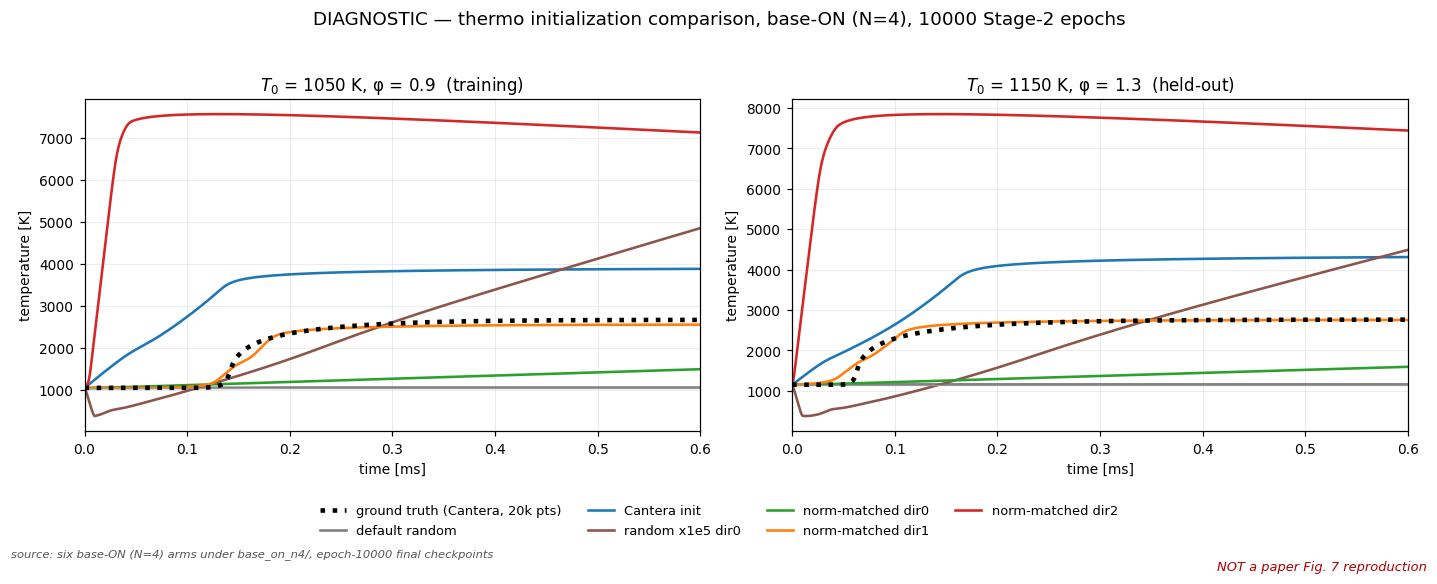

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_temperature_comparison_10000.png


In [65]:
# A. Ground truth vs the six base-ON arms at 10 000 epochs, both representative conditions.
_p, _fig = ABM.figure_A_trajectories(MX_CURVES, MXD); _fig.text(0.005, -0.02, "source: six base-ON (N=4) arms under base_on_n4/, epoch-10000 final checkpoints", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show()
print("saved", _p.relative_to(ROOT))

> **Why Cantera init (blue) is worse than norm-matched dir1 (orange) here.** This panel shows
> the **epoch-10 000 final checkpoints**, and the base-ON Cantera arm **diverged**: its Stage-2
> loss reached a minimum of 0.362 at **epoch 3041** and ended at 19.68 — 54× worse than its own
> best. At **epoch 500** that same arm was the best of all six, with a training-condition peak
> error of **−0.7 K**. So the blue curve is not "what Cantera initialization achieves"; it is
> what remained after the optimizer left a good solution.
>
> The 500-epoch panel below, and the 500 → 10 000 persistence figure, show both states. This is
> the concrete reason the analysis reports minimum-loss epoch and the epoch-500 snapshot
> alongside the final checkpoint: for four of the six base-ON arms the final checkpoint is not
> the best model the run produced.

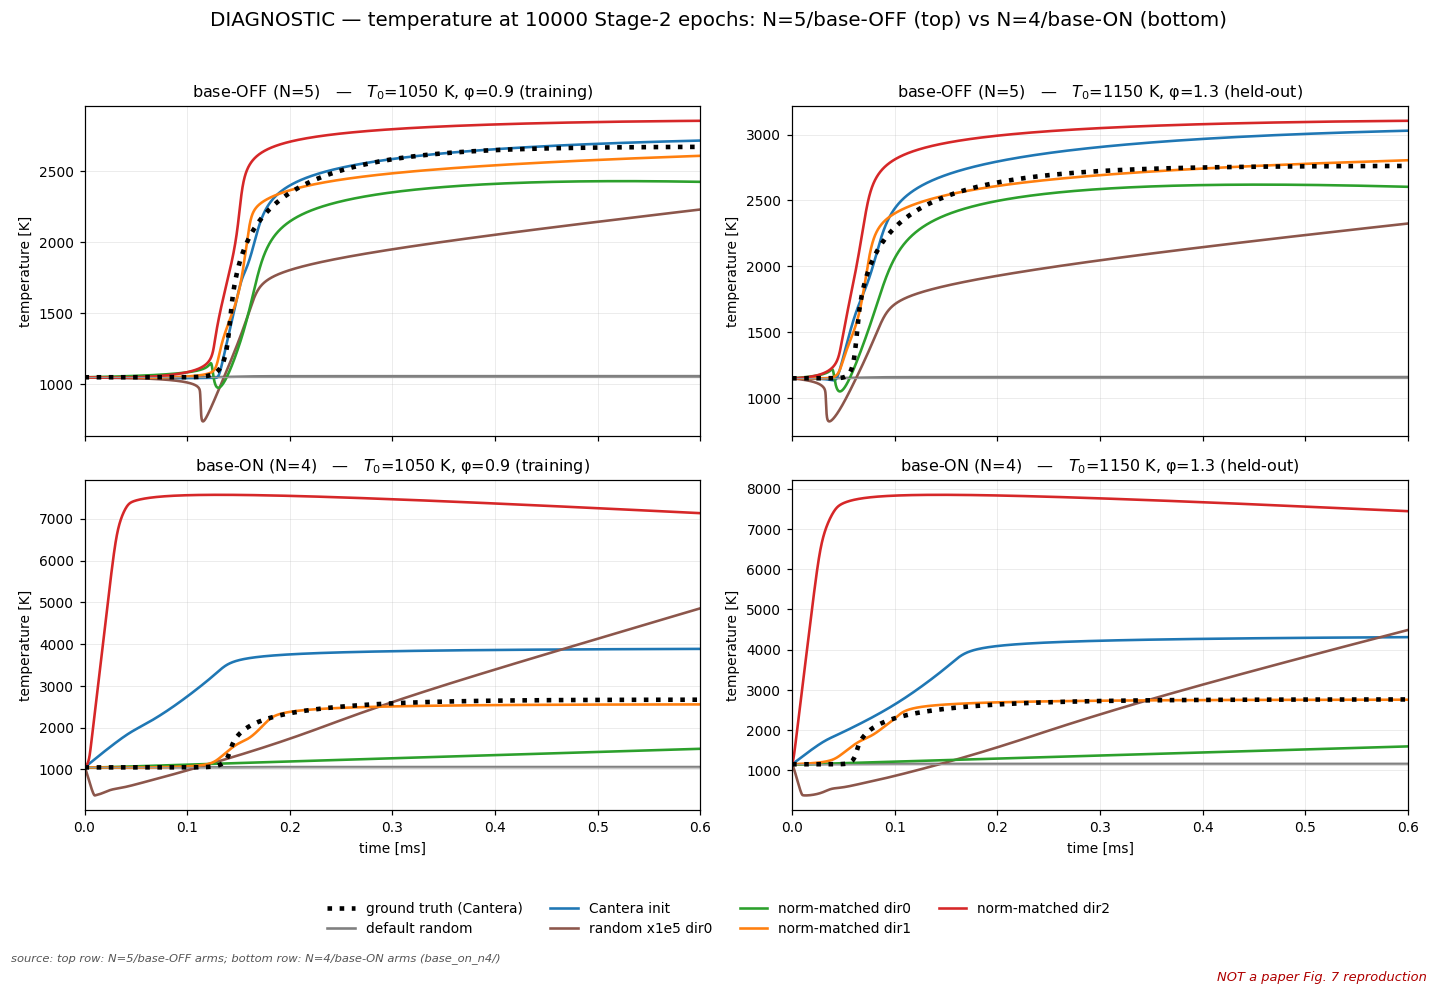

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_off_vs_on_temperature_10000.png


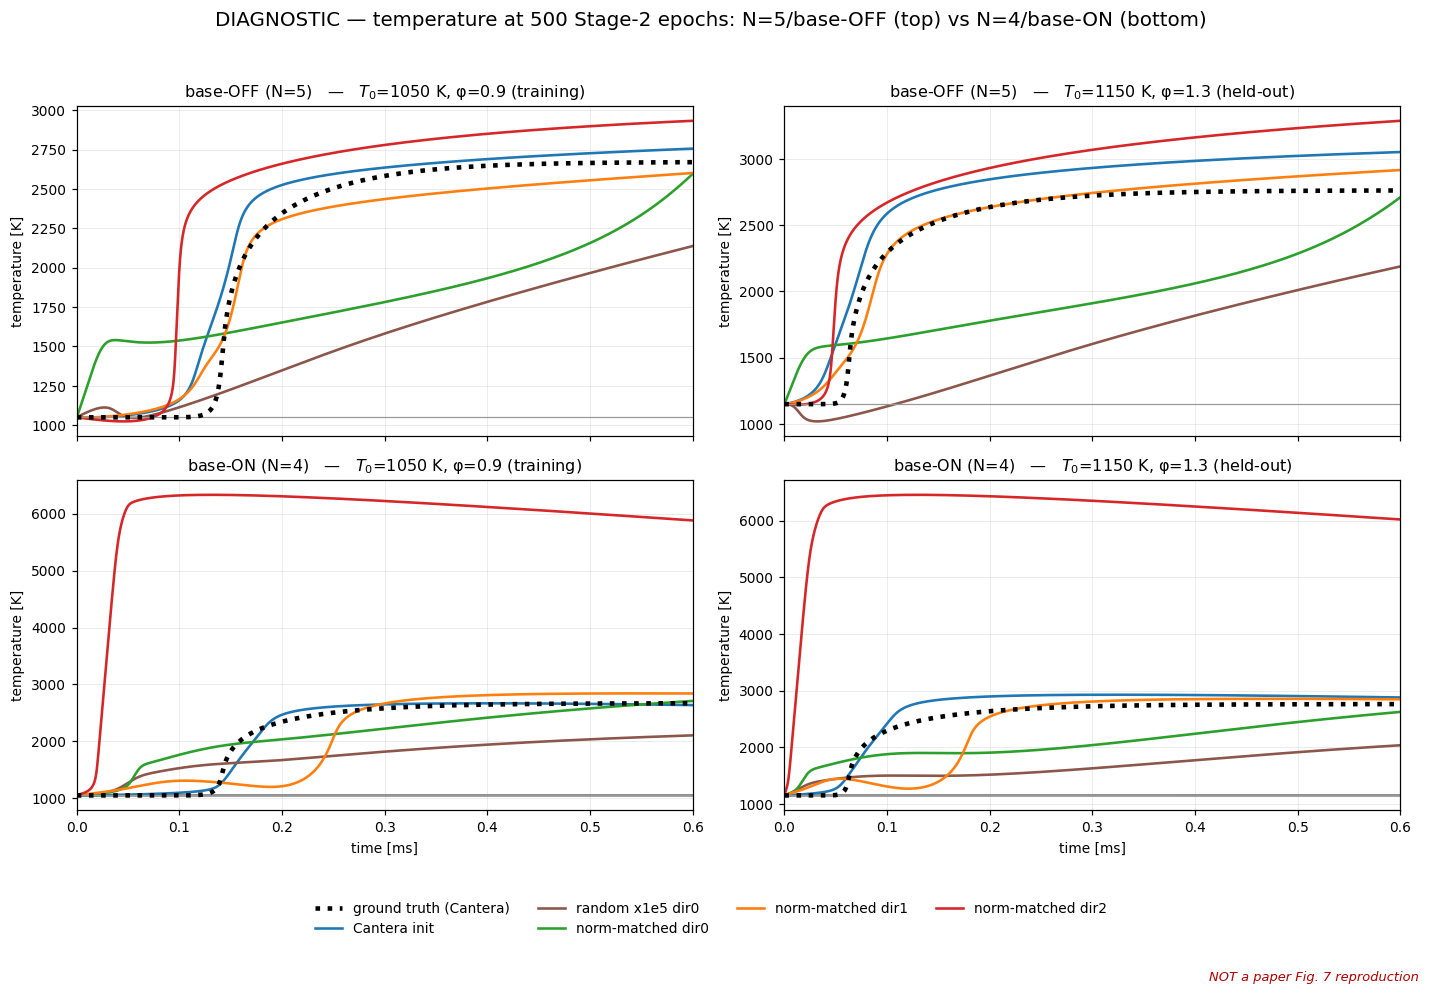

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_off_vs_on_temperature_500.png  (epoch-500 snapshots / 500-epoch runs)


In [66]:
# A2. The SAME six arms under both interpretations, both conditions -- the direct
# architecture comparison (rows = interpretation). Requested Fig.-7-style overlay.
_p, _fig = ABM.figure_A2_off_vs_on(MX_CURVES, MXD, 10000); _fig.text(0.005, -0.02, "source: top row: N=5/base-OFF arms; bottom row: N=4/base-ON arms (base_on_n4/)", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show()
print("saved", _p.relative_to(ROOT))
_p, _fig = ABM.figure_A2_off_vs_on(MX_CURVES, MXD, 500); plt.show()
print("saved", _p.relative_to(ROOT), " (epoch-500 snapshots / 500-epoch runs)")

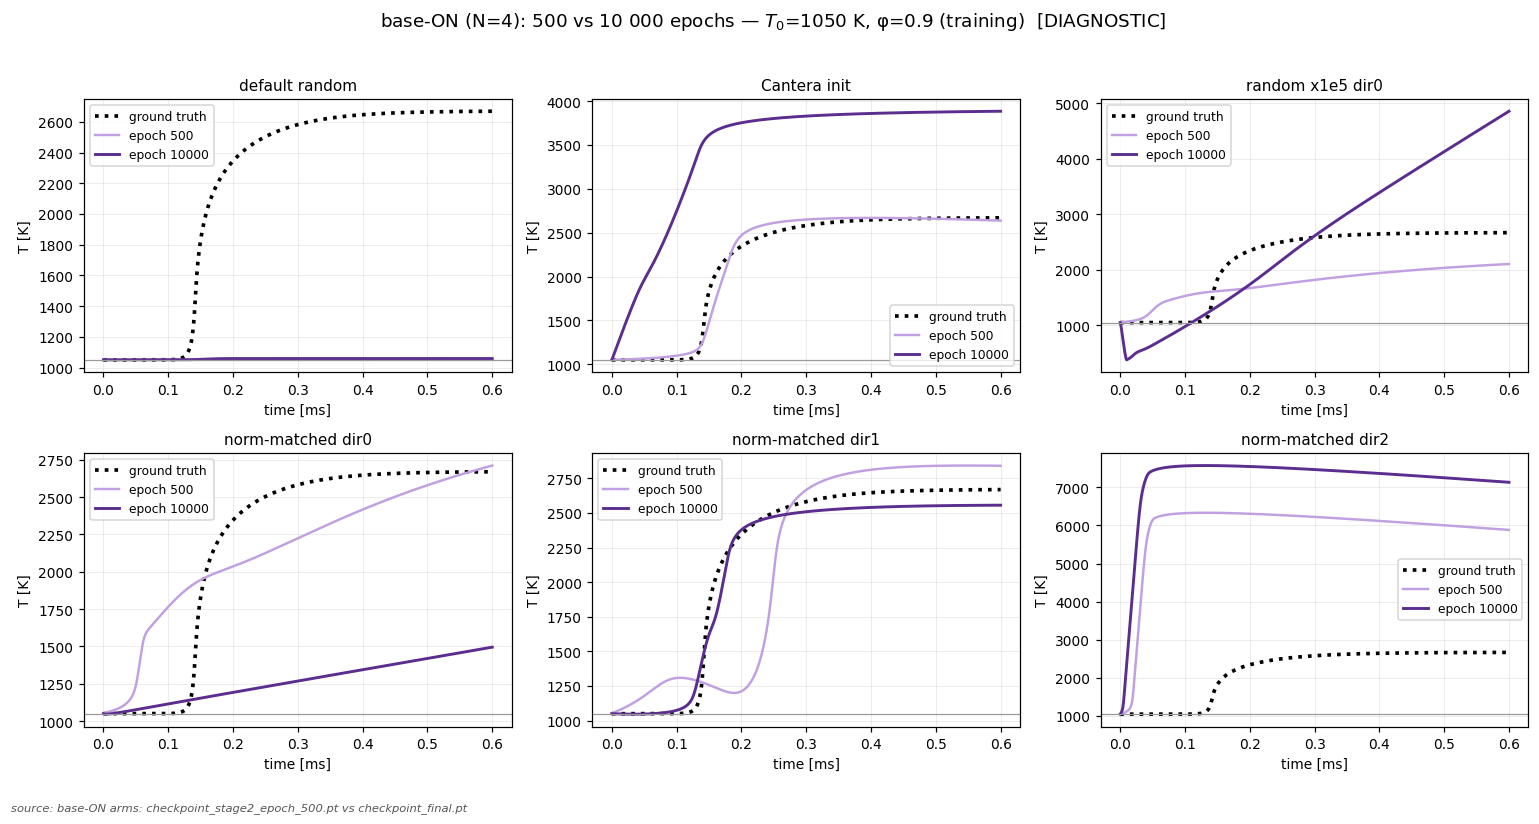

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_500_vs_10k_training.png


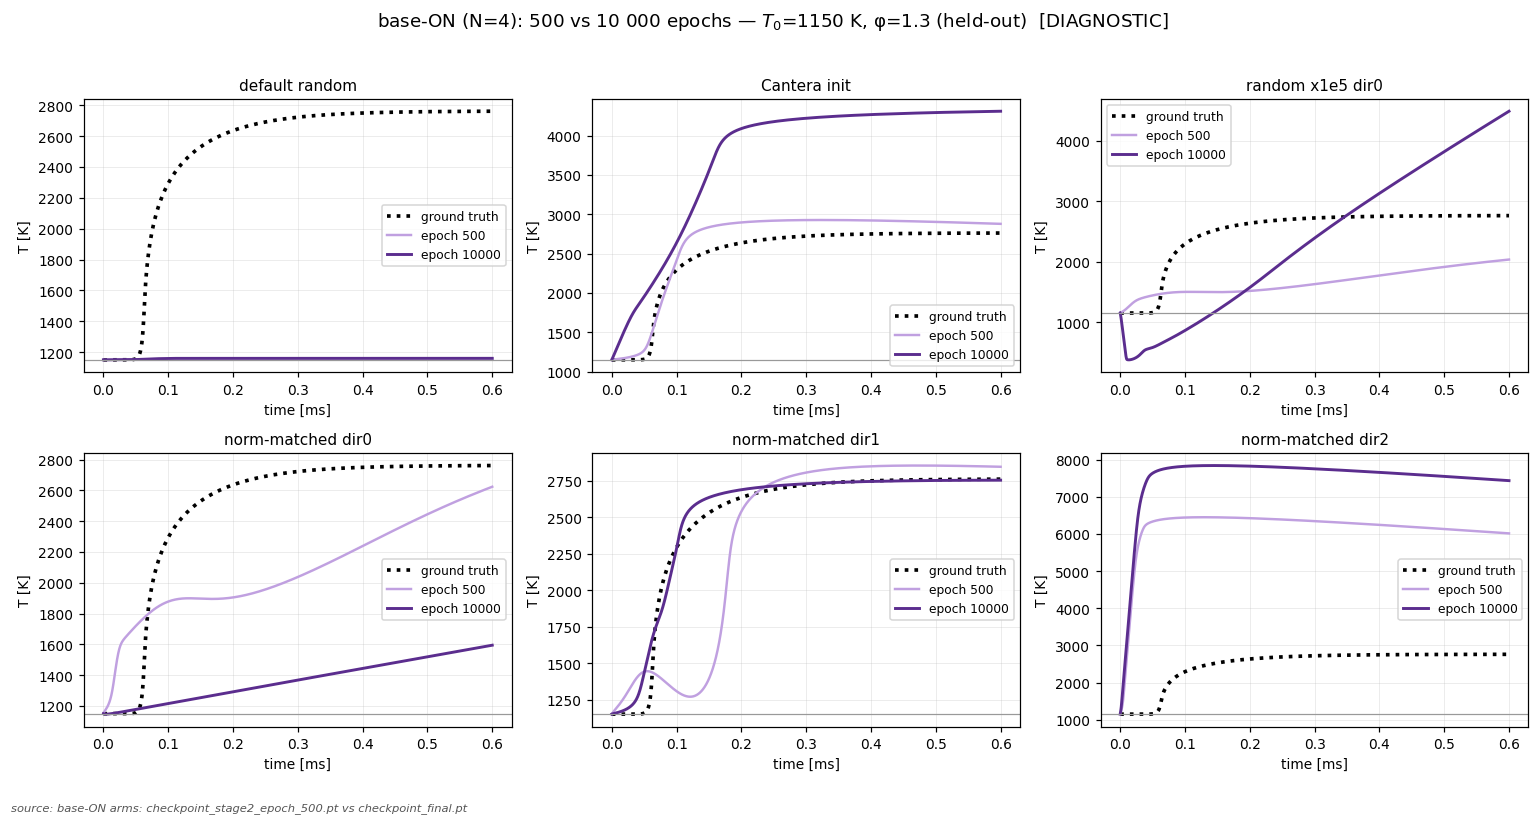

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_500_vs_10k_heldout.png


In [67]:
# B. Did long training repair the trajectory shape? epoch-500 snapshot vs epoch-10 000 final.
for _role in ("training", "held-out"):
    _p, _fig = ABM.figure_B_persistence(MX_CURVES, MXD, _role); _fig.text(0.005, -0.02, "source: base-ON arms: checkpoint_stage2_epoch_500.pt vs checkpoint_final.pt", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show()
    print("saved", _p.relative_to(ROOT))

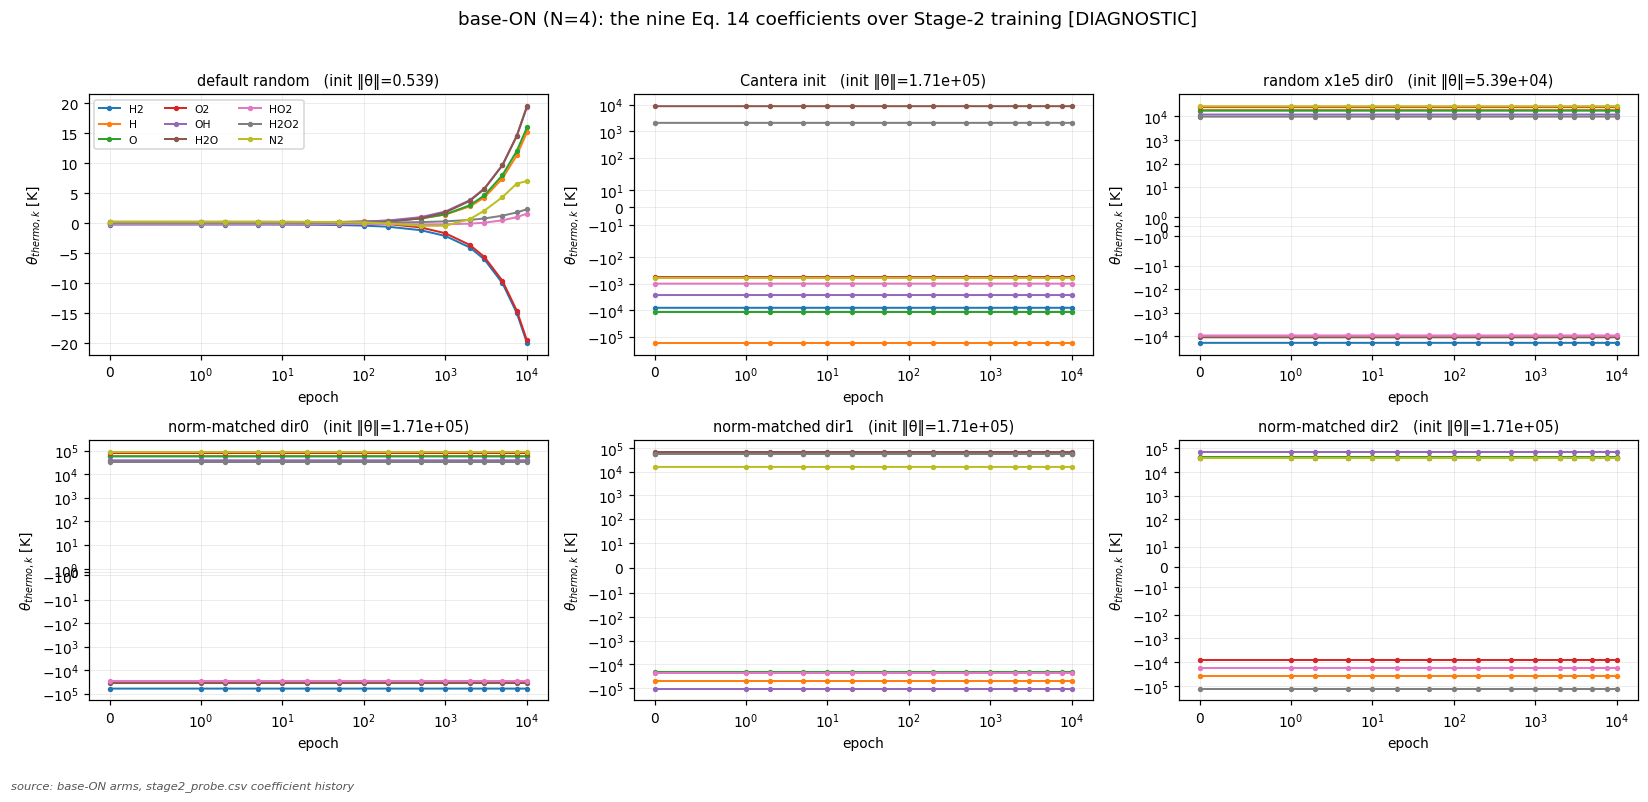

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_thermo_weights.png


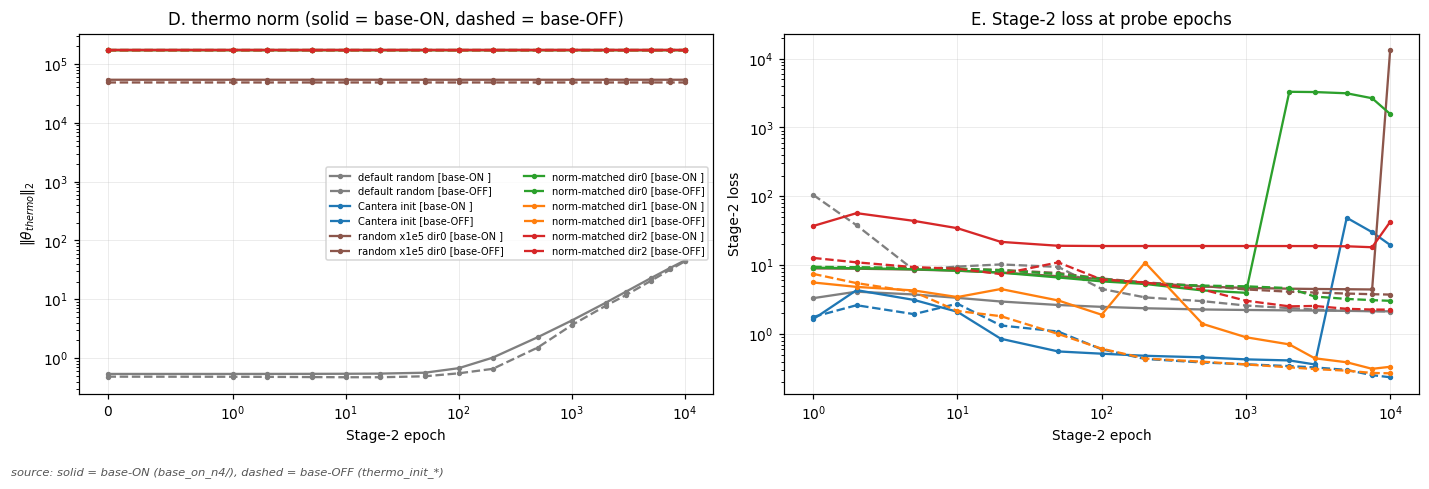

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_norm_and_loss.png


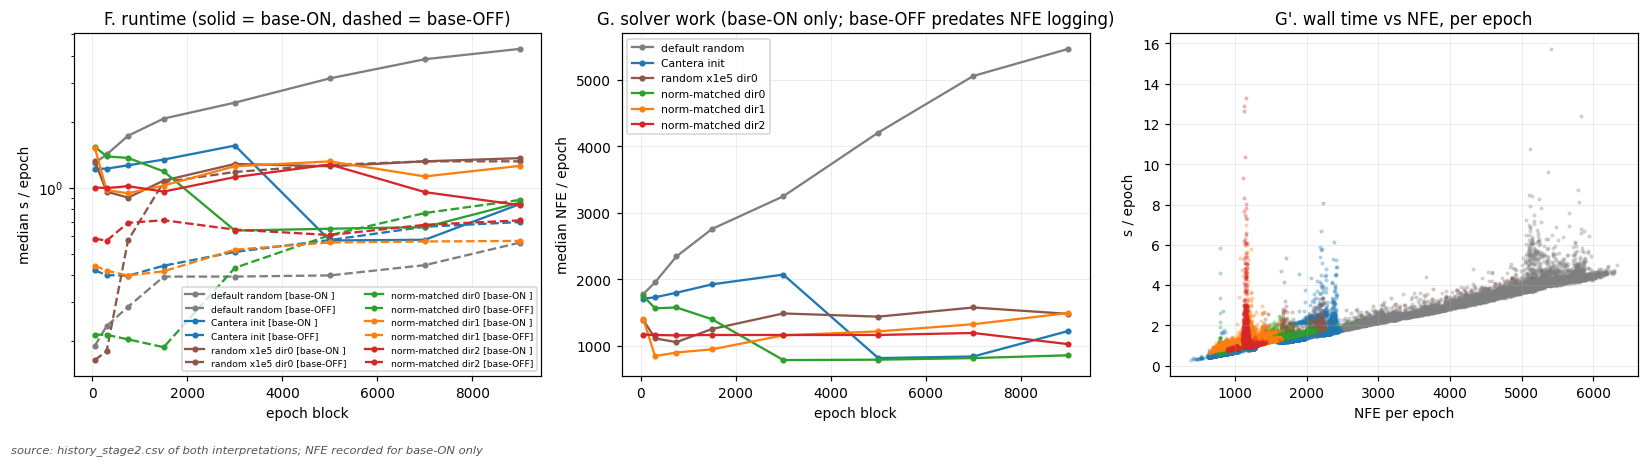

saved results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_base_on_n4_runtime_nfe.png


In [68]:
# C. The nine Eq. 14 coefficients over training, one panel per base-ON arm (simple, direct).
_p, _fig = ABM.figure_C_weights(MX_PROBES, MXD); _fig.text(0.005, -0.02, "source: base-ON arms, stage2_probe.csv coefficient history", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show(); print("saved", _p.relative_to(ROOT))
# D/E. thermo norm and Stage-2 loss vs epoch, both interpretations overlaid.
_p, _fig = ABM.figure_DE_norm_loss(MX_PROBES, MX_HISTS); _fig.text(0.005, -0.02, "source: solid = base-ON (base_on_n4/), dashed = base-OFF (thermo_init_*)", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show(); print("saved", _p.relative_to(ROOT))
# F/G. runtime and solver work. Base-OFF predates NFE logging, so panel G is base-ON only.
_p, _fig = ABM.figure_FG_runtime_nfe(MX_HISTS); _fig.text(0.005, -0.02, "source: history_stage2.csv of both interpretations; NFE recorded for base-ON only", ha="left",
          va="top", fontsize=7.5, color="#555555", style="italic"); plt.show(); print("saved", _p.relative_to(ROOT))

In [69]:
# Direct base-OFF vs base-ON matched comparison, arm by arm, at both budgets.
rows = []
for key, (label, *_ ) in ABM.ARMS.items():
    for budget in (500, 10000):
        a = MX[(MX.arm == key) & (MX.budget == budget) & MX.interpretation.str.startswith("base-OFF")]
        b = MX[(MX.arm == key) & (MX.budget == budget) & MX.interpretation.str.startswith("base-ON")]
        if len(a) == 0 or len(b) == 0:
            rows.append(dict(arm=label, budget=budget, note="base-OFF 500 cell absent"))
            continue
        a, b = a.iloc[0], b.iloc[0]
        rows.append(dict(arm=label, budget=budget,
                         test_mse_OFF=a.test_mse, test_mse_ON=b.test_mse,
                         ratio_ON_over_OFF=b.test_mse / a.test_mse,
                         train_peakE_OFF=a.train_peak_error_K, train_peakE_ON=b.train_peak_error_K,
                         held_peakE_OFF=a.held_peak_error_K, held_peakE_ON=b.held_peak_error_K,
                         gate_both_OFF=a.gate_both, gate_both_ON=b.gate_both))
MATCHED = pd.DataFrame(rows).set_index(["arm", "budget"])
display(MATCHED.round(3))
_out = TABLES / "hydrogen_base_on_n4_matched_comparison.csv"; MATCHED.to_csv(_out)
print("saved", _out.relative_to(ROOT))

_k10 = MX[(MX.budget == 10000)]
print("\nBest test MSE at 10k:")
for interp, g in _k10.groupby("interpretation"):
    r = g.loc[g.test_mse.idxmin()]
    print(f"  {interp:15s} {r.label:20s} test MSE {r.test_mse:.4f}   gate both: {bool(r.gate_both)}")
print("\nArms passing BOTH representative gates at 10k:",
      list(_k10[_k10.gate_both].apply(lambda r: f"{r.label} [{r.interpretation}]", axis=1)) or "none")
print("Arms passing BOTH gates at 500: ",
      list(MX[(MX.budget == 500) & MX.gate_both].apply(lambda r: f"{r.label} [{r.interpretation}]", axis=1)) or "none")

note  test_mse_OFF  test_mse_ON  ratio_ON_over_OFF  train_peakE_OFF  train_peakE_ON  held_peakE_OFF  held_peakE_ON gate_both_OFF gate_both_ON
arm               budget                                                                                                                                                                   
default random    500     base-OFF 500 cell absent           NaN          NaN                NaN              NaN             NaN             NaN            NaN           NaN          NaN
                  10000                        NaN         3.156        3.146              0.997        -1611.710       -1611.212       -1601.986      -1601.668         False        False
Cantera init      500                          NaN         0.409        0.348              0.849           86.075          -0.688         289.580        165.536         False        False
                  10000                        NaN         0.238       10.069             42.292           44.377        1215.748         267.549       1547.899         False        False
random x1e5 dir0  500                          NaN         8.122        8.432              1.038         -532.309        -563.971        -572.868       -726.307         False        False
                  10000                        NaN         6.598    11482.902           1740.453         -440.111        2187.724        -436.863       1726.656         False        False
norm-matched dir0 500                          NaN         7.684        7.365              0.959          -73.337          41.732         -51.095       -137.753         False        False
                  10000                        NaN         5.400       25.853              4.788         -240.902       -1174.416        -141.791      -1166.901         False        False
norm-matched dir1 500                          NaN         0.294        1.377              4.687          -68.619         173.753         154.052         93.244         False        False
                  10000                        NaN         0.207        0.209              1.008          -62.865        -112.834          43.368         -7.119          True        False
norm-matched dir2 500                          NaN         7.269       25.082              3.451          262.714        3663.569         525.246       3692.333         False        False
                  10000                        NaN         3.903       41.209             10.558          183.292        4902.221         342.639       5084.565         False        False

saved results/reproduction/chemkan/hydrogen/tables/hydrogen_base_on_n4_matched_comparison.csv

Best test MSE at 10k:
  base-OFF (N=5)  norm-matched dir1    test MSE 0.2071   gate both: True
  base-ON (N=4)   norm-matched dir1    test MSE 0.2088   gate both: False

Arms passing BOTH representative gates at 10k: ['norm-matched dir1 [base-OFF (N=5)]']
Arms passing BOTH gates at 500:  none


In [70]:
# Quantitative comparison to the paper's reported H2 error regime -- WITH the convention caveat.
# The paper (Fig. 8A discussion) reports per-condition reconstruction MSE "in the 1e-4 range"
# for the 1000 K training points and "in the 1e-3 range" for the harder 987.5 K test points.
# It does NOT state the averaging convention. Our Eq. 18 SUMS over the 50 observation times;
# a per-time-point mean is therefore ours / 50. Both readings are shown.
_best = MX[MX.budget == 10000].sort_values("test_mse").head(4)
paper_cmp = pd.DataFrame({
    "label": _best.label, "interp": _best.interpretation,
    "train MSE (Eq.18, sum over t)": _best.train_mse,
    "train MSE / Nt (per-point mean)": _best.train_mse / len(MXD.t),
    "test MSE (Eq.18)": _best.test_mse,
    "test MSE / Nt": _best.test_mse / len(MXD.t)}).set_index(["label", "interp"])
display(paper_cmp)
print(f"paper: ~1e-4 (training points at 1000 K), ~1e-3 (test points at 987.5 K), convention unstated.")
print(f"our best arm, per-point-mean reading: {paper_cmp['train MSE / Nt (per-point mean)'].min():.2e} "
      f"-> still ~{paper_cmp['train MSE / Nt (per-point mean)'].min()/1e-4:.0f}x above the paper's 1e-4 "
      "regime even under the reading most favourable to us.")

train MSE (Eq.18, sum over t)  train MSE / Nt (per-point mean)  test MSE (Eq.18)  test MSE / Nt
label             interp                                                                                                         
norm-matched dir1 base-OFF (N=5)                         0.2697                           0.0054            0.2071         0.0041
                  base-ON (N=4)                          0.3101                           0.0062            0.2088         0.0042
Cantera init      base-OFF (N=5)                         0.2368                           0.0047            0.2381         0.0048
default random    base-ON (N=4)                          2.1394                           0.0428            3.1461         0.0629

paper: ~1e-4 (training points at 1000 K), ~1e-3 (test points at 987.5 K), convention unstated.
our best arm, per-point-mean reading: 4.74e-03 -> still ~47x above the paper's 1e-4 regime even under the reading most favourable to us.


### Reading the base-activation study

Every statement below is produced by the cells above from the recomputed artifacts.

**Stage-1 (secondary question).** The base pathway does **not** substantially change Stage-1
species learning: final Stage-1 loss differs by a few percent and the open-loop species MSE
at the representative condition is essentially identical. It does make Stage-1 ~1.6× slower.

**Default random (the primary question).** Base activation does **not** materially change the
default-random outcome. Both interpretations converge stably to the same non-igniting basin
with train/test trajectory MSE agreeing to two decimals, temperature carrying ~87 % of the
error, and no ignition at either representative condition. **Including the paper-explicit Eq.
11 base term does not by itself explain the reproduction failure.**

**Scale sensitivity persists.** Under base-ON, small initialization (random) stays flat and
large initializations (Cantera, ×1e5, norm-matched) enter ignition-capable regimes — the
same qualitative split as base-OFF.

**Direction sensitivity persists — and is amplified.** The three equal-norm directions end
orders of magnitude apart in test MSE under base-ON, a wider spread than under base-OFF.
`dir1` is again the best random direction in both interpretations, with essentially the same
test MSE (~0.21) in both; `dir0` and `dir2` are again poor in both.

**The new finding: base-ON destabilizes Stage 2 for large initializations.** All six base-OFF
arms are stable (final loss within 1–3 % of their own minimum). Four of six base-ON arms
**diverge** — final loss 2.5× to ~3000× above their own minimum — and every diverged arm is a
large-initialization arm; the two stable base-ON arms are `random` (small init) and `dir1`.
The most consequential case is Cantera init: at epoch 500 the base-ON version is *better*
than base-OFF (training peak error −0.7 K vs +86 K; test MSE 0.35 vs 0.41), then it leaves
that solution around epoch 3000 and never returns. Reading the 10k final checkpoint alone
would call this arm a failure; the trajectory says it was a good solution that the optimizer
did not hold.

**Why the diverged losses are so large.** They are dominated by trace species. Eq. 18 divides
each state by its own min–max range, and HO2's range is ~1.7e-4 — an absolute error of a few
percent of a mass fraction becomes a normalized error of ~160. The ×1e5 arm's final loss of
~13 000 is >99 % HO2. The `dominant` column in the tables shows which state carries each arm's
error; where it reads `HO2` or `T` with a large share, the headline number is one channel's
pathology, not a uniform failure.

**Gates.** No base-ON arm passes both representative gates at 10 000 epochs; the base-OFF
`dir1` arm does. At 500 epochs, base-ON Cantera and base-ON `dir1` each pass the training gate.

**Runtime and solver work.** Base-ON is 1.4–7.4× slower per arm. The per-epoch NFE, recorded
for the first time in this study, tracks wall time closely (see panel G′), and the base-ON
kinetic core needs ~3× more RHS evaluations per solve at Stage-2 epoch 0 than the base-OFF
one. The earlier "solver work vs thermal throttling" ambiguity (§18) is resolved in favour of
solver work — a measurement, not an inference.

**Unphysical species.** Every arm of **both** interpretations predicts negative mass fractions
for 6–34 % of species values on the train split. This is a property of the current models,
not of the base term, and it is part of why the trace-species channels dominate the loss.

**Against the paper's error regime.** Even the best arm here, under the per-time-point
reading most favourable to us, sits roughly two orders of magnitude above the paper's ~1e-4
per-condition MSE. The paper's averaging convention is not stated, so the exact factor is
uncertain; the gap is not.

---
# 23. Scientific synthesis

Every claim is tied to the section that produces it and to the printed values above.

## ESTABLISHED

1. **Default random initialization fails under the current direct-autograd Stage-2
   implementation, and 10 000 epochs do not rescue it.** The control never raises the
   operational ignition flag at any probe epoch, and its temperature stays within ~10 K of
   `T₀` at both representative conditions (§4, §13B).
2. **Temperature dominates the closed-loop trajectory error, and the thermodynamic pathway
   is independently severely inadequate in the failed reproduction.** Temperature carries
   the share printed above of the held-out per-state error; feeding the model the
   **reference** species rates through its **learned** `θ_thermo` still under-predicts the
   peak temperature rate by ~134× / ~145× (§6). The kinetic pathway is *active* but is
   **not** established as correct — its own rate error is of relative L2 order one.
3. **The deficit is in the Eq. 14 linear branch, not in `KAN_cor`.** Adding the correction
   term changes the deficit factor by well under one percent; the correction contributes
   ~0.1 % of the full Eq. 15 thermodynamic path at the heat-release peak (§6).
4. **A physical-scale coefficient intervention restores ignition-scale heating** in the
   already-failed model with no retraining — while overshooting and *not* improving total
   trajectory MSE (§8).
5. **Initialization magnitude strongly changes the accessible closed-loop dynamics.** From
   one Stage-1 checkpoint and one global seed, the default init never ignites while
   large-scale inits enter ignition-capable regimes (§9, §12, §15).
6. **Large magnitude alone is not sufficient.** Along a single fixed direction, ×1e4 *cools
   below `T₀`* and never recovers, and ×1e5 at 10 000 epochs still ends with a test
   trajectory MSE among the worst measured (§12, §15).
7. **Equal-norm random directions lead to dramatically different final solutions even after
   10 000 epochs.** `nm_dir0/1/2` start with L2 norms identical to ~5e-7 relative spread and
   end ~26× apart in test trajectory MSE, with held-out peak errors spanning −142 K to
   +343 K (§15, §21).
8. **Direction dependence is therefore NOT a 500-epoch transient.** Every arm improved
   between 500 and 10 000 epochs, but the ordering and the magnitude of the spread survived
   the twenty-fold increase in budget (§15).
9. **At least one nonphysical norm-matched random direction reaches a high-quality ignition
   solution.** `nm_dir1` at 10 000 epochs attains the **lowest test trajectory MSE of any
   arm measured here** and is the **only** arm passing the representative-condition gate at
   *both* conditions; the Cantera arm passes the training condition but fails held-out on a
   large peak overshoot (§21).
10. **Therefore exact Cantera coefficient direction is not demonstrably necessary** for an
    ignition-capable, high-quality solution in this tested setting (§21).
11. **Correct ignition timing alone is insufficient evidence of a correct model.** At
    10 000 epochs `x1e5_dir0` and `nm_dir0` both land training-condition delay errors inside
    the ±25 % gate while carrying test trajectory MSE of ~6.6 and ~5.4 — roughly 30× and 26×
    worse than the best arm. Any ranking built on ignition delay alone would invert the
    quality ordering (§15, §21).
12. **A `θ_thermo` initialized at O(10⁴–10⁵) cannot be rotated appreciably within this
    budget, so its initial sign structure is locked in for the whole run.** `cos(θ_final, θ_0)`
    equals 1 to ~1e−7 for every large-scale arm (§18). §18F shows *why*: Adam's per-coordinate
    step is bounded by ≈ `lr`, so a 9-vector can travel at most ≈ `lr·steps·√9` ≈ 60 in 10 000
    epochs — negligible against a norm of 1.7e5. The arms in fact travel **45–82 % of that
    ceiling**, so they are moving at nearly the maximum rate the optimizer allows.
    *(Superseded reading: the earlier claim that these vectors "undergo essentially no
    directional movement" over-interpreted a relative-displacement metric that is largely
    `bounded travel / ‖θ₀‖` — it correlates with `log‖θ₀‖` at ≈ −0.94 while absolute
    displacement barely correlates at all.)*
13. **`dir0` fails because its dominant coefficient has the wrong sign.** Rate-weighted
    against the species that actually react, `dir0` is nearly **anti-parallel** to the
    physical direction (cosine ≈ −0.91, versus ≈ −0.31 unweighted); its largest entry sits on
    H2O — the largest positive species rate — with the **opposite** sign to physics, so it
    begins Stage 2 as a heat sink where the reference is a heat source (§18E). Combined with
    item 12, that sign error is never repaired.
14. **`θ_thermo` is the most weakly driven block in the network.** At the final checkpoint
    its gradient norm is **5–6 orders of magnitude** below the kinetic core's in every arm,
    and `thermo.correction`'s is smaller still (§18F). `dir1` is the one arm whose
    displacement is far below the Adam ceiling (~0.3 %), indicating a cancelling rather than
    merely small gradient — the signature of a near-stationary point.
15. **No arm rotated toward the physical direction.** `cos(θ, θ_Cantera)` changes by less
    than the printed bound between epoch 0 and epoch 10 000 for every arm that started
    large — optimization never discovers the Cantera direction (§18).

### From the base-activation study (§22)

16. **Including the paper-explicit Eq. 11 base term does not change the default-random
    outcome.** Under N=4/base-ON the default arm converges stably to the same non-igniting
    basin as N=5/base-OFF, with train/test trajectory MSE equal to two decimals (§22).
17. **Both scale sensitivity and direction sensitivity persist under base-ON**, and the
    direction spread is wider. `dir1` is the best random direction in both interpretations
    with essentially the same test MSE (§22).
18. **Base-ON destabilizes Stage-2 optimization for large `θ_thermo` initializations at this
    learning rate.** 6/6 base-OFF arms are stable; 4/6 base-ON arms diverge (final loss 2.5×
    to ~3000× their own minimum), all of them large-init arms. Base-ON Cantera reaches a
    *better* solution than base-OFF at epoch 500 and then loses it (§22).
19. **Diverged losses are dominated by trace species through the Eq. 18 normalization**
    (HO2 range ~1.7e-4; the ×1e5 arm's ~13 000 loss is >99 % HO2). Final training loss is not
    a usable cross-arm metric for those cells (§22).
20. **Base-ON costs ~3× more solver work per solve** (measured NFE) and 1.4–7.4× wall time
    per arm; NFE tracks wall time closely, which settles the §18 runtime question in favour
    of solver work rather than throttling (§22).
21. **Both interpretations predict negative mass fractions** for 6–34 % of species values on
    the train split (§22).


## SUPPORTED / LEADING INTERPRETATION

* **Under the current physical-rate Eq. 14 formulation with direct-autograd sensitivities,
  Stage-2 optimization exhibits strong scale- *and* direction-dependent basin sensitivity.**
  Which basin the run lands in is decided at initialization and is not escaped within
  10 000 epochs.
* **When initialized at large thermodynamic scale, the network adapts the kinetic core
  around a thermal mapping it cannot move.** The direction is effectively fixed for
  *mechanical* reasons (§18F: bounded Adam step against a norm of 1.7e5), while the kinetic
  core moves by a relative displacement of 0.2–1.3 over the same run. What is **not**
  established is the causal reading — that the kinetic core is *compensating* for the fixed
  thermal map — because `thermo.correction`'s epoch-0 values are unrecorded, per-epoch
  gradients were never logged, and only one gradient snapshot (at convergence) exists.
* **Scalar summaries are an unreliable ranking for this failure mode.** Peak temperature
  alone, ignition delay alone, and final Stage-2 loss alone each rank at least one arm
  wrongly relative to full-trajectory MSE plus trajectory shape (§15, §21).

* **The Eq. 11 base pathway is not what separates this reproduction from the paper.**
  It leaves the default-random failure untouched and makes the large-init arms *less*
  stable. Whether that instability is a learning-rate effect specific to base-ON has not
  been tested (§22).

## NOT ESTABLISHED

* **What `θ_thermo` initialization the paper's authors actually used.** The paper does not
  describe one.
* **Whether their implementation applies undocumented state or derivative scaling** inside
  Eq. 14. The paper writes Eq. 14 in physical variables and is silent on the implementation.
* **Whether FSA changes the default-initialization outcome.** FSA is not implemented; no
  evidence here speaks to it either way.
* **Whether `nm_dir1` generalizes over multiple global seeds.** Only seed 0 was run.
* **Whether `nm_dir1` is uniquely special among random directions.** Three directions were
  tested; that is not a distribution.
* **How the gradient into `θ_thermo` behaves during training.** §18F measures it at a
  single point (the final checkpoint); per-epoch gradient norms were never logged and the
  epoch-0 gradient is not reconstructible.
* **Why `dir1` succeeds.** §18E explains `dir0`'s *failure* via rate-weighted misalignment,
  but `dir2` has the *higher* rate-weighted alignment and still ends far worse, so alignment
  does not rank `dir1` above `dir2`.
* **Whether the base-ON divergences are a learning-rate effect.** Only lr = 2e-3 was run;
  a lower-lr base-ON Cantera arm would test it and has not been run (§22).
* **Which of the two 344-parameter interpretations the authors used.** They are
  indistinguishable from the reported count (§22).
* **Whether the kinetic core is fully correct.** §5 shows only that it is not inert under
  the true thermal history, and §6 shows its open-loop rate error is of order one.
* **Whether Cantera initialization is an appropriate reproduction method.** It is a
  diagnostic intervention introduced by this investigation and is never reported as
  reproduction methodology.

---
# 24. Next-step decision

## The initialization AND the base-activation investigations are COMPLETE FOR CURRENT SCOPE

Sections 12–21 answer the question they were opened for. Magnitude matters, direction
matters at least as much, the effect survives a twenty-fold increase in training budget,
and a nonphysical direction can beat the physical one. Further work along this axis would
add data points, not answers.

**Explicitly not recommended:** more scale factors; more 10 000-epoch random directions;
`x1e4` at 10k; another Cantera-initialization run; further base-ON arms. If one cheap
follow-up is wanted before FSA, it is a single lower-lr base-ON Cantera arm to test whether
the §22 divergence is a step-size effect — a clarification, not a new direction.

## The next experiment is genuine forward sensitivity analysis (FSA)

FSA is the **clearest remaining paper-explicit TRAINING-METHOD difference** between this
reproduction and the paper — not necessarily the only implementation difference, since the
paper leaves `N`, the `θ_thermo` initialization and any derivative scaling unstated (§10, §22). Everything else paper-explicit already matches — architecture
and parameter count, Adam at 2e-3, Tsit5, the Eq. 18 normalization, the PINN term, the
representative conditions, and the ignition definition (§1). The paper adopts FSA
*specifically* because of stiffness: "we note the numerical instability present in many
chemical kinetic modeling problems due to numerical stiffness, potentially leading to
failures with adjoint sensitivity analysis in the training process. To prevent this, we
implement forward sensitivity analysis." Our runs use direct autograd through the solve.

### The controlled comparison to run

| held fixed | value |
|---|---|
| Stage-1 checkpoint | `diagnostics/stage1_seed0/checkpoint_stage1.pt` |
| Stage-2 `θ_thermo` init | **default random** (the arm that fails) |
| architecture | unchanged |
| loss + PINN | unchanged |
| solver / tolerances | Tsit5, rtol 1e-6, atol 1e-8 |
| optimizer / lr | Adam, 2e-3 |
| budget | identical for both arms |

with the **single** variable `direct_autograd` vs `forward_sensitivity`.

### Validate the gradients before spending a long run

FSA must not be trusted on the strength of a training curve. Before any long run:

1. check FSA sensitivities against analytic solutions on small stiff toy ODEs; then
2. check FSA gradients against short direct-autograd ChemKAN gradients on a handful of
   steps, where the two must agree to solver tolerance.

Only then is a full-budget FSA run worth its wall time.

### Pre-registered interpretation

| outcome | conclusion | and NOT |
|---|---|---|
| FSA ignites from default init | the sensitivity method materially changes convergence in this implementation | do **not** claim it was the authors' only missing implementation detail — §18 shows initialization scale independently controls the basin |
| FSA still fails from default init | FSA alone does not resolve the reproduction discrepancy; a documented `θ_thermo` initialization becomes a justified, clearly-labelled reproduction assumption | do **not** claim gradient computation is irrelevant — it was only tested at one initialization |

**Not implemented here.** This notebook recommends; it runs nothing.

In [71]:
# --- Closing summary ---
elapsed = time.perf_counter() - NB_T0
WRITTEN = [
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison.png",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison.pdf",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k.png",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k.pdf",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k.png",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k.pdf",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_direction_history_10k.png",
    FIGURES / "hydrogen_DIAGNOSTIC_thermo_direction_history_10k.pdf",
    TABLES / "hydrogen_thermo_initialization_10k_comparison.csv",
    TABLES / "hydrogen_thermo_initialization_500_vs_10k.csv",
    TABLES / "hydrogen_thermo_linear_evolution_summary.csv",
    TABLES / "hydrogen_thermo_gradient_flow.csv",
]
print(f"sections executed          : 1-24 (incl. 13B, 18E, 18F, 22)")
print(f"arms loaded                : {len(A)}")
print(f"missing artifacts          : {MISSING if MISSING else 'none'}")
print(f"artifacts written by this run:")
for f in WRITTEN:
    assert f.exists() and f.stat().st_size > 0, f"not written: {f}"
    print(f"    {rel(f)}")
print(f"dense ignition reference   : genuine Cantera, {len(T_DENSE)} points "
      f"(hydrogen_temperature_20000.npz) -- no interpolated reference used anywhere")
print(f"notebook wall time         : {elapsed:.1f} s")
print()
print("Run completed from saved artifacts; no training performed.")

sections executed          : 1-24 (incl. 13B, 18E, 18F, 22)
arms loaded                : 14
missing artifacts          : none
artifacts written by this run:
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison.png
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_10k_temperature_comparison.pdf
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k.png
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_initialization_500_vs_10k.pdf
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k.png
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_linear_norm_history_10k.pdf
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_thermo_direction_history_10k.png
    results/reproduction/chemkan/hydrogen/figures/hydrogen_DIAGNOSTIC_